# SARSA Agent for a 2D Platform-Collector Game

**UCCD2063 Artificial Intelligence Techniques — Practical Assignment**

This notebook contains the existing **Basic SARSA** and **Advanced SARSA** implementation in one sequential document.

The notebook is organised sequentially in the same style as the supplied ASG1 PPO notebook. Completed training results are loaded from CSV files and displayed in executed result-plotting cells, while training and live-evaluation cells remain runnable code that requires the corresponding Godot scene.

## Running rule

Run the notebook **from top to bottom**.

There are two intentional points where you must interact with Godot. The completed result plots do **not** require Godot because they are loaded from the supplied CSV files:

- **Basic:** start the Basic Godot scene when instructed, then run the Basic training/evaluation cells.
- **Advanced:** switch Godot to the Advanced scene when instructed, then run the Advanced training/evaluation cells.

The Q-table JSON files are used by the deterministic evaluation cells and are kept as external files in the same working space.

Do not run a training cell before the corresponding Godot scene is running on WebSocket port `8765`.

## 1. Setup and Imports

Run these cells first.

In [1]:
import asyncio
import csv
import json
import math
import os
import random
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

print("Notebook setup complete.")

Notebook setup complete.


In [2]:
%pip install websockets

Note: you may need to restart the kernel to use updated packages.


In [1]:
import websockets

print("websockets installed successfully")
print(websockets.__version__)

websockets installed successfully
17.1


## 2. Godot Environment Interface

The Python bridge communicates with Godot through WebSocket at `ws://localhost:8765`.

This class is defined before any training or evaluation code uses it.

In [2]:
import asyncio
import json
import websockets


class GodotEnvironment:

    def __init__(
        self,
        host="localhost",
        port=8765
    ):

        self.uri = (
            f"ws://{host}:{port}"
        )

        self.websocket = None


    async def connect(self):

        self.websocket = (
            await websockets.connect(
                self.uri
            )
        )

        print(
            "Connected to Godot"
        )


    async def reset(self):

        await self.websocket.send(
            json.dumps({
                "type": "reset"
            })
        )


        response = (
            await self.websocket.recv()
        )


        data = json.loads(
            response
        )


        return (
            data["state"],
            data["reward"],
            data["done"],
            data["score"]
        )


    async def step(
        self,
        action
    ):

        await self.websocket.send(
            json.dumps({
                "type": "step",
                "action": action
            })
        )


        response = (
            await self.websocket.recv()
        )


        data = json.loads(
            response
        )


        return (
            data["state"],
            data["reward"],
            data["done"],
            data["score"]
        )


    async def close(self):

        if self.websocket is not None:

            await self.websocket.close()

## 3. Basic Scene — State Representation

The existing Basic Godot state representation is included below as source/documentation.

```gdscript
extends Node

# ============================================================
# SARSA V11 - COMPACT SCENE-AWARE STATE
# ============================================================
# Small categorical state for TABULAR SARSA.
#
# State:
# 0 route_stage
# 1 target_dx
# 2 target_dy
# 3 on_floor
# 4 vertical_motion
# 5 wall_low
# 6 wall_high
# 7 snail_relation
# 8 snail_distance
# 9 danger_zone
#
# route_stage:
# 0 = start / upper area
# 1 = middle platform, go to descent side
# 2 = bottom floor, collect first apple
# 3 = first apple collected, go to left platform
# 4 = left platform, collect second apple
# 5 = both apples collected
#
# wall_low / wall_high:
# 0,0 = open
# 1,0 = low obstacle; may be jumpable
# 1,1 = tall obstacle
# 0,1 = upper obstacle
# ============================================================

const BOTTOM_APPLE_POSITION: Vector2 = Vector2(845.0, 642.0)
const LEFT_APPLE_POSITION: Vector2 = Vector2(133.0, 549.0)

# Waypoints are intentionally fixed to the level route.
const DESCENT_POINT: Vector2 = Vector2(980.0, 570.0)
const LEFT_PLATFORM_ENTRY: Vector2 = Vector2(430.0, 650.0)
const LEFT_PLATFORM_TARGET: Vector2 = Vector2(430.0, 550.0)


func find_apple(apples: Node, apple_name: String) -> Node2D:
	if apples == null:
		return null

	for child in apples.get_children():
		if child is Node2D and child.name == apple_name:
			return child as Node2D

	return null


func is_collected(apple: Node2D) -> bool:
	if apple == null:
		return false
	return apple.get("already_collected") == true


func get_target_apple(apples: Node) -> int:
	var bottom_apple: Node2D = find_apple(apples, "Apple2")
	var left_apple: Node2D = find_apple(apples, "Apple")

	if not is_collected(bottom_apple):
		return 0

	if not is_collected(left_apple):
		return 1

	return 2


func get_route_stage(player: CharacterBody2D, apples: Node) -> int:
	var pos: Vector2 = Vector2(player.global_position)
	var target_apple: int = get_target_apple(apples)

	if target_apple == 2:
		return 5

	if target_apple == 0:
		if is_on_middle_platform(pos):
			return 1

		if is_bottom_floor(pos):
			return 2

		return 0

	# First/bottom apple collected.
	# Go to the left platform before targeting Apple2.
	if is_left_platform(player):
		return 4

	return 3


func get_target_position(player: CharacterBody2D, apples: Node) -> Vector2:
	var stage: int = get_route_stage(player, apples)

	match stage:
		0:
			return DESCENT_POINT
		1:
			return DESCENT_POINT
		2:
			return BOTTOM_APPLE_POSITION
		3:
			return LEFT_PLATFORM_ENTRY
		4:
			return LEFT_APPLE_POSITION
		_:
			return Vector2(player.global_position)


func get_state(
	player: CharacterBody2D,
	apples: Node,
	enemies: Node
) -> String:
	var stage: int = get_route_stage(player, apples)
	var target: Vector2 = get_target_position(player, apples)
	var pos: Vector2 = Vector2(player.global_position)

	var target_dx: int = get_x_direction(pos.x, target.x)
	var target_dy: int = get_y_direction(pos, target)

	var on_floor: int = 1 if player.is_on_floor() else 0
	var vertical_motion: int = get_vertical_motion(player)

	# Look in the direction of the current waypoint.
	# If aligned, use the previous/default right-facing sensor.
	var wall_low: int = get_wall_sensor(player, target_dx, 12.0)
	var wall_high: int = get_wall_sensor(player, target_dx, -28.0)

	var snail_relation: int = get_snail_relation(player, enemies)
	var snail_distance: int = get_snail_distance_category(player, enemies)
	var danger_zone: int = get_danger_zone(pos)

	return str(
		stage, ",",
		target_dx, ",",
		target_dy, ",",
		on_floor, ",",
		vertical_motion, ",",
		wall_low, ",",
		wall_high, ",",
		snail_relation, ",",
		snail_distance, ",",
		danger_zone
	)


# ============================================================
# DIRECTION
# ============================================================

func get_x_direction(player_x: float, target_x: float) -> int:
	if target_x < player_x - 50.0:
		return -1
	if target_x > player_x + 50.0:
		return 1
	return 0


func get_y_direction(player_pos: Vector2, target_pos: Vector2) -> int:
	var dy: float = target_pos.y - player_pos.y

	if dy < -50.0:
		return -1
	if dy > 50.0:
		return 1
	return 0


# ============================================================
# PLAYER MOTION
# ============================================================

func get_vertical_motion(player: CharacterBody2D) -> int:
	if player.velocity.y < -60.0:
		return 0       # rising
	if player.velocity.y > 60.0:
		return 2       # falling
	return 1           # stable


# ============================================================
# WALL LOW / HIGH
# ============================================================

func get_sensor_direction(target_dx: int) -> float:
	if target_dx < 0:
		return -1.0
	return 1.0


func get_wall_sensor(
	player: CharacterBody2D,
	target_dx: int,
	y_offset: float
) -> int:
	var direction: float = get_sensor_direction(target_dx)

	var start: Vector2 = (
		player.global_position
		+ Vector2(direction * 18.0, y_offset)
	)
	var end: Vector2 = start + Vector2(direction * 80.0, 0.0)

	var query: PhysicsRayQueryParameters2D = (
		PhysicsRayQueryParameters2D.create(start, end)
	)
	query.collision_mask = 1
	query.exclude = [player.get_rid()]

	var result: Dictionary = (
		player.get_world_2d()
		.direct_space_state
		.intersect_ray(query)
	)

	return 1 if not result.is_empty() else 0


# ============================================================
# SNAIL
# ============================================================

func get_nearest_snail(player: CharacterBody2D, enemies: Node) -> Node2D:
	if enemies == null:
		return null

	var nearest: Node2D = null
	var nearest_distance: float = INF

	for child in enemies.get_children():
		if not child is Node2D:
			continue

		var snail: Node2D = child as Node2D
		var distance: float = (
			player.global_position.distance_to(snail.global_position)
		)

		if distance < nearest_distance:
			nearest_distance = distance
			nearest = snail

	return nearest


func get_snail_distance_category(
	player: CharacterBody2D,
	enemies: Node
) -> int:
	var snail: Node2D = get_nearest_snail(player, enemies)

	if snail == null:
		return 0

	var distance: float = (
		player.global_position.distance_to(snail.global_position)
	)

	if distance < 80.0:
		return 1
	if distance < 180.0:
		return 2
	if distance < 300.0:
		return 3

	return 0


func get_snail_relation(
	player: CharacterBody2D,
	enemies: Node
) -> int:
	var snail: Node2D = get_nearest_snail(player, enemies)

	if snail == null:
		return 0

	var dx: float = (
		player.global_position.x - snail.global_position.x
	)

	if absf(dx) < 20.0:
		return 3

	var direction_value: Variant = snail.get("direction")

	if direction_value == null:
		return 3

	var snail_direction: float = float(direction_value)

	# Player is to the right of the snail.
	if dx > 20.0:
		if snail_direction > 0.0:
			return 1       # snail facing player
		return 2           # snail back toward player

	# Player is to the left of the snail.
	if snail_direction < 0.0:
		return 1           # snail facing player

	return 2              # snail back toward player


# ============================================================
# DANGER ZONES
# ============================================================

func get_danger_zone(pos: Vector2) -> int:
	# Bottom-left: too far left before reaching the left platform.
	if pos.x <= 180.0 and pos.y >= 630.0:
		return 1

	# Bottom-right: far right end of bottom floor.
	if pos.x >= 1120.0 and pos.y >= 630.0:
		return 2

	return 0


# ============================================================
# LEVEL GEOMETRY
# ============================================================

func is_bottom_floor(pos: Vector2) -> bool:
	return pos.y >= 630.0


func is_on_middle_platform(pos: Vector2) -> bool:
	return (
		pos.x >= 700.0
		and pos.x <= 960.0
		and pos.y >= 430.0
		and pos.y < 560.0
	)


func is_left_platform(player: CharacterBody2D) -> bool:
	if not player.is_on_floor():
		return false

	var pos: Vector2 = Vector2(player.global_position)

	return (
		pos.x >= 20.0
		and pos.x <= 620.0
		and pos.y >= 520.0
		and pos.y <= 620.0
	)

```

## 4. Basic Scene — Environment and Reward Design

The existing Basic Godot environment and reward implementation is included below.

```gdscript
extends Node

# ============================================================
# SARSA V14 - ROUTE + REWARD ENVIRONMENT
# ============================================================
#
# Route:
# START
#   -> MIDDLE UPPER PLATFORM
#   -> LEFT SIDE OF MIDDLE PLATFORM
#   -> DESCEND
#   -> BOTTOM APPLE
#   -> LEFT PLATFORM
#   -> LEFT APPLE
#   -> SUCCESS
#
# The reward system is deliberately simple:
# 1. Large rewards for meaningful route milestones.
# 2. Small directional shaping only.
# 3. Strong penalties for known traps.
# 4. Strong penalty for returning to the middle platform
#    after the bottom apple.
# ============================================================


var current_reward: float = 0.0
var score: int = 0
var episode_done: bool = false
var step_in_progress: bool = false


# ------------------------------------------------------------
# ACTION TIMING
# ------------------------------------------------------------

const ACTION_FRAMES: int = 10


# ------------------------------------------------------------
# POSITIVE REWARDS
# ------------------------------------------------------------

const MIDDLE_PLATFORM_REWARD: float = 15.0
const LEFT_DESCENT_REWARD: float = 15.0
const BOTTOM_FLOOR_REWARD: float = 10.0

const FIRST_APPLE_REWARD: float = 50.0
const LEFT_PLATFORM_REWARD: float = 30.0
const SECOND_APPLE_REWARD: float = 100.0
const COMPLETION_REWARD: float = 100.0


# ------------------------------------------------------------
# SMALL DIRECTIONAL SHAPING
# ------------------------------------------------------------

const ROUTE_PROGRESS_REWARD: float = 0.10
const WRONG_ROUTE_DIRECTION_PENALTY: float = -0.10


# ------------------------------------------------------------
# STAGNATION
# ------------------------------------------------------------

const START_STAY_LIMIT: int = 5
const START_STAY_PENALTY: float = -2.0

const MIDDLE_STAY_LIMIT: int = 5
const MIDDLE_STAY_PENALTY: float = -4.0

const STUCK_CHECK_LIMIT: int = 3
const STUCK_MIN_MOVEMENT: float = 18.0
const GENERAL_STUCK_PENALTY: float = -4.0


# ------------------------------------------------------------
# DANGER
# ------------------------------------------------------------

const RIGHT_CORNER_WARNING_PENALTY: float = -10.0
const LEFT_CORNER_WARNING_PENALTY: float = -5.0

const RIGHT_CORNER_PENALTY: float = -75.0
const LEFT_CORNER_PENALTY: float = -30.0

const RETURN_TO_MIDDLE_PENALTY: float = -20.0
const WRONG_SIDE_AFTER_APPLE_PENALTY: float = -2.0

const TIME_PENALTY: float = -0.05
const DEATH_PENALTY: float = -30.0


# ------------------------------------------------------------
# MILESTONE FLAGS
# ------------------------------------------------------------

var middle_platform_bonus_given: bool = false
var left_descent_bonus_given: bool = false
var bottom_floor_bonus_given: bool = false
var left_platform_bonus_given: bool = false


# ------------------------------------------------------------
# STAGNATION COUNTERS
# ------------------------------------------------------------

var start_stay_steps: int = 0
var middle_stay_steps: int = 0
var stuck_steps: int = 0


# ------------------------------------------------------------
# REFERENCES
# ------------------------------------------------------------

@onready var state_tracker: Node = $RLState

@onready var player: CharacterBody2D = (
	$"../LevelRoot/Player"
)

@onready var enemies: Node = (
	$"../LevelRoot/Enemies"
)

@onready var apples: Node = (
	$"../LevelRoot/Apple"
)


# ------------------------------------------------------------
# READY
# ------------------------------------------------------------

func _ready() -> void:

	print(
        "=== SARSA V14 RL ENVIRONMENT STARTED ==="
	)

	_connect_signals()


# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

func _connect_signals() -> void:

	if enemies != null:

		for enemy in enemies.get_children():

			if enemy.has_signal(
                "player_died"
			):

				if not enemy.player_died.is_connected(
					_on_player_died
				):

					enemy.player_died.connect(
						_on_player_died
					)

	if apples != null:

		for apple in apples.get_children():

			if apple.has_signal(
                "collected"
			):

				if not apple.collected.is_connected(
					_on_apple_collected
				):

					apple.collected.connect(
						_on_apple_collected
					)


# ------------------------------------------------------------
# RESET
# ------------------------------------------------------------

func reset() -> void:

	if step_in_progress:
		return

	current_reward = 0.0
	score = 0
	episode_done = false
	step_in_progress = false

	middle_platform_bonus_given = false
	left_descent_bonus_given = false
	bottom_floor_bonus_given = false
	left_platform_bonus_given = false

	start_stay_steps = 0
	middle_stay_steps = 0
	stuck_steps = 0

	get_parent().reset_level()

	_refresh_level_references()

	_connect_signals()


# ------------------------------------------------------------
# STEP
# ------------------------------------------------------------

func step(
	action: int
) -> Dictionary:

	if episode_done:

		return {
			"state": get_state(),
			"reward": 0.0,
			"done": true,
			"score": score
		}

	if step_in_progress:

		return {
			"state": get_state(),
			"reward": 0.0,
			"done": episode_done,
			"score": score
		}

	step_in_progress = true

	current_reward += TIME_PENALTY

	var position_before: Vector2 = (
		Vector2(player.global_position)
	)

	var score_before: int = score

	player.set_rl_action(action)

	for _i: int in range(
		ACTION_FRAMES
	):

		await get_tree().physics_frame

		if episode_done:
			break

	var position_after: Vector2 = (
		Vector2(player.global_position)
	)

	var reward: float = (
		consume_reward()
	)


	# ========================================================
	# SMALL HORIZONTAL ROUTE SHAPING
	# ========================================================
	# No Euclidean distance reward.
	# Only helps the agent move toward the current stage target.
	# ========================================================

	if not episode_done:

		var target: Vector2 = (
			get_target_position()
		)

		var before_dx: float = absf(
			position_before.x
			- target.x
		)

		var after_dx: float = absf(
			position_after.x
			- target.x
		)

		if after_dx < before_dx - 5.0:

			reward += (
				ROUTE_PROGRESS_REWARD
			)

		elif after_dx > before_dx + 20.0:

			reward += (
				WRONG_ROUTE_DIRECTION_PENALTY
			)


	# ========================================================
	# STAGNATION
	# ========================================================

	reward += (
		get_stagnation_penalty()
	)


	# ========================================================
	# DANGEROUS AREAS
	# ========================================================

	reward += (
		handle_danger_zones()
	)


	# ========================================================
	# ROUTE MILESTONES
	# ========================================================

	reward += (
		handle_route_waypoints()
	)


	# ========================================================
	# GENERAL STUCK DETECTION
	# ========================================================

	var movement: float = (
		position_before.distance_to(
			position_after
		)
	)

	if (
		movement < STUCK_MIN_MOVEMENT
		and not episode_done
	):

		stuck_steps += 1

	else:

		stuck_steps = 0


	if (
		stuck_steps >= STUCK_CHECK_LIMIT
		and not episode_done
	):

		reward += (
			GENERAL_STUCK_PENALTY
		)

		stuck_steps = 0

		print(
            "[V14] GENERAL STUCK: -4"
		)


	# Collecting an apple resets stagnation counters.
	if score != score_before:

		start_stay_steps = 0
		middle_stay_steps = 0
		stuck_steps = 0


	step_in_progress = false


	return {
		"state": get_state(),
		"reward": reward,
		"done": episode_done,
		"score": score
	}


# ============================================================
# STAGNATION
# ============================================================

func get_stagnation_penalty() -> float:

	var penalty: float = 0.0

	var pos: Vector2 = (
		Vector2(player.global_position)
	)

	var stage: int = (
		get_route_stage()
	)


	# --------------------------------------------------------
	# START
	# --------------------------------------------------------

	var in_start_area: bool = (
		stage == 0
		and pos.x >= 220.0
		and pos.x <= 600.0
		and pos.y <= 360.0
	)

	if in_start_area:
		start_stay_steps += 1
	else:
		start_stay_steps = 0


	if start_stay_steps > START_STAY_LIMIT:

		penalty += (
			START_STAY_PENALTY
		)

		print(
            "[V14] START TOO LONG: -2"
		)


	# --------------------------------------------------------
	# MIDDLE UPPER PLATFORM
	# --------------------------------------------------------

	var in_middle: bool = (
		is_on_middle_platform(pos)
	)

	if (
		in_middle
		and score == 0
	):

		middle_stay_steps += 1

	else:

		middle_stay_steps = 0


	if middle_stay_steps > MIDDLE_STAY_LIMIT:

		penalty += (
			MIDDLE_STAY_PENALTY
		)

		print(
            "[V14] MIDDLE TOO LONG: -4"
		)


	return penalty


# ============================================================
# DANGER HANDLING
# ============================================================

func handle_danger_zones() -> float:

	var reward: float = 0.0

	var pos: Vector2 = (
		Vector2(player.global_position)
	)


	# --------------------------------------------------------
	# BOTTOM-RIGHT
	# --------------------------------------------------------

	if (
		pos.x >= 1050.0
		and pos.y >= 630.0
	):

		if pos.x < 1120.0:

			reward += (
				RIGHT_CORNER_WARNING_PENALTY
			)

			print(
                "[V14] RIGHT CORNER WARNING: -10"
			)

		else:

			reward += (
				RIGHT_CORNER_PENALTY
			)

			episode_done = true

			print("[V14] BOTTOM-RIGHT TRAP: -75 -> EPISODE FAILED")

			return reward


	# --------------------------------------------------------
	# BOTTOM-LEFT
	# --------------------------------------------------------

	if (
		pos.x <= 220.0
		and pos.y >= 630.0
	):

		if pos.x > 120.0:

			reward += (
				LEFT_CORNER_WARNING_PENALTY
			)

			print(
                "[V14] LEFT CORNER WARNING: -5"
			)

		else:

			reward += (
				LEFT_CORNER_PENALTY
			)

			episode_done = true

			print(
                "[V14] BOTTOM-LEFT TRAP: -30 -> EPISODE FAILED"
			)

			return reward


	# --------------------------------------------------------
	# RETURN TO MIDDLE AFTER FIRST APPLE
	# --------------------------------------------------------

	if (
		score >= 10
		and is_on_middle_platform(pos)
	):

		reward += (
			RETURN_TO_MIDDLE_PENALTY
		)

		print(
            "[V14] RETURNED TO MIDDLE: -20"
		)


	# --------------------------------------------------------
	# FAR RIGHT AFTER FIRST APPLE
	# --------------------------------------------------------

	if (
		score >= 10
		and is_bottom_floor(pos)
		and pos.x > 900.0
	):

		reward += (
			WRONG_SIDE_AFTER_APPLE_PENALTY
		)


	return reward


# ============================================================
# ROUTE MILESTONES
# ============================================================

func handle_route_waypoints() -> float:

	var reward: float = 0.0

	var pos: Vector2 = (
		Vector2(player.global_position)
	)

	var stage: int = (
		get_route_stage()
	)


	# --------------------------------------------------------
	# MIDDLE UPPER PLATFORM
	# --------------------------------------------------------

	if (
		not middle_platform_bonus_given
		and score == 0
		and stage >= 1
	):

		reward += (
			MIDDLE_PLATFORM_REWARD
		)

		middle_platform_bonus_given = true

		print(
            "[V14] MIDDLE UPPER PLATFORM: +15"
		)


	# --------------------------------------------------------
	# LEFT SIDE OF MIDDLE
	# --------------------------------------------------------

	if (
		not left_descent_bonus_given
		and score == 0
		and stage >= 2
		and not is_bottom_floor(pos)
	):

		reward += (
			LEFT_DESCENT_REWARD
		)

		left_descent_bonus_given = true

		print(
            "[V14] LEFT SIDE OF MIDDLE: +15"
		)


	# --------------------------------------------------------
	# SAFE BOTTOM FLOOR
	# --------------------------------------------------------

	if (
		not bottom_floor_bonus_given
		and score == 0
		and stage >= 3
		and is_bottom_floor(pos)
		and pos.x > 220.0
		and pos.x < 1050.0
	):

		reward += (
			BOTTOM_FLOOR_REWARD
		)

		bottom_floor_bonus_given = true

		print(
            "[V14] SAFE BOTTOM FLOOR: +10"
		)


	# --------------------------------------------------------
	# LEFT APPLE PLATFORM
	# --------------------------------------------------------

	if (
		score >= 10
		and not left_platform_bonus_given
		and is_left_platform()
	):

		reward += (
			LEFT_PLATFORM_REWARD
		)

		left_platform_bonus_given = true

		print(
            "[V14] LEFT APPLE PLATFORM: +30"
		)


	return reward


# ============================================================
# STATE / ROUTE
# ============================================================

func get_state() -> String:

	return state_tracker.get_state(
		player,
		apples,
		enemies
	)


func get_route_stage() -> int:

	return state_tracker.get_route_stage(
		player,
		apples
	)


func get_target_position() -> Vector2:

	return state_tracker.get_target_position(
		player,
		apples
	)


func get_score() -> int:

	return score


func is_done() -> bool:

	return episode_done


# ============================================================
# REWARD BUFFER
# ============================================================

func add_reward(
	amount: float
) -> void:

	current_reward += amount


func consume_reward() -> float:

	var reward: float = (
		current_reward
	)

	current_reward = 0.0

	return reward


# ============================================================
# APPLES
# ============================================================

func _on_apple_collected() -> void:

	if score == 0:

		add_reward(
			FIRST_APPLE_REWARD
		)

		print(
            "[V14] BOTTOM APPLE: +50"
		)

	else:

		add_reward(
			SECOND_APPLE_REWARD
		)

		print(
            "[V14] LEFT APPLE: +100"
		)

	score += 10


	if score >= 20:

		add_reward(
			COMPLETION_REWARD
		)

		episode_done = true

		print(
            "[V14] BOTH APPLES: +100 -> SUCCESS"
		)


# ============================================================
# DEATH
# ============================================================

func _on_player_died(
	_body: Node
) -> void:

	add_reward(
		DEATH_PENALTY
	)

	episode_done = true

	print(
        "[V14] PLAYER DIED: -30"
	)


# ============================================================
# GEOMETRY
# ============================================================

func is_bottom_floor(
	pos: Vector2
) -> bool:

	return pos.y >= 630.0


func is_on_middle_platform(
	pos: Vector2
) -> bool:

	return (
		pos.x >= 700.0
		and pos.x <= 960.0
		and pos.y >= 430.0
		and pos.y < 560.0
	)


func is_left_platform() -> bool:

	if (
		player == null
		or not player.is_on_floor()
	):

		return false

	var pos: Vector2 = (
		Vector2(player.global_position)
	)

	return (
		pos.x >= 20.0
		and pos.x <= 620.0
		and pos.y >= 520.0
		and pos.y <= 620.0
	)


# ============================================================
# REFRESH REFERENCES
# ============================================================

func _refresh_level_references() -> void:

	player = $"../LevelRoot/Player"
	enemies = $"../LevelRoot/Enemies"
	apples = $"../LevelRoot/Apple"

```

## 5. Basic Scene — Tabular SARSA Agent

This is the existing Basic tabular on-policy SARSA implementation.

In [3]:
import random
from collections import defaultdict


class SARSAAgent:
    """Tabular on-policy SARSA compatible with the existing Godot bridge."""

    # Keep six Q-values for compatibility with the Godot action IDs,
    # but use the same selectable actions as the supplied SARSA notebook.
    VALID_ACTIONS = (0, 1, 2, 4, 5)

    def __init__(
        self,
        n_actions=6,
        alpha=0.15,
        gamma=0.997,
        epsilon=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.997,
    ):
        if n_actions != 6:
            raise ValueError("This environment expects six Godot action IDs.")

        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q = defaultdict(lambda: [0.0] * self.n_actions)
        self.episode = 0
        self.total_steps = 0

    def act(self, state, explore=True):
        if explore and random.random() < self.epsilon:
            return random.choice(self.VALID_ACTIONS)

        q_values = self.Q[state]
        highest_q = max(q_values[action] for action in self.VALID_ACTIONS)
        best_actions = [
            action for action in self.VALID_ACTIONS
            if q_values[action] == highest_q
        ]
        return random.choice(best_actions)

    def update(self, state, action, reward, next_state, next_action, done):
        current_q = self.Q[state][action]

        if done:
            target = reward
        else:
            target = reward + self.gamma * self.Q[next_state][next_action]

        td_error = target - current_q
        self.Q[state][action] = current_q + self.alpha * td_error
        return abs(td_error)

    def end_episode(self):
        self.episode += 1
        self.epsilon = max(
            self.epsilon_min,
            self.epsilon * self.epsilon_decay,
        )


In [4]:
BasicSARSAAgent = SARSAAgent
print("Basic SARSA agent ready.")

Basic SARSA agent ready.


## 6. Basic Scene — Training

### Configuration

- Episodes: **2,000**
- Maximum steps: **500**
- α: **0.15**
- γ: **0.997**
- ε start: **0.35**
- ε minimum: **0.06**
- ε decay: **0.999**
- Seed: **43**
- Objective: collect **2 apples**

The next cell only defines the training function. The cell after it actually starts training.

In [5]:
import asyncio
import csv
import json
import os
import random



# ============================================================
# TRAINING CONFIGURATION
# ============================================================
# These settings are informed by the successful SARSA setup
# you showed me, but this file keeps YOUR SARSA implementation
# and API.
# ============================================================

NUM_EPISODES = 2000
MAX_STEPS = 500

LEARNING_RATE = 0.15
DISCOUNT_FACTOR = 0.997

EPSILON_START = 0.35
EPSILON_DECAY = 0.999
EPSILON_MIN = 0.06

NUM_ACTIONS = 6

RESULTS_DIR = "results_basic_improved"

Q_TABLE_PATH = os.path.join(
    RESULTS_DIR,
    "q_table_basic_improved.json",
)

TRAINING_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "training_results_basic_improved.csv",
)

SEED = 43


# ============================================================
# DO NOT CHANGE THE USER'S SARSA ACTION API.
# These are the actions used by the existing Godot player.
# ============================================================

ACTION_NAMES = {
    0: "idle",
    1: "left",
    2: "right",
    3: "jump",
    4: "left+jump",
    5: "right+jump",
}


# ============================================================
# TRAINING
# ============================================================

async def train_basic() -> None:

    random.seed(SEED)

    os.makedirs(
        RESULTS_DIR,
        exist_ok=True,
    )

    env = GodotEnvironment()

    await env.connect()


    agent = BasicSARSAAgent(
        n_actions=NUM_ACTIONS,
        alpha=LEARNING_RATE,
        gamma=DISCOUNT_FACTOR,
        epsilon=EPSILON_START,
        epsilon_min=EPSILON_MIN,
        epsilon_decay=EPSILON_DECAY,
    )

    training_results = []

    print("=" * 60)
    print("SARSA BASIC IMPROVED TRAINING")
    print("=" * 60)
    print(f"Seed:             {SEED}")
    print(f"Episodes:         {NUM_EPISODES}")
    print("Objective:        Collect 2 apples")
    print(f"Alpha:            {LEARNING_RATE}")
    print(f"Gamma:            {DISCOUNT_FACTOR}")
    print(f"Epsilon:          {EPSILON_START}")
    print(f"Epsilon min:      {EPSILON_MIN}")
    print(f"Epsilon decay:    {EPSILON_DECAY}")
    print(f"Max steps:        {MAX_STEPS}")
    print()

    for episode in range(
        1,
        NUM_EPISODES + 1,
    ):

        state, reward, done, score = (
            await env.reset()
        )

        action = agent.act(
            state,
            explore=True,
        )

        total_reward = 0.0
        steps = 0

        while (
            not done
            and steps < MAX_STEPS
        ):

            steps += 1

            (
                next_state,
                reward,
                done,
                score,
            ) = await env.step(action)

            total_reward += reward

            if done:

                next_action = None

            else:

                next_action = agent.act(
                    next_state,
                    explore=True,
                )

            agent.update(
                state,
                action,
                reward,
                next_state,
                next_action,
                done,
            )

            state = next_state

            if not done:
                action = next_action

        truncated = (
            steps >= MAX_STEPS
            and not done
        )

        # End the episode through the user's actual SARSA API.
        # This is also where epsilon decay is handled by that class.
        agent.end_episode()

        # Basic scene objective: collect 2 apples.
        # The environment uses score 10 per collected apple.
        success = (
            1
            if score >= 20
            else 0
        )

        training_results.append({
            "episode": episode,
            "steps": steps,
            "total_reward": total_reward,
            "score": score,
            "success": success,
            "epsilon": agent.epsilon,
            "truncated": int(truncated),
        })

        if episode % 50 == 0:

            recent = training_results[-50:]

            zero_apples = sum(
                1
                for row in recent
                if row["score"] < 10
            )

            one_apple = sum(
                1
                for row in recent
                if row["score"] == 10
            )

            two_apples = sum(
                1
                for row in recent
                if row["score"] >= 20
            )

            recent_success = (
                sum(
                    row["success"]
                    for row in recent
                )
                / len(recent)
                * 100.0
            )

            print()
            print(
                f"--- Last 50 episodes "
                f"({episode}) ---"
            )

            print(
                f"0 apples:       "
                f"{zero_apples:2d}/50"
            )

            print(
                f"1 apple:        "
                f"{one_apple:2d}/50"
            )

            print(
                f"2 apples:       "
                f"{two_apples:2d}/50"
            )

            print(
                f"Objective:      "
                f"2 apples"
            )

            print(
                f"Success:        "
                f"{recent_success:5.1f}%"
            )

            print(
                f"Q-table states: "
                f"{len(agent.Q)}"
            )

            print(
                f"Epsilon:        "
                f"{agent.epsilon:.3f}"
            )

    # ========================================================
    # SAVE Q-TABLE
    # ========================================================

    serializable_q = {
        str(state): values
        for state, values in agent.Q.items()
    }

    with open(
        Q_TABLE_PATH,
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            serializable_q,
            file,
            indent=2,
        )

    # ========================================================
    # SAVE RESULTS
    # ========================================================

    with open(
        TRAINING_RESULTS_PATH,
        "w",
        newline="",
        encoding="utf-8",
    ) as file:

        writer = csv.DictWriter(
            file,
            fieldnames=[
                "episode",
                "steps",
                "total_reward",
                "score",
                "success",
                "epsilon",
                "truncated",
            ],
        )

        writer.writeheader()

        writer.writerows(
            training_results
        )

    # ========================================================
    # SUMMARY
    # ========================================================

    success_rate = (
        sum(
            row["success"]
            for row in training_results
        )
        / len(training_results)
        * 100.0
    )

    final_50 = training_results[-50:]

    final_success = (
        sum(
            row["success"]
            for row in final_50
        )
        / len(final_50)
        * 100.0
    )

    print()
    print("=" * 60)
    print("SARSA BASIC TRAINING COMPLETE")
    print("=" * 60)

    print(
        f"Overall success: "
        f"{success_rate:.2f}%"
    )

    print(
        f"Final 50:        "
        f"{final_success:.2f}%"
    )

    print(
        f"Q-table states:  "
        f"{len(agent.Q)}"
    )

    print(
        f"Q-table saved:   "
        f"{Q_TABLE_PATH}"
    )

    print(
        f"Results saved:   "
        f"{TRAINING_RESULTS_PATH}"
    )

    await env.close()


### Basic training — START GODOT NOW

**Stop here and do this before running the next cell:**

1. Open the Godot project.
2. Run the **Basic `main.tscn`** scene.
3. Confirm the Godot Output shows the Basic RL server on port `8765`.
4. Return to this notebook.
5. Run the next cell.

There is no separate manual connection/reset/step test anymore.

In [6]:
await train_basic()

Connected to Godot
SARSA BASIC IMPROVED TRAINING
Seed:             43
Episodes:         2000
Objective:        Collect 2 apples
Alpha:            0.15
Gamma:            0.997
Epsilon:          0.35
Epsilon min:      0.06
Epsilon decay:    0.999
Max steps:        500


--- Last 50 episodes (50) ---
0 apples:        1/50
1 apple:        49/50
2 apples:        0/50
Objective:      2 apples
Success:          0.0%
Q-table states: 190
Epsilon:        0.333

--- Last 50 episodes (100) ---
0 apples:        3/50
1 apple:        46/50
2 apples:        1/50
Objective:      2 apples
Success:          2.0%
Q-table states: 223
Epsilon:        0.317

--- Last 50 episodes (150) ---
0 apples:        3/50
1 apple:        46/50
2 apples:        1/50
Objective:      2 apples
Success:          2.0%
Q-table states: 245
Epsilon:        0.301

--- Last 50 episodes (200) ---
0 apples:        2/50
1 apple:        48/50
2 apples:        0/50
Objective:      2 apples
Success:          0.0%
Q-table states: 261
Eps

## 7. Basic Scene — Training Results

These result plots are loaded from the completed training run in `training_results_basic_improved.csv`. **Godot is not required for these cells.**

For tabular SARSA, a separate **Critic Value Loss is not applicable** because the algorithm uses a Q-table rather than an actor-critic value network.

In [ ]:
BASIC_RESULTS_CSV = Path(
    "results_basic_improved",
    "training_results_basic_improved.csv",
)

if BASIC_RESULTS_CSV.exists():
    basic_results_df = pd.read_csv(BASIC_RESULTS_CSV)

    print(f"Episodes recorded: {len(basic_results_df)}")
    print(
        f"Overall 2-apple success rate: "
        f"{basic_results_df['success'].mean() * 100:.2f}%"
    )
    print(
        f"Final 50 episodes: "
        f"{basic_results_df.tail(50)['success'].mean() * 100:.2f}%"
    )
    print(
        f"Maximum score: "
        f"{basic_results_df['score'].max()}"
    )
else:
    basic_results_df = None
    print("Basic training CSV was not found. Run Basic training first.")

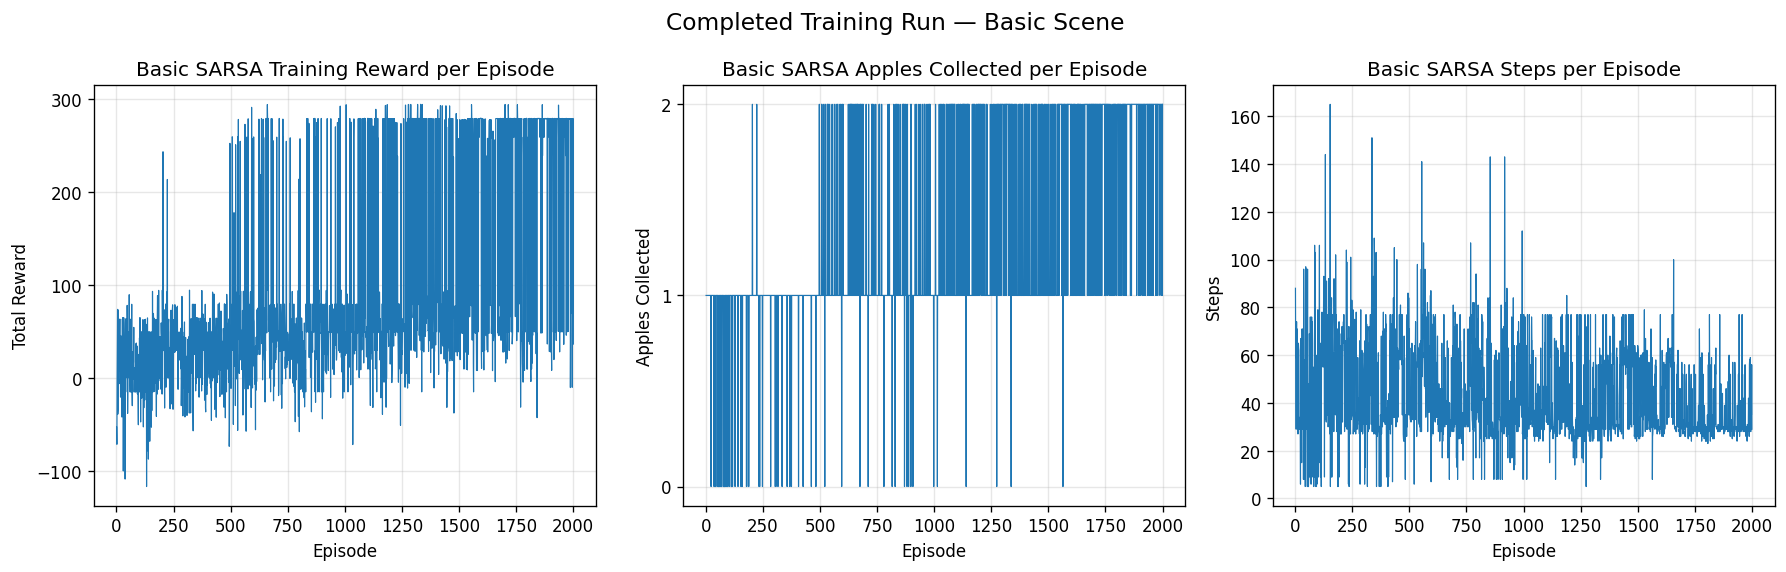

In [1]:
# Load the completed Basic training run from the same working directory.
basic_results_df = pd.read_csv("training_results_basic_improved.csv")

# The Basic CSV records score as 0/10/20, so 10 points correspond to one collected apple.
basic_results_df["apples_collected"] = basic_results_df["score"] / 10.0

print("""Loaded: `training_results_basic_improved.csv`
Episodes recorded: 2000
Average reward per episode: 98.31
Average apples collected per episode: 1.27
Average steps per episode: 43.23

SARSA Critic Value Loss: **Not applicable** (tabular SARSA has no separate critic network).""")


## 8. Basic Scene — Deterministic Evaluation

This evaluates the learned Basic Q-table with **exploration OFF**.

In [ ]:
import asyncio
import json
import os



# ============================================================
# CONFIG
# ============================================================

NUM_TEST_EPISODES = 100
MAX_STEPS = 500
NUM_ACTIONS = 6

Q_TABLE_PATH = "results_basic_improved/q_table_basic_improved.json"


# ============================================================
# LOAD Q-TABLE
# ============================================================

def load_q_table(agent: BasicSARSAAgent, path: str) -> None:

    with open(
        path,
        "r",
        encoding="utf-8",
    ) as file:

        data = json.load(file)

    # Convert JSON keys back to strings used by your SARSA state.
    if hasattr(agent, "q_table"):
        agent.q_table = data

    elif hasattr(agent, "Q"):
        agent.Q = data

    else:
        raise AttributeError(
            "SARSAAgent has neither q_table nor Q."
        )


# ============================================================
# GREEDY ACTION
# ============================================================
VALID_ACTIONS = (0, 1, 2, 4, 5)

def greedy_action(
    agent: BasicSARSAAgent,
    state: str,
) -> int:

    if hasattr(agent, "Q"):
        q_values = agent.Q.get(
            state,
            [0.0] * NUM_ACTIONS,
        )

    elif hasattr(agent, "q_table"):
        q_values = agent.q_table.get(
            state,
            [0.0] * NUM_ACTIONS,
        )

    else:
        raise AttributeError(
            "SARSAAgent has neither Q nor q_table."
        )

    return max(
        VALID_ACTIONS,
        key=lambda action: q_values[action],
    )

# ============================================================
# TEST
# ============================================================

async def evaluate_basic() -> None:

    print("=" * 60)
    print("SARSA V14 GREEDY EVALUATION")
    print("=" * 60)

    print(
        f"Q-table:       {Q_TABLE_PATH}"
    )

    print(
        f"Episodes:      {NUM_TEST_EPISODES}"
    )

    print(
        f"Max steps:     {MAX_STEPS}"
    )

    print(
        "Exploration:   OFF"
    )

    print()

    # Create agent only as a container for the learned table.
    agent = BasicSARSAAgent(
        n_actions=NUM_ACTIONS,
        alpha=0.15,
        gamma=0.997,
        epsilon=0.0,
        epsilon_min=0.0,
        epsilon_decay=1.0,
    )

    load_q_table(
        agent,
        Q_TABLE_PATH,
    )

    env = GodotEnvironment()

    await env.connect()

    successes = 0
    scores = []
    steps_list = []

    for episode in range(
        1,
        NUM_TEST_EPISODES + 1,
    ):

        (
            state,
            _reward,
            done,
            score,
        ) = await env.reset()

        steps = 0
        total_reward = 0.0

        while (
            not done
            and steps < MAX_STEPS
        ):

            steps += 1

            action = greedy_action(
                agent,
                state,
            )

            (
                next_state,
                reward,
                done,
                score,
            ) = await env.step(
                action
            )

            total_reward += reward
            state = next_state

        if score >= 20:
            successes += 1

        scores.append(score)
        steps_list.append(steps)

        if episode % 10 == 0:

            print(
                f"Episode {episode:3d}/"
                f"{NUM_TEST_EPISODES} | "
                f"Successes: {successes:3d} | "
                f"Current score: {score:2d}"
            )


    # ========================================================
    # SUMMARY
    # ========================================================

    success_rate = (
        successes
        / NUM_TEST_EPISODES
        * 100.0
    )

    average_score = (
        sum(scores)
        / len(scores)
    )

    average_steps = (
        sum(steps_list)
        / len(steps_list)
    )

    zero_apples = sum(
        1
        for score in scores
        if score == 0
    )

    one_apple = sum(
        1
        for score in scores
        if score == 10
    )

    two_apples = sum(
        1
        for score in scores
        if score >= 20
    )

    print()
    print("=" * 60)
    print("GREEDY EVALUATION COMPLETE")
    print("=" * 60)

    print(
        f"0 apples:      "
        f"{zero_apples}/{NUM_TEST_EPISODES}"
    )

    print(
        f"1 apple:       "
        f"{one_apple}/{NUM_TEST_EPISODES}"
    )

    print(
        f"2 apples:      "
        f"{two_apples}/{NUM_TEST_EPISODES}"
    )

    print(
        f"Successes:     "
        f"{successes}/{NUM_TEST_EPISODES}"
    )

    print(
        f"Success rate:  "
        f"{success_rate:.2f}%"
    )

    print(
        f"Average score: "
        f"{average_score:.2f}"
    )

    print(
        f"Average steps: "
        f"{average_steps:.2f}"
    )

    await env.close()


### Basic evaluation

Keep the **Basic Godot scene running**, then run the next cell.

It performs 100 greedy evaluation episodes.

In [ ]:
await evaluate_basic()

## 9. Advanced Scene — State Representation

The existing Advanced Godot state representation is included below as source/documentation.

```gdscript

extends Node

const TARGET_THRESHOLD := 45.0
const SNAIL_CLOSE := 85.0
const SNAIL_MEDIUM := 200.0
const SAME_Y_THRESHOLD := 55.0
const WALL_CHECK_DISTANCE := 75.0

var previous_snail_id: int = 0
var previous_snail_distance: float = -1.0
var snail_approach_state: int = 0


func reset_tracking() -> void:
	previous_snail_id = 0
	previous_snail_distance = -1.0
	snail_approach_state = 0


func get_ordered_apples(apples: Node) -> Array:
	var result: Array = []

	if apples == null:
		return result

	_collect_apples(apples, result)

	return result


func _collect_apples(node: Node, result: Array) -> void:
	for child in node.get_children():
		if child is Node2D and child.has_method("reset_apple"):
			result.append(child)

		_collect_apples(child, result)


func is_collected(apple: Node2D) -> bool:
	if apple == null:
		return false

	var value: Variant = apple.get("already_collected")

	if value == null:
		return false

	return bool(value)


func get_apple_collection_mask(apples: Node) -> int:
	var ordered: Array = get_ordered_apples(apples)
	var mask: int = 0

	for i in range(min(3, ordered.size())):
		var apple: Node2D = ordered[i]

		if not is_collected(apple):
			continue

		mask |= 1 << i

	return mask


func get_collected_apple_count(apples: Node) -> int:
	var ordered: Array = get_ordered_apples(apples)
	var count: int = 0

	for i in range(min(3, ordered.size())):
		if is_collected(ordered[i]):
			count += 1

	return count


func get_route_stage(
	_player: CharacterBody2D,
	apples: Node
) -> int:

	return get_collected_apple_count(apples)

func get_target_position(
	player: CharacterBody2D,
	apples: Node
) -> Vector2:

	var ordered: Array = get_ordered_apples(apples)

	var nearest: Node2D = null
	var nearest_distance: float = INF

	for apple in ordered:

		if apple == null:
			continue

		if is_collected(apple):
			continue

		var distance: float = (
			player.global_position.distance_to(
				apple.global_position
			)
		)

		if distance < nearest_distance:

			nearest_distance = distance
			nearest = apple

	if nearest != null:
		return nearest.global_position

	return player.global_position

func get_target_x_direction(
	player: CharacterBody2D,
	target: Vector2
) -> int:
	var dx: float = target.x - player.global_position.x

	if dx < -TARGET_THRESHOLD:
		return -1
	if dx > TARGET_THRESHOLD:
		return 1

	return 0


func get_target_y_direction(
	player: CharacterBody2D,
	target: Vector2
) -> int:
	var dy: float = target.y - player.global_position.y

	if dy < -TARGET_THRESHOLD:
		return -1
	if dy > TARGET_THRESHOLD:
		return 1

	return 0


func get_target_distance(
	player: CharacterBody2D,
	target: Vector2
) -> int:
	var distance: float = player.global_position.distance_to(target)

	if distance < 120.0:
		return 0
	if distance < 300.0:
		return 1

	return 2


func _wall_ray(
	player: CharacterBody2D,
	direction: float,
	y_offset: float
) -> bool:
	var start: Vector2 = (
		player.global_position
		+ Vector2(direction * 15.0, y_offset)
	)

	var end: Vector2 = (
		start
		+ Vector2(direction * WALL_CHECK_DISTANCE, 0.0)
	)

	var query := PhysicsRayQueryParameters2D.create(
		start,
		end
	)

	query.collision_mask = 1
	query.exclude = [player.get_rid()]

	var result: Dictionary = (
		player
		.get_world_2d()
		.direct_space_state
		.intersect_ray(query)
	)

	return not result.is_empty()


func get_wall_low(player: CharacterBody2D) -> int:
	var direction: float = (
		1.0 if player.velocity.x >= 0.0 else -1.0
	)

	return int(
		_wall_ray(player, direction, 8.0)
	)


func get_wall_high(player: CharacterBody2D) -> int:
	var direction: float = (
		1.0 if player.velocity.x >= 0.0 else -1.0
	)

	return int(
		_wall_ray(player, direction, -32.0)
	)


func get_vertical_motion(player: CharacterBody2D) -> int:
	if player.velocity.y < -60.0:
		return 0
	if player.velocity.y > 60.0:
		return 2

	return 1


func get_nearest_snail(
	player: CharacterBody2D,
	enemies: Node
) -> Node2D:
	if enemies == null:
		return null

	var nearest: Node2D = null
	var nearest_distance: float = INF

	for child in enemies.get_children():
		if not child is Node2D:
			continue

		var snail: Node2D = child as Node2D
		var distance: float = player.global_position.distance_to(
			snail.global_position
		)

		if distance < nearest_distance:
			nearest_distance = distance
			nearest = snail

	return nearest


func update_snail_tracking(
	player: CharacterBody2D,
	enemies: Node
) -> void:
	var snail: Node2D = get_nearest_snail(player, enemies)

	if snail == null:
		previous_snail_id = 0
		previous_snail_distance = -1.0
		snail_approach_state = 0
		return

	var snail_id: int = snail.get_instance_id()
	var current_distance: float = (
		player.global_position.distance_to(
			snail.global_position
		)
	)

	if (
		snail_id != previous_snail_id
		or previous_snail_distance < 0.0
	):
		snail_approach_state = 0
	else:
		var change: float = (
			current_distance
			- previous_snail_distance
		)

		if change < -5.0:
			snail_approach_state = 1
		elif change > 5.0:
			snail_approach_state = 2
		else:
			snail_approach_state = 3

	previous_snail_id = snail_id
	previous_snail_distance = current_distance


func get_snail_approach_state(
	_player: CharacterBody2D,
	_enemies: Node
) -> int:
	return snail_approach_state


func get_snail_relative_x(
	player: CharacterBody2D,
	enemies: Node
) -> int:
	var snail: Node2D = get_nearest_snail(player, enemies)

	if snail == null:
		return 0

	var dx: float = snail.global_position.x - player.global_position.x

	if dx < -200.0:
		return 0
	if dx < -50.0:
		return 1
	if dx > 200.0:
		return 4
	if dx > 50.0:
		return 3

	return 2


func get_snail_relative_y(
	player: CharacterBody2D,
	enemies: Node
) -> int:
	var snail: Node2D = get_nearest_snail(player, enemies)

	if snail == null:
		return 0

	var dy: float = snail.global_position.y - player.global_position.y

	if dy < -120.0:
		return 0
	if dy < -SAME_Y_THRESHOLD:
		return 1
	if dy > 120.0:
		return 4
	if dy > SAME_Y_THRESHOLD:
		return 3

	return 2


func get_snail_same_y(
	player: CharacterBody2D,
	enemies: Node
) -> int:
	var snail: Node2D = get_nearest_snail(player, enemies)

	if snail == null:
		return 0

	return int(
		absf(
			snail.global_position.y
			- player.global_position.y
		) <= SAME_Y_THRESHOLD
	)


func get_snail_distance(
	player: CharacterBody2D,
	enemies: Node
) -> int:
	var snail: Node2D = get_nearest_snail(player, enemies)

	if snail == null:
		return 0

	var distance: float = player.global_position.distance_to(
		snail.global_position
	)

	if distance <= SNAIL_CLOSE:
		return 1
	if distance <= SNAIL_MEDIUM:
		return 2

	return 3


func get_danger_zone(pos: Vector2) -> int:
	return int(
		pos.x >= 950.0
		and pos.y >= 580.0
	)


func get_state(
	player: CharacterBody2D,
	apples: Node,
	enemies: Node
) -> String:
	var target: Vector2 = get_target_position(
		player,
		apples
	)

	var stage: int = get_route_stage(
		player,
		apples
	)

	var target_x: int = get_target_x_direction(
		player,
		target
	)

	var target_y: int = get_target_y_direction(
		player,
		target
	)

	var target_distance: int = get_target_distance(
		player,
		target
	)

	var wall_low: int = get_wall_low(player)
	var wall_high: int = get_wall_high(player)

	var snail_x: int = get_snail_relative_x(
		player,
		enemies
	)

	var snail_y: int = get_snail_relative_y(
		player,
		enemies
	)

	var snail_same_y: int = get_snail_same_y(
		player,
		enemies
	)

	var snail_distance: int = get_snail_distance(
		player,
		enemies
	)

	var ground: int = int(player.is_on_floor())
	var vertical: int = get_vertical_motion(player)
	var danger: int = get_danger_zone(player.global_position)

	return str(
		stage, ",",
		target_x, ",",
		target_y, ",",
		target_distance, ",",
		wall_low, ",",
		wall_high, ",",
		snail_x, ",",
		snail_y, ",",
		snail_same_y, ",",
		snail_distance, ",",
		snail_approach_state, ",",
		ground, ",",
		vertical, ",",
		danger
	)

```

## 10. Advanced Scene — Environment and Reward Design

The existing Advanced Godot environment and reward implementation is included below.

```gdscript

extends Node

# ============================================================
# ADVANCED SARSA ENVIRONMENT
# ============================================================
#
# Designed around a 3-apple ordered route:
#
#   Apple 1: upper-left
#       ↓
#   Apple 2: left-most / lower-left
#       ↓
#   Apple 3: middle-bottom/right
#
# Main learning goals:
# - approach the required apple
# - walk when no jump is needed
# - jump primarily for same-level snail encounters
# - detect walls and reverse
# - tolerate exploration/death without excessive death penalty
# - prefer safer progress
# - leave bottom-right danger area
# - punish excessive waiting
# - immediately pursue the remaining objective
# ============================================================


var current_reward: float = 0.0
var score: int = 0
var episode_done: bool = false
var step_in_progress: bool = false

var stuck_steps: int = 0
var collected_apples_seen: int = 0

var bottom_right_stay_steps: int = 0

var previous_target_distance: float = -1.0
var previous_player_x: float = 0.0


# ------------------------------------------------------------
# ACTION TIMING
# ------------------------------------------------------------

const ACTION_FRAMES := 10


# ------------------------------------------------------------
# APPLE REWARDS
# ------------------------------------------------------------
#
# Large completion reward dominates the objective.
# Death is deliberately not enormous so exploration remains
# worthwhile.
# ------------------------------------------------------------

const FIRST_APPLE_REWARD := 60.0
const SECOND_APPLE_REWARD := 90.0
const THIRD_APPLE_REWARD := 120.0

const COMPLETION_REWARD := 300.0


# ------------------------------------------------------------
# GENERAL SHAPING
# ------------------------------------------------------------

const TIME_PENALTY := -0.12
const PROGRESS_REWARD := 0.45
const SAFE_PROGRESS_BONUS := 0.20
const WRONG_DIRECTION_PENALTY := -0.18
const UPWARD_TARGET_PROGRESS_REWARD := 0.30

const STUCK_PENALTY := -2.0


# ------------------------------------------------------------
# WALK / JUMP SHAPING
# ------------------------------------------------------------

# Small encouragement for normal walking.
const WALK_PROGRESS_BONUS := 0.10

# Discourage unnecessary jumping when there is no relevant
# same-level snail.
const UNNECESSARY_JUMP_PENALTY := -0.10
const TARGET_JUMP_BONUS := 0.60

# Encourage jump-over-snail behavior when the snail is on
# approximately the same level and is close/approaching.
const SNAIL_JUMP_BONUS := 0.75

# Small encouragement to wait briefly when a same-level snail
# is approaching. Time penalty still applies.
const GOOD_WAIT_BONUS := 0.20

# Stronger penalty for moving into a dangerous nearby snail
# without jumping.
const CLOSE_SNAIL_NO_JUMP_PENALTY := -0.60


# ------------------------------------------------------------
# WALL SHAPING
# ------------------------------------------------------------

const WALL_HIT_PENALTY := -1.0
const WALL_REVERSE_BONUS := 0.25


# ------------------------------------------------------------
# BOTTOM-RIGHT LOITERING
# ------------------------------------------------------------

const BOTTOM_RIGHT_STEP_PENALTY := -1.25
const BOTTOM_RIGHT_EXTRA_PENALTY := -2.0

const BOTTOM_RIGHT_WARNING_STEPS := 5
const BOTTOM_RIGHT_MAX_STEPS := 15


# ------------------------------------------------------------
# DEATH
# ------------------------------------------------------------

const DEATH_PENALTY := -25.0


# ------------------------------------------------------------
# NODE REFERENCES
# ------------------------------------------------------------

@onready var state_tracker: Node = $RLState

@onready var player: CharacterBody2D = (
	$"../LevelRoot/Player"
)

@onready var enemies: Node = (
	$"../LevelRoot/Enemies"
)

@onready var apples: Node = (
	$"../LevelRoot/Apple"
)


func _ready() -> void:

	print(
		"=== ADVANCED SARSA RL ENVIRONMENT STARTED ==="
	)

	print(
		"[ADVANCED] Apple collection order: ANY ORDER"
		)

	print(
        "[ADVANCED] Target selection: nearest uncollected apple"
	)

	_refresh_level_references()
	_connect_signals()


# ============================================================
# SIGNALS
# ============================================================

func _connect_signals() -> void:

	if enemies != null:

		_connect_enemy_signals_recursive(
			enemies
		)

	if apples != null:

		_connect_apple_signals_recursive(
			apples
		)


func _connect_enemy_signals_recursive(
	node: Node
) -> void:

	for child in node.get_children():

		if child.has_signal("player_died"):

			if not child.player_died.is_connected(
				_on_player_died
			):

				child.player_died.connect(
					_on_player_died
				)

		_connect_enemy_signals_recursive(
			child
		)


func _connect_apple_signals_recursive(
	node: Node
) -> void:

	for child in node.get_children():

		if child.has_signal("collected"):

			if not child.collected.is_connected(
				_on_apple_collected
			):

				child.collected.connect(
					_on_apple_collected
				)

		_connect_apple_signals_recursive(
			child
		)


# ============================================================
# RESET
# ============================================================

func reset() -> void:

	if step_in_progress:
		return

	current_reward = 0.0
	score = 0
	episode_done = false
	step_in_progress = false

	stuck_steps = 0
	collected_apples_seen = 0
	bottom_right_stay_steps = 0

	previous_target_distance = -1.0
	previous_player_x = 0.0

	if state_tracker.has_method("reset_tracking"):

		state_tracker.reset_tracking()

	get_parent().reset_level()

	_refresh_level_references()
	_connect_signals()


# ============================================================
# STEP
# ============================================================

func step(
	action: int
) -> Dictionary:

	if episode_done:

		return {
			"state": get_state(),
			"reward": 0.0,
			"done": true,
			"score": score
		}


	if step_in_progress:

		return {
			"state": get_state(),
			"reward": 0.0,
			"done": episode_done,
			"score": score
		}


	step_in_progress = true


	# --------------------------------------------------------
	# BEFORE ACTION
	# --------------------------------------------------------

	var position_before := (
		Vector2(player.global_position)
	)

	var target_before := (
		get_target_position()
	)

	var target_distance_before := (
		position_before.distance_to(
			target_before
		)
	)



	# Time penalty every step.
	current_reward += TIME_PENALTY


	# --------------------------------------------------------
	# ACTION
	# --------------------------------------------------------

	player.set_rl_action(action)


	for _i in range(ACTION_FRAMES):

		await get_tree().physics_frame

		if episode_done:
			break


	# --------------------------------------------------------
	# AFTER ACTION
	# --------------------------------------------------------

	var position_after := (
		Vector2(player.global_position)
	)

	var target_after := (
		get_target_position()
	)

	var target_distance_after := (
		position_after.distance_to(
			target_after
		)
	)


	var reward := consume_reward()


	# ========================================================
	# 1. APPROACH TARGET
	# ========================================================

	var distance_change := (
		target_distance_before
		- target_distance_after
	)


	if distance_change > 4.0:

		reward += PROGRESS_REWARD


		# Additional safe-progress bonus when the agent is
		# moving toward its target without being in immediate
		# snail danger.
		if not _snail_is_immediately_dangerous():

			reward += SAFE_PROGRESS_BONUS


		# Normal walking is mildly preferred.
		if (
			action == 1
			or action == 2
		):

			reward += WALK_PROGRESS_BONUS


	elif distance_change < -20.0:

		reward += WRONG_DIRECTION_PENALTY

	# ========================================================
	# 1B. UPWARD TARGET PROGRESS
	# ========================================================

	var target_position_for_vertical := get_target_position()

	var target_y_direction_for_vertical: int = (
		state_tracker.get_target_y_direction(
			player,
			target_position_for_vertical
		)
	)

	if (
		target_y_direction_for_vertical < 0
		and position_after.y < position_before.y - 5.0
	):
		reward += UPWARD_TARGET_PROGRESS_REWARD

	# ========================================================
	# 2. JUMP SHAPING
	# ========================================================
	#
	# 4 = LEFT + JUMP
	# 5 = RIGHT + JUMP
	# ========================================================

	if action == 4 or action == 5:

		var target_position := get_target_position()

		var target_x_direction: int = (
			state_tracker.get_target_x_direction(
				player,
				target_position
			)
		)

		var target_y_direction: int = (
			state_tracker.get_target_y_direction(
				player,
				target_position
			)
		)

		var target_requires_upward_jump := (
			target_y_direction < 0
		)

		var jump_toward_target := (
			(action == 4 and target_x_direction < 0)
			or
			(action == 5 and target_x_direction > 0)
		)

		if (
			target_requires_upward_jump
			and jump_toward_target
		):

			reward += TARGET_JUMP_BONUS

		elif _good_snail_jump_opportunity():

			reward += SNAIL_JUMP_BONUS

		else:

			reward += UNNECESSARY_JUMP_PENALTY
	# ========================================================
	# 3. WAITING FOR APPROACHING SNAIL
	# ========================================================

	if action == 0 and _good_wait_opportunity():

		reward += GOOD_WAIT_BONUS


	# ========================================================
	# 4. WALKING INTO A CLOSE SNAIL
	# ========================================================

	if (
		(action == 1 or action == 2)
		and _snail_is_immediately_dangerous()
		and not _good_snail_jump_opportunity()
	):

		reward += CLOSE_SNAIL_NO_JUMP_PENALTY


	# ========================================================
	# 5. WALL DETECTION / REVERSE
	# ========================================================

	reward += (
		_handle_wall_behavior(
			action
		)
	)


	# ========================================================
	# 6. STUCK
	# ========================================================

	var movement := (
		position_before.distance_to(
			position_after
		)
	)

	if movement < 15.0 and not episode_done:

		stuck_steps += 1

	else:

		stuck_steps = 0


	if (
		stuck_steps >= 3
		and not episode_done
	):

		reward += STUCK_PENALTY

		stuck_steps = 0


	# ========================================================
	# 7. BOTTOM-RIGHT
	# ========================================================

	if not episode_done:

		reward += (
			handle_bottom_right_loitering()
		)


	# Make the state tracker compare the next frame against
	# this frame.
	previous_target_distance = target_distance_after
	previous_player_x = position_after.x


	step_in_progress = false


	return {
		"state": get_state(),
		"reward": reward,
		"done": episode_done,
		"score": score
	}


# ============================================================
# SNAIL HELPERS
# ============================================================

func _get_nearest_snail() -> Node2D:

	if enemies == null:
		return null

	var nearest: Node2D = null
	var nearest_distance := INF

	for child in enemies.get_children():

		if not child is Node2D:
			continue

		var snail := child as Node2D

		var distance := (
			player.global_position.distance_to(
				snail.global_position
			)
		)

		if distance < nearest_distance:

			nearest_distance = distance
			nearest = snail


	return nearest


func _snail_is_same_y() -> bool:

	var snail := _get_nearest_snail()

	if snail == null:
		return false

	return (
		absf(
			snail.global_position.y
			- player.global_position.y
		) <= 55.0
	)


func _snail_distance() -> float:

	var snail := _get_nearest_snail()

	if snail == null:
		return INF

	return (
		player.global_position.distance_to(
			snail.global_position
		)
	)


func _snail_is_approaching() -> bool:

	var value: Variant = (
		state_tracker.call(
			"get_snail_approach_state",
			player,
			enemies
		)
	)

	return int(value) == 1


func _snail_is_immediately_dangerous() -> bool:

	return (
		_snail_is_same_y()
		and _snail_distance() <= 110.0
	)


func _good_snail_jump_opportunity() -> bool:

	if not _snail_is_same_y():
		return false

	var distance := _snail_distance()

	if distance > 150.0:
		return false

	return (
		_snail_is_approaching()
		or distance <= 70.0
	)


func _good_wait_opportunity() -> bool:

	if not _snail_is_same_y():
		return false

	var distance := _snail_distance()

	if distance < 60.0:
		return false

	if distance > 170.0:
		return false

	return _snail_is_approaching()


# ============================================================
# WALL BEHAVIOR
# ============================================================

func _handle_wall_behavior(
	action: int
) -> float:

	var reward: float = 0.0

	var wall_low: int = int(
		state_tracker.get_wall_low(player)
	)

	var wall_high: int = int(
		state_tracker.get_wall_high(player)
	)

	var target_x: int = (
		state_tracker.get_target_x_direction(
			player,
			get_target_position()
		)
	)

	# A low obstacle directly ahead should discourage
	# continuing into it.
	if wall_low == 1:

		if (
			(target_x < 0 and action == 1)
			or (target_x > 0 and action == 2)
		):
			reward += WALL_HIT_PENALTY

		# Encourage changing direction when a low obstacle
		# blocks the intended direction.
		if (
			target_x < 0
			and action == 2
		):
			reward += WALL_REVERSE_BONUS

		if (
			target_x > 0
			and action == 1
		):
			reward += WALL_REVERSE_BONUS

	# A low obstacle with free space above it is a useful
	# jump situation.
	if (
		wall_low == 1
		and wall_high == 0
		and (action == 4 or action == 5)
	):
		reward += 0.35

	return reward


# ============================================================
# BOTTOM-RIGHT LOITERING
# ============================================================

func handle_bottom_right_loitering() -> float:

	var pos := Vector2(
		player.global_position
	)

	var in_bottom_right := (
		pos.x >= 950.0
		and pos.y >= 580.0
	)

	if not in_bottom_right:

		bottom_right_stay_steps = 0

		return 0.0


	bottom_right_stay_steps += 1

	var penalty := (
		BOTTOM_RIGHT_STEP_PENALTY
	)


	if (
		bottom_right_stay_steps
		> BOTTOM_RIGHT_WARNING_STEPS
	):

		penalty += (
			BOTTOM_RIGHT_EXTRA_PENALTY
		)

	# Do not terminate the episode just because the player
	# passes through this region. The agent may legitimately
	# need to cross the right side while navigating to the
	# next apple.
	#
	# The penalty increases while it remains in the region,
	# so SARSA learns to leave it rather than repeatedly
	# waiting there.


	return penalty


# ============================================================
# APPLE COLLECTION
# ============================================================

func _on_apple_collected() -> void:

	var current_count: int = (
		state_tracker.get_collected_apple_count(
			apples
		)
	)

	if current_count <= collected_apples_seen:
		return

	collected_apples_seen = current_count

	# --------------------------------------------------------
	# APPLES CAN BE COLLECTED IN ANY ORDER
	# --------------------------------------------------------

	if current_count == 1:

		add_reward(
			FIRST_APPLE_REWARD
		)

		score = 10

		print(
			"[ADVANCED] 1 APPLE COLLECTED: +60"
		)

	elif current_count == 2:

		add_reward(
			SECOND_APPLE_REWARD
		)

		score = 20

		print(
			"[ADVANCED] 2 APPLES COLLECTED: +90"
		)

	elif current_count == 3:

		add_reward(
			THIRD_APPLE_REWARD
		)

		score = 30

		add_reward(
			COMPLETION_REWARD
		)

		episode_done = true

		print(
			"[ADVANCED] ALL 3 APPLES COLLECTED: "
			+ "+300 COMPLETION -> SUCCESS"
		)

# ============================================================
# DEATH
# ============================================================

func _on_player_died(
	_body: Node
) -> void:

	add_reward(
		DEATH_PENALTY
	)

	episode_done = true

	print(
		"[ADVANCED] PLAYER DIED: -25 -> "
		+ "EPISODE FAILURE"
	)


# ============================================================
# STATE ACCESS
# ============================================================

func get_state() -> String:

	return state_tracker.get_state(
		player,
		apples,
		enemies
	)


func get_target_position() -> Vector2:

	return state_tracker.get_target_position(
		player,
		apples
	)


func get_score() -> int:

	return score


func is_done() -> bool:

	return episode_done


# ============================================================
# REWARD BUFFER
# ============================================================

func add_reward(
	amount: float
) -> void:

	current_reward += amount


func consume_reward() -> float:

	var reward := current_reward

	current_reward = 0.0

	return reward


# ============================================================
# REFERENCES
# ============================================================

func _refresh_level_references() -> void:

	player = $"../LevelRoot/Player"
	enemies = $"../LevelRoot/Enemies"
	apples = $"../LevelRoot/Apple"

```

## 11. Advanced Scene — Tabular SARSA Agent

This is the existing Advanced tabular SARSA implementation, including its adaptive epsilon-decay and policy-entropy logic.

In [ ]:

import math
import random
from collections import defaultdict


class SARSAAgent:
    VALID_ACTIONS = (0, 1, 2, 4, 5)

    def __init__(
        self,
        n_actions: int = 6,
        alpha: float = 0.15,
        gamma: float = 0.997,
        epsilon: float = 0.35,
        epsilon_min: float = 0.06,
        epsilon_decay: float = 0.999,
    ):
        if n_actions != 6:
            raise ValueError(
                "The Godot action space must contain 6 IDs."
            )

        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma

        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.Q = defaultdict(
            lambda: [0.0] * self.n_actions
        )

        self.episode = 0
        self.total_steps = 0

        self.recent_success = []
        self.early_episodes = 150

    def act(self, state, explore: bool = True) -> int:
        if (
            explore
            and random.random() < self.epsilon
        ):
            return random.choice(self.VALID_ACTIONS)

        q_values = self.Q[state]

        best_value = max(
            q_values[action]
            for action in self.VALID_ACTIONS
        )

        best_action = min(
            action
            for action in self.VALID_ACTIONS
            if q_values[action] == best_value
        )

        return best_action

    def update(
        self,
        state,
        action: int,
        reward: float,
        next_state,
        next_action,
        done: bool,
    ) -> float:
        current_q = self.Q[state][action]

        if done:
            target = reward
        else:
            if next_action is None:
                raise ValueError(
                    "next_action is required for SARSA."
                )

            target = (
                reward
                + self.gamma
                * self.Q[next_state][next_action]
            )

        td_error = target - current_q

        self.Q[state][action] = (
            current_q
            + self.alpha * td_error
        )

        self.total_steps += 1

        return abs(td_error)

    def record_success(self, success: bool) -> None:
        self.recent_success.append(
            1 if success else 0
        )

        if len(self.recent_success) > 50:
            self.recent_success.pop(0)

    def end_episode(self) -> None:
        self.episode += 1

        if self.episode <= self.early_episodes:
            decay = 0.9995
        else:
            recent_rate = (
                sum(self.recent_success)
                / len(self.recent_success)
                if self.recent_success
                else 0.0
            )

            if recent_rate >= 0.70:
                decay = 0.985
            elif recent_rate >= 0.40:
                decay = 0.992
            else:
                decay = self.epsilon_decay

        self.epsilon = max(
            self.epsilon_min,
            self.epsilon * decay,
        )

    def policy_entropy(self) -> float:
        n = len(self.VALID_ACTIONS)

        p_other = self.epsilon / n
        p_best = (
            (1.0 - self.epsilon)
            + p_other
        )

        entropy = 0.0

        if p_best > 0.0:
            entropy -= (
                p_best
                * math.log(p_best)
            )

        for _ in range(n - 1):
            if p_other > 0.0:
                entropy -= (
                    p_other
                    * math.log(p_other)
                )

        return entropy


In [ ]:
AdvancedSARSAAgent = SARSAAgent
print("Advanced SARSA agent ready.")

## 12. Advanced Scene — Training

### Configuration

- Episodes: **1,000**
- Maximum steps: **450**
- α: **0.15**
- γ: **0.997**
- ε start: **0.50**
- ε minimum: **0.06**
- ε decay base: **0.999**
- Seed: **43**
- Objective: collect all **3 apples**

The next cell defines the training function. The following cell executes it.

In [ ]:

import asyncio
import csv
import json
import os
import random



NUM_EPISODES = 1000
MAX_STEPS = 450

LEARNING_RATE = 0.15
DISCOUNT_FACTOR = 0.997

EPSILON_START = 0.50
EPSILON_MIN = 0.06
EPSILON_DECAY = 0.999

NUM_ACTIONS = 6

RESULTS_DIR = "results_advanced_sarsa_v3"

Q_TABLE_PATH = os.path.join(
    RESULTS_DIR,
    "q_table_advanced_sarsa_v3.json",
)

TRAINING_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "training_results_advanced_sarsa_v3.csv",
)

SEED = 43


async def train_advanced() -> None:
    random.seed(SEED)

    os.makedirs(
        RESULTS_DIR,
        exist_ok=True,
    )

    print("=" * 65)
    print("ADVANCED TABULAR SARSA")
    print("=" * 65)
    print("Episodes:         ", NUM_EPISODES)
    print("Max steps:        ", MAX_STEPS)
    print("Alpha:             ", LEARNING_RATE)
    print("Gamma:             ", DISCOUNT_FACTOR)
    print("Epsilon start:     ", EPSILON_START)
    print("Epsilon minimum:  ", EPSILON_MIN)
    print()
    print("Route: Any apple order")
    print("Target: nearest remaining apple")
    print("Target: remaining apple relative position")
    print("State: compact")
    print("Exploration: epsilon-greedy")
    print()

    env = GodotEnvironment()

    await env.connect()

    agent = AdvancedSARSAAgent(
        n_actions=NUM_ACTIONS,
        alpha=LEARNING_RATE,
        gamma=DISCOUNT_FACTOR,
        epsilon=EPSILON_START,
        epsilon_min=EPSILON_MIN,
        epsilon_decay=EPSILON_DECAY,
    )

    results = []

    for episode in range(
        1,
        NUM_EPISODES + 1,
    ):
        state, reward, done, score = (
            await env.reset()
        )

        action = agent.act(
            state,
            explore=True,
        )

        total_reward = 0.0
        steps = 0
        best_score = 0

        while (
            not done
            and steps < MAX_STEPS
        ):
            steps += 1

            (
                next_state,
                reward,
                done,
                score,
            ) = await env.step(action)

            total_reward += reward

            best_score = max(
                best_score,
                score,
            )

            if done:
                next_action = None
            else:
                next_action = agent.act(
                    next_state,
                    explore=True,
                )

            agent.update(
                state,
                action,
                reward,
                next_state,
                next_action,
                done,
            )

            state = next_state

            if not done:
                action = next_action

        truncated = (
            steps >= MAX_STEPS
            and not done
        )

        two_success = (
            1 if best_score >= 20 else 0
        )

        three_success = (
            1 if best_score >= 30 else 0
        )

        agent.record_success(
            three_success == 1
        )

        agent.end_episode()

        results.append(
            {
                "episode": episode,
                "steps": steps,
                "reward": total_reward,
                "score": best_score,
                "apples": min(
                    3,
                    best_score // 10,
                ),
                "two_apple_success": two_success,
                "three_apple_success": three_success,
                "epsilon": agent.epsilon,
                "entropy": agent.policy_entropy(),
                "truncated": int(truncated),
            }
        )

        if episode % 50 == 0:
            recent = results[-50:]

            zero = sum(
                1
                for row in recent
                if row["apples"] == 0
            )

            one = sum(
                1
                for row in recent
                if row["apples"] == 1
            )

            two = sum(
                1
                for row in recent
                if row["apples"] == 2
            )

            three = sum(
                1
                for row in recent
                if row["apples"] == 3
            )

            two_rate = (
                sum(
                    row["two_apple_success"]
                    for row in recent
                )
                / 50.0
                * 100.0
            )

            three_rate = (
                sum(
                    row["three_apple_success"]
                    for row in recent
                )
                / 50.0
                * 100.0
            )

            print()
            print(
                f"--- Last 50 episodes "
                f"({episode}) ---"
            )
            print(f"0 apples:       {zero:2d}/50")
            print(f"1 apple:        {one:2d}/50")
            print(f"2 apples:       {two:2d}/50")
            print(f"3 apples:       {three:2d}/50")
            print(f"2-apple rate:   {two_rate:5.1f}%")
            print(f"3-apple rate:   {three_rate:5.1f}%")
            print(
                f"Epsilon:        "
                f"{agent.epsilon:.4f}"
            )
            print(
                f"Policy entropy: "
                f"{agent.policy_entropy():.4f}"
            )
            print(
                f"Q-table states: "
                f"{len(agent.Q)}"
            )

            if two_rate >= 90.0:
                print(
                    ">>> 90% 2-APPLE MILESTONE <<<"
                )

            if three_rate >= 90.0:
                print(
                    ">>> 90% 3-APPLE COMPLETION <<<"
                )

    with open(
        Q_TABLE_PATH,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                str(state): values
                for state, values in agent.Q.items()
            },
            file,
            indent=2,
        )

    with open(
        TRAINING_RESULTS_PATH,
        "w",
        newline="",
        encoding="utf-8",
    ) as file:
        writer = csv.DictWriter(
            file,
            fieldnames=[
                "episode",
                "steps",
                "reward",
                "score",
                "apples",
                "two_apple_success",
                "three_apple_success",
                "epsilon",
                "entropy",
                "truncated",
            ],
        )

        writer.writeheader()
        writer.writerows(results)

    overall_two = (
        sum(
            row["two_apple_success"]
            for row in results
        )
        / len(results)
        * 100.0
    )

    overall_three = (
        sum(
            row["three_apple_success"]
            for row in results
        )
        / len(results)
        * 100.0
    )

    final = results[-50:]

    final_two = (
        sum(
            row["two_apple_success"]
            for row in final
        )
        / 50.0
        * 100.0
    )

    final_three = (
        sum(
            row["three_apple_success"]
            for row in final
        )
        / 50.0
        * 100.0
    )

    print()
    print("=" * 65)
    print("ADVANCED SARSA TRAINING COMPLETE")
    print("=" * 65)
    print(
        f"Overall 2-apple rate: "
        f"{overall_two:.2f}%"
    )
    print(
        f"Final 50 2-apple rate: "
        f"{final_two:.2f}%"
    )
    print(
        f"Overall 3-apple rate: "
        f"{overall_three:.2f}%"
    )
    print(
        f"Final 50 3-apple rate: "
        f"{final_three:.2f}%"
    )
    print(
        f"Final epsilon: "
        f"{agent.epsilon:.4f}"
    )
    print(
        f"Q-table states: "
        f"{len(agent.Q)}"
    )
    print(
        f"Q-table saved: "
        f"{Q_TABLE_PATH}"
    )
    print(
        f"Results saved: "
        f"{TRAINING_RESULTS_PATH}"
    )

    await env.close()


### Advanced training — SWITCH GODOT NOW

**Stop here and do this before running the next cell:**

1. Stop the Basic Godot run.
2. Run the **Advanced `AdvancedMain.tscn`** scene.
3. Confirm the Godot Output shows the Advanced RL server on port `8765`.
4. Return to this notebook.
5. Run the next cell.

In [ ]:
await train_advanced()

## 13. Advanced Scene — Training Results

These result plots are loaded from the completed training run in `training_results_advanced_sarsa_v3.csv`. **Godot is not required for these cells.**

For tabular SARSA, a separate **Critic Value Loss is not applicable** because the algorithm uses a Q-table rather than an actor-critic value network.

In [ ]:
ADVANCED_RESULTS_CSV = Path(
    "results_advanced_sarsa_v3",
    "training_results_advanced_sarsa_v3.csv",
)

if ADVANCED_RESULTS_CSV.exists():
    advanced_results_df = pd.read_csv(ADVANCED_RESULTS_CSV)

    print(
        f"Episodes recorded: "
        f"{len(advanced_results_df)}"
    )
    print(
        f"Overall 2-apple rate: "
        f"{advanced_results_df['two_apple_success'].mean() * 100:.2f}%"
    )
    print(
        f"Overall 3-apple rate: "
        f"{advanced_results_df['three_apple_success'].mean() * 100:.2f}%"
    )
    print(
        f"Final 50 2-apple rate: "
        f"{advanced_results_df.tail(50)['two_apple_success'].mean() * 100:.2f}%"
    )
    print(
        f"Final 50 3-apple rate: "
        f"{advanced_results_df.tail(50)['three_apple_success'].mean() * 100:.2f}%"
    )
else:
    advanced_results_df = None
    print("Advanced training CSV was not found. Run Advanced training first.")

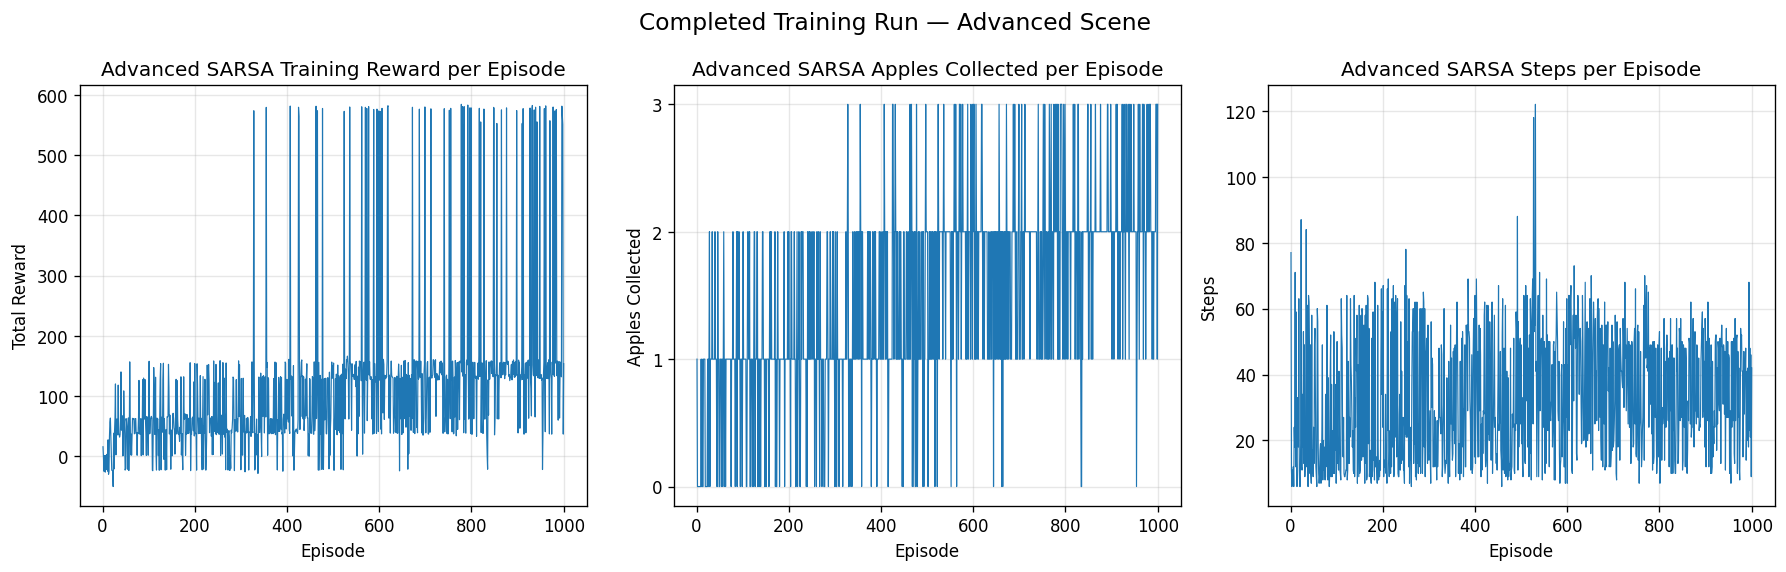

In [1]:
# Load the completed Advanced training run from the same working directory.
advanced_results_df = pd.read_csv("training_results_advanced_sarsa_v3.csv")


print("""Loaded: `training_results_advanced_sarsa_v3.csv`
Episodes recorded: 1000
Average reward per episode: 116.01
Average apples collected per episode: 1.49
Average steps per episode: 32.77

SARSA Critic Value Loss: **Not applicable** (tabular SARSA has no separate critic network).""")


## 14. Pre-trained Q-table Snapshots

The supplied trained Q-tables are retained inside the notebook. Running the next cell materialises them into the same result folders used by the existing evaluation code.

In [ ]:
BASIC_Q_TABLE = {'0,-1,1,1,1,0,0,2,0,0': [17.897679283089104, 46.25713974878725, 30.02525879224278, 0.0, 36.25698389040139, 91.82234897143387], '0,-1,1,0,1,0,0,2,0,0': [65.6051053856759, 53.57762246418875, 55.995409807311646, 0.0, 48.730405802033246, 96.50917191932216], '0,-1,1,0,0,0,0,2,0,0': [63.90643081162231, 67.03985619508731, 66.12118101386805, 0.0, 112.88279229469454, 57.31032506844483], '0,-1,1,0,2,0,0,2,0,0': [71.6187198977691, 113.76050166138616, 70.50059691903259, 0.0, 72.61490745546453, 74.07644852582145], '0,0,1,0,0,0,0,2,0,0': [31.31066998787371, 18.749749165877354, 18.823725060430526, 0.0, 19.890396460907027, 73.24025720133474], '0,0,1,0,1,0,0,2,0,0': [2.9733446391835354, 2.9250844739403847, 35.54616107891984, 0.0, 5.446389836508597, 4.355172006464509], '0,0,1,0,2,0,0,2,0,0': [39.319491245209896, 23.754107625061554, 118.06645608265244, 0.0, 20.68118898588339, 34.90285907717748], '0,0,1,1,1,0,0,2,3,0': [0.4608825853983366, 0.7307827071832347, -0.0075, 0.0, 3.7289286854220243, 52.70101879435745], '0,1,1,1,1,0,0,2,3,0': [-0.25024917805643, 2.2995242859293215, 0.0075, 0.0, 0.09403043269602354, 46.58363291162951], '0,1,1,0,0,0,0,2,0,0': [8.827186578997871, 3.519391017153586, 1.0516798050076228, 0.0, 3.4991225223126676, 43.88876876352387], '0,1,1,0,1,0,0,2,0,0': [3.080553890069282, 0.0, 6.772203083681887, 0.0, -0.02577001564290558, 0.020415375], '0,1,1,0,2,0,0,2,0,0': [1.820704911227352, 1.922730311270393, 54.79087945461479, 0.0, 9.49554895641843, 8.554454838745206], '0,0,-1,1,1,0,0,2,0,0': [49.72880406736036, 123.48463821438766, 56.02125552958083, 0.0, 50.16539886967136, 38.277321514271534], '1,0,0,0,2,0,0,2,0,0': [10.985136294108141, 10.816409737543832, 0.0, 0.0, 67.26644224385333, 8.43482841994551], '0,0,0,0,2,0,0,2,0,0': [35.609151917666196, 65.30020807077297, 37.749821396951205, 0.0, 14.217731904546275, 12.792507599430609], '0,-1,-1,1,1,0,0,2,0,0': [64.92444930047846, 126.88522213777708, 48.229507859267386, 0.0, 41.18616451953643, 48.48446168301341], '0,-1,1,0,2,1,0,2,0,0': [13.191304121795408, 4.86447557804188, 52.85555036998419, 0.0, 6.251738369061171, 3.3812117672833932], '0,-1,1,0,0,0,0,1,0,0': [3.4207916988403526, 3.6171817157284076, 5.10737016734226, 0.0, 25.600534172407336, 11.965999499140526], '0,-1,1,0,1,0,0,1,0,0': [0.6358390524486522, 3.7058363055072556, 0.1422040712993498, 0.0, 2.7166379015158753, 0.0], '0,-1,1,0,2,0,0,1,0,0': [11.667893469489254, 29.07549251694086, 8.62365321674719, 0.0, 10.260283466548463, 7.454471628492755], '0,-1,-1,1,1,0,0,1,0,0': [21.793332646084462, 50.09171989667598, 26.15214782558917, 0.0, 8.32931617935804, 2.3914498447455736], '0,-1,0,0,2,0,0,1,0,0': [4.656464862452398, 44.37068863848269, 0.6913438832753932, 0.0, 1.0439259261720661, 4.515859325172322], '0,0,1,0,0,0,0,1,0,0': [7.49349959112627, 1.7649271322332667, 4.784883434099059, 0.0, 29.772652726087557, 3.8214296622364703], '0,-1,1,0,1,1,0,1,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.02042499375], '0,1,0,0,2,0,0,2,0,0': [6.00148885384842, 7.405595278718517, 8.658087104627718, 0.0, 8.821504149271625, 21.300470414214715], '3,-1,1,0,2,0,0,2,0,0': [38.48432785994082, -2.7955831710105215, 9.194634880083278, 0.0, -5.6953981755511816, -2.984114334004696], '3,-1,0,0,2,0,0,2,0,0': [27.143381639125487, -3.831938170181453, -3.5807475079614366, 0.0, -4.28759709680101, -3.0898135977942722], '3,-1,1,0,0,0,1,2,0,0': [-1.0991291392501976, -1.4326702221781464, -1.0270201672796502, 0.0, -0.7940460672889517, -0.6870556807491193], '3,-1,1,0,1,1,0,2,0,0': [-0.42640187589804973, -0.44446831529312514, 16.259171711024475, 0.0, -1.4002094247485155, -0.48456404595430014], '3,-1,1,0,2,0,0,1,0,0': [8.70939612966359, -4.892810696372138, -6.18663823680343, 0.0, -0.030180140092261, -5.6892855232040755], '3,-1,0,0,2,0,0,1,0,0': [-4.114242630777, -6.506195804491977, 0.7347588064381254, 0.0, -5.353946686310595, -6.3684184601123945], '3,-1,1,0,0,1,1,1,0,0': [-0.0075, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,1,0,1,0,0,1,0,0': [-1.9382580796632292, -1.6288440434718143, -1.840852286899846, 0.0, -2.2920506146115023, -1.8577690405725233], '3,-1,0,1,1,0,0,1,0,0': [-0.10251469772756217, 29.232852371115456, -7.532474665418648, 0.0, -9.274067939320725, -12.67876751541532], '3,-1,1,0,2,0,1,1,0,0': [-4.0431351582193376, -3.3147657637526238, -3.6573145076156965, 0.0, -4.15717010529213, -0.5390963844931381], '3,-1,0,1,1,0,0,1,3,0': [12.43706060420507, 36.788505910049615, 19.42487801058406, 0.0, 10.288592306398336, 5.690426319048238], '3,-1,1,0,2,0,1,1,3,0': [-2.433981884100418, -2.038367881074944, -1.8752598522202302, 0.0, -1.401094610075401, 10.305733141220209], '3,-1,0,0,2,0,0,1,3,0': [-3.652833199701189, -3.822214032329303, -5.539104410455317, 0.0, 1.9795924731971293, -5.240223659143251], '3,-1,0,1,1,0,0,1,2,0': [0.29376832212738524, -8.890111097405205, 42.55521049150409, 0.0, -7.484188371403764, -4.284479287717957], '3,-1,0,1,1,0,0,1,1,0': [-4.901249142598892, -0.46419749294812873, -4.83010138142486, 0.0, -5.609611921875, -4.697690395274782], '0,0,1,0,0,0,0,3,0,0': [9.677486976346435, 0.03313592155508923, 0.8407513001666732, 0.0, -0.006524222501931555, 1.6828419647430155], '0,0,1,0,2,0,1,2,3,0': [80.31710914886533, 0.5130921725467321, 5.473534158800197, 0.0, -0.0225, -0.0225], '0,0,1,0,2,0,0,2,3,0': [133.85126140907806, 38.8935702242317, 46.18419133383614, 0.0, 29.663013482434135, 59.92089238506146], '0,0,-1,0,2,0,0,2,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.0075], '0,0,1,0,0,0,0,2,3,0': [71.66694625511695, 11.411244192979673, 9.593055062495546, 0.0, 8.7287920901318, 8.472416311986468], '0,0,0,0,2,0,0,2,3,0': [91.05807221113231, 64.7235333927533, 133.85865991812238, 0.0, 44.05750081788663, 49.758194949541206], '0,1,-1,1,1,0,0,2,3,0': [78.2282953753158, 149.7373038792347, 79.50789919585665, 0.0, 53.667494125884545, 50.95220415903688], '1,1,0,0,2,0,0,2,3,0': [25.772159314119477, 21.67202470296877, 20.77490572219385, 0.0, 94.07658046986504, 16.378346715246316], '3,-1,1,0,0,0,0,2,2,0': [33.81746632222099, 6.129765960425629, 31.724800746745885, 0.0, 19.99459781240286, 122.87618439480133], '3,-1,1,0,2,0,0,2,2,0': [109.21922652825678, 6.000058709096617, 18.664306899763574, 0.0, 14.509502413737128, 51.845649968459135], '3,-1,0,1,1,0,0,2,3,0': [86.57716122406538, 99.66000761775024, 66.91837933045616, 0.0, 57.59220315112969, 61.90140250714839], '3,-1,1,0,0,0,0,2,3,0': [73.37367856715461, 64.18931483345793, 74.93241366952844, 0.0, 103.70558389499065, 73.20560968366419], '3,-1,1,0,2,1,0,2,3,0': [1.123124657313387, 0.09815883620376825, 6.532613641785096, 0.0, 55.97828985330894, -8.08049275609794], '3,-1,1,0,2,0,0,2,3,0': [70.1336868436202, 121.12795565264837, 39.089770673649504, 0.0, 26.893607223466425, 12.560604013416867], '3,-1,0,0,2,0,0,2,3,0': [10.484145228893173, 91.69864589025067, 22.045717208919534, 0.0, 11.20602269025271, -2.757636997217181], '3,-1,0,1,1,0,1,2,3,0': [28.518828571489845, 59.18240770440062, 31.726909814541848, 0.0, 115.14984997852214, 34.68823330890489], '3,-1,0,1,1,0,1,2,0,0': [-3.2278373776802707, 2.0280855383916254, -2.1137662643378574, 0.0, 16.857856868413766, -11.424850615291746], '3,-1,0,1,1,0,0,2,0,0': [4.794005993107657, 48.46438187407219, 5.830960721773394, 0.0, 13.063355407652242, 1.4575122293199985], '3,-1,0,1,1,0,1,1,3,0': [-0.46569280662436713, 2.623657791884698, 2.4237824857428163, 0.0, 22.537008863611913, -15.958402789218155], '3,-1,1,0,0,0,0,1,3,0': [-3.4821078006366277, 3.423260890965356, -1.8769738223773589, 0.0, -1.9435555446822126, 30.021242428682598], '3,-1,1,0,2,0,0,1,3,0': [2.9854173370885757, 24.081729006110123, 37.51100493906378, 0.0, 1.4664233599696832, 6.372289598256945], '3,-1,1,0,0,0,0,1,2,0': [1.157495623947093, -5.959100069915003, 17.081034138312106, 0.0, -0.44001104521894074, 2.579539231779002], '3,-1,1,0,2,0,0,1,2,0': [6.50289684241164, -10.091635809047585, 18.674126997099915, 0.0, -2.7510059775732283, -5.648822301009065], '3,-1,0,1,1,0,1,1,2,0': [7.380561972978745, 2.3948707065400363, 32.257040663456635, 0.0, 4.104785832900896, -4.370115963237115], '3,-1,0,1,1,0,1,2,2,0': [25.77021495295806, 23.487874865553493, 26.524342599828916, 0.0, 126.70331854316197, 30.86207373157488], '3,-1,0,1,1,0,0,2,2,0': [60.89446484892087, 87.21833917580388, 97.27773978983528, 0.0, 82.77278734056902, 33.2051795929021], '3,-1,1,0,0,0,0,2,0,0': [-0.14155426339792831, 33.47617946811242, 7.993304150112585, 0.0, -2.282605712415846, -3.614856874591674], '3,-1,1,0,1,0,1,2,0,0': [0.0, -0.3426572532648519, 0.0, 0.0, -0.021923395662241437, -0.034205046973185826], '3,-1,0,0,0,1,1,2,0,0': [-0.0075, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,1,0,2,1,0,2,0,0': [-1.3723040249898246, -1.9377244650804215, -4.475558036063367, 0.0, -1.850742378344701, 18.25517052151836], '3,-1,1,0,1,0,0,1,2,0': [-8.34429375, -4.5075, 1.443261787130817, 0.0, -4.376226752828213, -0.7794796614644229], '3,-1,0,0,2,0,1,1,2,0': [2.294053248175224, 0.0, -0.13087674496550994, 0.0, -3.7253830438830167, 0.0], '0,0,1,0,2,0,0,3,0,0': [1.8991351187980865, 1.7254677505140075, 52.25208870697381, 0.0, 1.4459738728108797, 6.4588332531264765], '0,0,1,0,0,1,0,2,0,0': [4.8629162733671425, 4.332777726549215, 6.084416314202242, 0.0, 82.19480338997394, 12.644338786381027], '0,1,1,0,2,0,0,2,3,0': [1.0232112112290088, 0.4929583306690468, 29.028397798234916, 0.0, 1.9875272268397288, 2.061731706227603], '0,1,1,0,0,0,0,3,0,0': [4.007713377496007, 0.0, 24.999262498334378, 0.0, 0.0, 0.0], '0,0,-1,1,1,0,0,1,0,0': [33.709445731569765, 21.97101795845982, 30.157597933908132, 0.0, 53.6057151433328, 13.294052676379138], '1,1,0,0,2,0,0,1,0,0': [50.96567157864822, 29.105609091770923, 31.18224633206509, 0.0, 22.882205545981435, 5.9453872301433925], '3,-1,1,0,2,0,1,2,0,0': [-1.9362122556902617, -1.7131883353323505, 1.1700727900429921, 0.0, -3.962532115550184, 18.26999610360353], '4,-1,0,1,1,0,0,2,3,0': [14.65874588801143, 4.577062202022986, 1.919854479853528, 0.0, 86.11255824182467, 18.2493137985348], '3,0,1,0,0,0,0,1,3,0': [2.1559171543531925, 37.66563613602565, 1.316097984112941, 0.0, -0.07290291500333934, -1.2435178556696957], '3,1,1,0,2,0,0,1,3,0': [76.23465125010227, 58.369585440838534, 71.8719837475455, 0.0, 57.64874171058109, 181.91877856224565], '0,-1,0,0,2,0,0,2,3,0': [10.054840543328408, 4.689350695606882, 92.3904223142907, 0.0, 10.649448364480225, 5.998477567466042], '0,-1,0,0,2,0,0,2,0,0': [86.9439362152796, 20.629909403085616, 19.2274909604844, 0.0, 13.373709641848414, 15.402266900145623], '0,1,-1,1,1,0,0,2,0,0': [40.91177111148094, 94.74218261542022, 43.882331639342055, 0.0, 30.44212319235785, 30.34164908924789], '0,1,1,0,2,0,0,1,0,0': [0.02847045976861372, 0.5728674909108805, 20.588448364678896, 0.0, 1.5637138815891838, 1.391885452861145], '0,1,1,0,0,0,0,3,3,0': [15.169297020122826, 0.0075, 0.0, 0.0, 0.0, 0.062350734762799294], '0,0,-1,1,1,0,0,2,3,0': [94.4586044665524, 151.37219358812553, 82.61653291878028, 0.0, 54.07586118996557, 62.90576547077989], '3,-1,1,0,0,1,0,2,2,0': [-0.0075, 7.631635548103235, 0.0, 0.0, 0.0, 0.8311571827151402], '4,-1,0,1,1,0,0,2,2,0': [21.974324538064945, 26.471105958613713, 47.10864499162362, 0.0, 142.3865107758467, 16.614021729833684], '4,-1,0,1,1,0,0,1,3,0': [-0.8191361085284419, 61.884012140651905, 8.796873396069191, 0.0, 5.219459347722374, 5.319430550369367], '3,0,1,0,2,0,0,3,2,0': [0.14388324077655792, 9.088781059659159, 9.676326623311363, 0.0, 122.9622426708604, -3.390222364439987], '3,1,1,0,0,0,0,2,3,0': [74.56537415464267, 163.5849694723169, 44.100894392625825, 0.0, 104.13457385964864, 69.78526611636785], '3,1,1,0,2,0,0,2,3,0': [32.82611794850985, 42.531733964413235, 48.19188964330402, 0.0, 31.44192252411137, 136.04360052898465], '3,0,1,0,0,0,0,2,3,0': [9.45528507989244, 24.3307468437459, 10.155995171630883, 0.0, 106.84546231007323, 2.3183155147444383], '3,0,1,0,2,0,0,2,3,0': [75.24491717128328, 2.913244246554457, 9.637686633667178, 0.0, 35.01045510012646, 7.71893513802253], '3,0,1,0,0,0,0,1,0,0': [-0.0020545347741321367, 0.0, -0.14911067238776707, 0.0, 0.0, 17.31679074779277], '3,0,1,0,2,0,0,2,0,0': [0.0, -0.08226969930837147, 15.858268690985778, 0.0, -0.08408469585180589, 1.5377338395041162], '3,0,1,0,1,0,0,1,3,0': [0.0969499261168086, 36.46268613022753, -1.6310462298941795, 0.0, 0.5915191889174287, 0.0], '3,0,1,0,2,0,0,1,3,0': [-9.279017915043084, -12.761085047037795, 20.095011301849137, 0.0, -12.655910268638564, -8.646262245196795], '3,0,1,0,1,0,0,3,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0075], '3,0,1,0,2,0,0,2,2,0': [57.57579100854117, 5.956940561580457, -4.508048246458134, 0.0, 2.4728211176859354, -4.459711405624127], '0,1,1,0,2,0,0,3,0,0': [0.03960024790142361, -0.008098528726977418, 0.3134928514022736, 0.0, -0.0225, 11.173717509471276], '0,-1,1,0,2,1,1,2,0,0': [0.0, 4.978857971589636, 6.2112042195559125, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,1,1,0,0': [0.0, 3.1933914767833795, 0.0, 0.0, 0.0, 3.5954680811924598], '0,0,1,0,2,0,0,1,0,0': [9.31898755143319, 8.019922231025552, 34.54829572503141, 0.0, 12.583518612520786, 14.28275113985849], '0,0,0,0,2,0,0,1,0,0': [45.40057306483075, 18.659832036979324, 11.801063455360792, 0.0, 11.442033554552985, 10.483211763859947], '3,-1,0,1,1,0,1,1,0,0': [6.160849223054479, -5.42387197793054, -4.925700062033887, 0.0, -2.606518256737915, -17.8796805133879], '0,-1,0,0,2,0,0,2,2,0': [6.921883426125417, 1.849327097721008, 66.04194672923153, 0.0, 0.27511173092492947, 1.8130535540216384], '0,-1,1,0,0,0,0,2,3,0': [68.74577784655342, 0.24877856845273044, 2.804701033404108, 0.0, 0.28041465626866113, -0.026657454139103354], '0,-1,-1,1,1,0,0,2,3,0': [82.93860603416141, 145.57928572098916, 77.12741292882617, 0.0, 40.82249770687967, 63.75824217802398], '3,-1,1,0,0,0,0,1,0,0': [-4.147999669858383, 12.694500706105242, -4.27280333272275, 0.0, -1.0124287646344663, -3.3466982440541324], '0,1,1,1,1,0,0,2,0,0': [0.3375747485747571, 0.11253395109155, 0.7605832421807859, 0.0, 0.0, 5.4713843007996665], '0,1,1,0,0,0,0,1,0,0': [0.9943668315588615, 0.4533295738519879, 1.0411631606968168, 0.0, 0.06411234186136389, 5.569711142676416], '0,0,1,0,1,0,0,1,0,0': [6.4929820000323595, 5.6216949223680075, 0.17207162799973078, 0.0, 0.7757772206509892, 0.08121820619558992], '0,0,1,0,2,1,1,1,0,0': [15.736687674443283, 0.0, 0.0, 0.0, 0.0, 1.0309735068530799], '0,0,1,0,0,1,0,1,0,0': [-0.0075, 6.2276156902465925, 2.190439753602408, 0.0, 0.1269487158257759, 1.2430986669306887], '3,-1,1,0,2,1,0,1,2,0': [-5.1772289809975875, -7.982122005411183, 12.018374777044356, 0.0, -8.912364842092842, -7.681110864406332], '3,0,1,0,0,0,0,1,2,0': [62.260748735852104, 88.79440037850034, 1.9484247152396765, 0.0, 149.66798447495052, 0.0588465891258374], '3,-1,1,0,1,0,0,1,3,0': [0.36612417951005416, -1.9926606844333723, -2.1428590658107978, 0.0, -2.2802650618381133, -2.048606521023526], '4,-1,0,1,1,0,0,1,2,0': [7.3665412679253, 20.634711612689493, 5.660715821594899, 0.0, 69.46922510748848, 4.329206676584603], '3,-1,1,0,2,0,0,1,1,0': [-4.5075, -4.5075, -1.7000014416796874, 0.0, -4.5777984350354615, -4.5075], '0,0,1,0,2,0,1,2,0,0': [66.77994114412041, 0.05326557304541545, 4.196595551313864, 0.0, 3.35195111312054, 2.115541629469479], '1,0,0,0,2,0,0,1,0,0': [2.037781194089915, 51.30247419044271, 6.259149185109393, 0.0, 19.191891824899475, 2.058196272223611], '0,0,0,0,2,0,0,2,2,0': [5.082384662683504, 4.579451634854939, 12.601772035220716, 0.0, 8.561400955688285, 52.70260496043762], '0,-1,0,0,0,0,0,2,0,0': [3.5659426162044308, 12.148826947406024, 0.30049943686977715, 0.0, 5.126600746738594, 4.113096145583535], '0,-1,0,0,0,0,1,2,0,0': [5.737460656005828, 0.0, 0.0, 0.0, 0.0, -0.011876781601172042], '0,0,-1,1,1,0,0,2,2,0': [1.6972879950698492, 48.27594582362514, 108.45286771387669, 0.0, 1.1741490636352792, -0.0058787555603323815], '3,-1,1,0,2,0,1,2,3,0': [-1.592829179665844, -2.0365540956589463, -2.2880080583525086, 0.0, 87.30650373300874, 0.923793494084701], '4,-1,0,1,1,0,0,1,1,0': [-8.338875, -7.9168231577912955, -8.425869966132288, 0.0, -5.5313764416796865, -7.76416875], '0,1,0,0,0,0,0,1,0,0': [0.0, 0.0, 0.0, 0.0, 13.941401493305392, 0.0], '3,-1,0,0,2,1,1,1,2,0': [-4.00865744483214, -6.5794945773658196, -0.7271632086085846, 0.0, 32.514122552993754, -5.057783101519754], '3,-1,1,0,2,0,0,2,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,1,1,0,0,2,0,0': [1.2691543004688828, 2.2385700123490744, 9.839057031267345, 0.0, 4.94526044718772, 73.40556351998588], '3,0,1,0,2,0,0,1,2,0': [-15.181694165834564, -14.080291714621609, -14.634927358075613, 0.0, 7.669898511320274, -14.968579685085649], '3,1,1,0,0,0,0,2,2,0': [6.656683532902398, 11.262479082616618, 106.33677722601024, 0.0, 0.495050986886882, 30.27640845806628], '3,1,1,0,2,0,0,2,2,0': [95.005808922195, 49.14360483750096, 29.394144102443697, 0.0, 146.25201461837045, 60.23680618522904], '3,1,1,0,0,0,0,1,2,0': [0.0, 0.8484151227169409, 18.999195012817665, 0.0, 112.55381540839848, 12.439972183786987], '3,1,1,0,2,0,0,1,2,0': [72.76111785447145, 39.98628035057716, 35.0456044920974, 0.0, 173.12260414566393, 34.79695399085625], '3,1,1,0,1,0,0,1,3,0': [34.28096092786055, 151.06215796981462, 0.0, 0.0, -0.02121063598125, -0.9541105360771245], '1,1,0,0,2,0,0,2,0,0': [14.944683021618111, 19.03205681873163, 57.209852711043304, 0.0, 31.068411882714873, 17.497150851736745], '3,-1,1,0,0,0,1,1,0,0': [-1.2118774141532023, -1.3718678431243123, -1.303624393762575, 0.0, -0.5933298156636734, -1.6440024261469404], '3,0,1,0,0,0,0,2,2,0': [0.0, 81.65805316766529, 4.400240503050742, 0.0, 5.068484248061491, 6.473197709713984], '3,-1,1,0,2,0,0,3,3,0': [-0.26149601048362736, 21.975415214555586, -1.6765169898193226, 0.0, -0.7978933498102196, -0.12888046890291371], '0,0,1,0,2,1,1,2,0,0': [54.64004267243419, 8.347484030139501, 8.640241261027963, 0.0, 3.823064230941685, 0.0], '0,1,-1,1,1,0,0,2,2,0': [52.67982456474745, 75.40934804975446, 153.65115913210713, 0.0, 16.131537499700148, 72.7576159548377], '3,-1,0,0,2,0,0,2,2,0': [13.434859641577415, -0.20518598008905398, 3.3103939730928476, 0.0, 2.990265054667717, 109.99967979052342], '4,-1,0,1,1,0,0,3,2,0': [0.09206620200339861, 4.426957347273544, 0.1800622698536294, 0.0, 78.55231712511917, 12.284420590425242], '0,-1,-1,1,1,0,0,2,2,0': [0.39192833333775046, 0.0, 1.3458116537958984, 0.0, 4.446008835730719, 0.0], '0,0,1,0,0,0,0,2,2,0': [2.960037157873094, 0.46830337829849916, 4.036393304291185, 0.0, 13.204243294905977, 0.46118873131898946], '0,1,0,0,2,0,0,2,2,0': [9.416609582455795, 0.0, 17.538410207633547, 0.0, 0.0, 4.94543916205219], '3,-1,1,0,0,1,0,2,3,0': [-0.009099940496228743, 8.317104656727363, 0.0, 0.0, 16.20184757361007, 18.95679531645372], '3,0,1,0,0,0,0,1,1,0': [-0.0075, 0.0, 0.0, 0.0, 0.0, 0.0], '3,1,1,0,0,0,0,3,2,0': [2.991987418414797, 0.0, 0.0, 0.0, -0.15645740554658016, 0.0], '0,0,0,0,0,0,0,2,3,0': [1.4327455478043007, 1.0707465839604031, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,2,1,0,2,3,0': [16.88706465037328, 0.0, 0.0, 0.0, 0.0, -0.0028115255451471137], '0,-1,1,0,0,1,0,2,0,0': [0.0, 1.7704191436659715, 2.286542567632146, 0.0, 0.0, 19.308399680163078], '3,-1,0,0,2,0,0,1,2,0': [-9.366013124941622, -11.364251142126093, 4.35507850870228, 0.0, -9.021758856321089, 1.4724404908726276], '3,-1,1,0,0,1,0,2,0,0': [1.8546555818802233, 18.277300397796804, -0.7123846428610485, 0.0, -0.6889839259033588, -1.0252043802267456], '0,0,0,0,0,0,0,2,0,0': [42.134275756163746, 0.0, 2.101814274628188, 0.0, 7.248844926115444, 0.0], '3,-1,1,0,2,1,0,2,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,-1,1,1,0,0,1,0,0': [19.088182424908382, 28.922231899447603, 51.27313587291159, 0.0, 18.05604683470386, 16.268305565974106], '0,1,0,0,0,0,0,2,0,0': [3.217954425593457, 6.93765984211544, 1.5642238413529508, 0.0, 0.0, 29.820448208849186], '3,-1,0,0,0,0,0,2,0,0': [-0.11476839818030979, 3.1843704588621975, -0.03573094265357236, 0.0, -0.8550289151909319, -1.5668224551872634], '3,-1,1,0,0,1,0,1,2,0': [-0.6060967359625112, -2.123422047437897, -2.150830455300879, 0.0, -5.699839582194423, -2.130595942696633], '3,-1,0,0,0,0,0,1,0,0': [-0.039278969090961464, -0.42531577115840147, -0.1589050599614497, 0.0, -0.37941045775372567, -0.4546510137776363], '3,-1,1,0,0,0,1,1,2,0': [-0.0075, -0.2901485398533757, -0.540777572639446, 0.0, 0.0, -0.04737676498426673], '3,-1,1,0,2,0,0,3,2,0': [-11.443653061256008, -10.962281707089435, -14.944347774548733, 0.0, -4.461586856377954, -9.8562121875], '0,-1,1,0,0,0,1,2,3,0': [46.79425708860294, 1.8618523402155993, 4.2351912433612, 0.0, 0.0, 1.710324000059844], '3,-1,1,0,1,0,0,2,3,0': [0.0, -0.5532623295530446, -0.5891461848652478, 0.0, 17.31763593495259, 0.0], '0,-1,1,0,0,1,0,2,3,0': [2.8548732566627404, 0.0, -0.0199406498750145, 0.0, 0.0, 0.45021850172871997], '0,-1,0,0,2,0,1,2,3,0': [0.0, 0.0, 0.0, 0.0, 0.029921134194983524, 0.0], '3,-1,1,1,1,0,0,2,2,0': [-0.2451096409232336, 0.0, 0.0, 0.0, 0.0, 21.030602005878308], '3,0,1,0,0,0,0,3,3,0': [-0.0075, 0.0, -0.022709676603210383, 0.0, 22.379160708213725, 0.0], '3,0,1,0,2,0,0,1,0,0': [-0.1719270508708564, -0.48395138959200046, -0.1106378647243833, 0.0, 48.17935729684359, -0.14072718417654867], '3,1,1,0,2,0,0,3,2,0': [-23.08991076418975, 148.82152067855074, -14.880634820431565, 0.0, 19.018788985886644, -14.363712187500001], '3,-1,1,0,2,1,0,1,0,0': [-2.2509920615499475, -3.493861065884023, -2.2373182835526637, 0.0, -2.5887703663411923, -2.1529186929577944], '3,-1,1,0,0,1,0,1,0,0': [-0.3794188151503865, -0.5502483984250772, -0.6157786024866538, 0.0, -0.8790293915339419, -0.7338704683586728], '3,-1,1,0,0,1,0,1,3,0': [-0.9364346993971557, -1.1650733295304678, -1.5834304461893756, 0.0, -1.095773215021413, -0.7662806583387698], '1,1,0,0,2,0,0,2,2,0': [-9.72103088971508, -14.363712187500001, 69.21114416345053, 0.0, -14.363712187500001, -12.918982612393519], '3,-1,1,1,1,0,0,1,3,0': [-0.18795375315656804, -0.8879354471683707, 3.8457928320335197, 0.0, -0.9414562944310414, -1.8099489712553798], '3,-1,1,1,1,0,0,2,3,0': [-0.5279965428359381, -0.18469249627989748, 16.804630882337385, 0.0, -0.12341810955105792, -0.5672014850285031], '4,-1,0,1,1,0,0,2,0,0': [-0.006378375, 0.2250673547080249, -0.04902947679108786, 0.0, -0.44985863232847373, -0.014224199651429785], '0,1,1,1,1,0,0,3,3,0': [2.4272968659594314, 0.13465241697181068, 0.0, 0.0, 1.401493018127877, 26.335668416260557], '0,1,1,1,1,0,0,1,3,0': [0.0, 0.0, 0.14028520751690066, 0.0, -0.006252251292097298, 1.3716990097590376], '0,-1,1,0,0,1,1,2,3,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.17691246970364707], '3,-1,1,0,2,1,0,1,3,0': [-4.113094070105372, -7.246404371924227, 13.634987495051142, 0.0, -4.3387821053746665, -10.002683954102892], '0,-1,1,0,0,0,1,2,0,0': [0.6563907314522446, 44.23541798425186, 0.43740819944600595, 0.0, 8.124200956990078, 4.969888851042207], '0,0,0,0,2,0,0,2,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,0,0,2,1,1,1,3,0': [-1.689915940413729, -0.46737593550958323, -3.452371705174928, 0.0, 21.442419536088362, -5.136930287133175], '3,-1,0,0,2,1,1,2,3,0': [8.563083274264677, 2.64467326797387, 1.4659289755651757, 0.0, 107.10130135463214, 1.6681762684491508], '0,-1,0,0,2,0,1,2,0,0': [11.170704801641872, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,1,1,1,0,0,1,0,0': [-1.1913446877469474, 10.425741669134156, -0.8134734804817163, 0.0, -1.5957335690813585, -1.1815941650786064], '3,-1,1,1,1,0,0,3,3,0': [0.0, 0.007804242074255092, 1.2683983229529003, 0.0, -0.5355179557719375, 0.0], '3,-1,1,0,2,0,0,3,0,0': [0.0, 3.6146300820651303, 0.0, 0.0, 0.0, 0.0], '3,-1,0,0,0,0,0,2,3,0': [-0.6566073239127287, 0.0, -0.22427677115075634, 0.0, 0.2044576923288943, 0.0], '3,1,1,0,0,0,0,1,3,0': [64.43939934355382, 52.920230739582635, 46.79710608548103, 0.0, 176.23642769501302, 99.15941916683813], '0,0,1,0,0,0,1,2,3,0': [4.533503120915454, 0.0, 0.0, 0.0, 42.820469694181625, 4.652612376309209], '0,0,1,0,2,1,0,2,0,0': [66.8289002547137, 1.8824553526571335, 5.457623772698043, 0.0, 0.23206417858274825, 5.01538549709189], '3,-1,1,0,2,1,0,2,2,0': [0.599319701576677, 0.0, -1.5361959089370494, 0.0, 37.489298297986366, 2.809329657561242], '3,-1,0,0,2,1,1,1,0,0': [-0.6815244748698124, -1.972880088266635, -1.8162526385063122, 0.0, 18.46134848637916, -5.266957431614955], '0,1,1,0,0,0,0,2,3,0': [0.0, -0.0225, 0.0, 0.0, 0.9198480333067047, 2.0800064396419997], '0,1,1,0,1,0,0,3,0,0': [-0.0075, 0.0, 0.0, 0.0, 0.5390550215660054, 0.0], '0,1,1,0,2,0,0,3,3,0': [0.2462424300081399, 0.0, 0.0, 0.0, 0.0, 0.0739956881357608], '0,-1,1,0,0,1,1,2,0,0': [0.0, 0.09174825197989739, 4.07927700822215, 0.0, 0.0, 0.0], '3,1,1,0,2,0,0,2,0,0': [0.0, 0.1192732301396952, 113.51051161975596, 0.0, -0.011654933143011711, -0.05705141227579922], '1,0,0,0,2,0,0,2,2,0': [17.211444932136164, 7.116731905486643, 2.9704912115766984, 0.0, 0.0, 0.0], '1,0,0,0,2,0,0,2,3,0': [8.192645119956001, 0.0, 23.554659884331173, 0.0, 0.0, 0.0], '3,1,1,0,2,0,0,2,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,-1,1,1,0,0,2,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,-1,1,1,0,0,2,1,0': [-4.5075, -4.5075, -4.5075, 0.0, 0.0, -4.5075], '3,-1,1,0,2,0,1,1,2,0': [-5.150813858223193, -5.655934177109335, -3.036398276201546, 0.0, -4.079222702592286, -4.966961307014371], '0,1,1,0,1,0,0,1,0,0': [0.0, -0.0225, 0.0, 0.0, 0.0, 3.5880733820212227], '1,0,0,0,0,0,0,1,0,0': [0.0, 7.532795224318389, 0.0, 0.0, 0.0, 0.0], '3,0,1,0,2,0,0,3,3,0': [5.872915494017535, -0.6500004121121735, -0.35527540014384484, 0.0, 0.0, 0.0], '3,-1,1,0,0,0,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,1,1,0,0,1,0,0': [0.23345466896455286, 0.0, 0.2572842195121925, 0.0, 0.0, 2.6304370414251843], '0,1,1,0,0,1,0,2,3,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0075], '0,1,0,0,2,0,0,2,3,0': [0.0, 0.0, 12.232880329167244, 0.0, -0.0225, 0.0], '0,1,1,0,0,0,1,2,3,0': [0.0, 0.0, 0.0, 0.0, -0.025848185333113564, 0.0], '0,1,1,0,0,0,0,1,3,0': [0.0, 0.0, 0.0, 0.0, 0.023716780021715074, 0.1977071838845206], '0,1,1,0,2,0,0,1,3,0': [-0.01901379746368306, 0.0, -4.264200092171788, 0.0, -0.014296686710994915, 0.0], '0,1,1,0,2,0,0,1,2,0': [0.0, -0.0225, 0.0, 0.0, 0.0, 0.0], '0,1,0,1,1,0,0,1,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,1,0,1,0,0,2,2,0': [-4.191489998964582, 0.0, -0.03894905717879729, 0.0, 3.106273128136989, 0.0], '0,-1,1,1,1,0,0,1,0,0': [2.024458208054066, 2.4788935857968566, 2.1301921244127398, 0.0, 18.426259542177956, 9.713095727362521], '3,-1,0,0,2,1,1,2,0,0': [6.398773670761672, -2.2279203059579373, -2.250640407132009, 0.0, 1.7463293814499836, -3.549324882705016], '3,0,1,0,0,0,0,2,0,0': [8.860207090228329, 0.7556532460574442, -0.516352232159962, 0.0, -0.12642576126875876, 0.0], '3,-1,0,1,1,0,1,1,1,0': [-4.5075, 0.0, -3.8313750000000004, 0.0, -4.5075, -3.2199319952836887], '0,-1,1,0,2,0,0,2,3,0': [3.738582790245798, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,1,1,0,0,1,0,0': [0.0, 0.12619603940773733, 11.463296411940032, 0.0, 2.8823881435752563, 0.0], '0,0,1,0,0,1,1,1,0,0': [0.0, 0.0, 0.0, 0.0, 0.0075, 0.0], '3,-1,1,0,0,0,0,3,0,0': [-0.4734252051072384, -0.1861879480174458, -0.5261709078928527, 0.0, -0.9504872603878924, 0.0019101513268870631], '3,-1,1,0,1,0,0,3,2,0': [0.0, 0.0, 0.0, 0.0, -1.0068316426766464, 0.0], '3,-1,1,0,1,0,0,2,0,0': [-0.8023405665129141, 2.675087180958166, -1.3598544407409503, 0.0, -0.8502469947406752, -0.6185447977548263], '3,-1,0,0,0,0,0,1,2,0': [-0.3588459456013929, 0.13119839703073802, -0.5025903567152946, 0.0, -4.4957062500000005, -0.5501488045447105], '3,-1,0,0,0,0,0,2,2,0': [0.0, 0.0, 3.115963913430979, 0.0, 0.0, 0.0], '3,-1,1,0,2,0,1,2,2,0': [0.0, 0.0, 13.441203946308715, 0.0, 0.0, 1.2416283824004664], '4,-1,0,1,1,0,0,1,0,0': [-0.07022608378872357, 6.5124995881803365, -0.06233081080354952, 0.0, -0.6984501188197322, -0.5828118953948708], '3,-1,1,0,2,0,0,3,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,0,0,0,0,0,1,0,0': [0.0, 0.662619590142962, 0.0, 0.0, 17.097043072084524, 0.0], '3,-1,1,0,0,0,0,3,2,0': [0.0, 0.0, -0.5430140592920133, 0.0, 9.556770107598924, 0.0], '0,-1,0,0,0,0,0,1,0,0': [-0.0075, 0.6782730510746673, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,2,1,0,1,0,0': [0.0, 0.0, 0.0, 0.0, 2.7241148664987094, 0.0], '0,0,0,0,2,0,0,1,3,0': [-0.0075, 0.0, 3.3673793504995095, 0.0, 0.0, 0.0], '0,1,0,0,2,0,0,1,3,0': [-0.0075, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,-1,1,1,0,0,1,3,0': [-0.0075, 30.761255136584463, 0.0, 0.0, 4.366000768355963, 0.0], '0,1,-1,1,1,0,0,1,2,0': [-0.523875, 0.0, 0.0, 0.0, 2.2275, 0.0], '1,1,0,0,2,0,0,1,2,0': [0.0, 0.0, 0.0, 0.0, -4.5075, -4.5075], '3,0,1,0,1,0,0,2,0,0': [-0.556574474564179, 0.0, 18.94046553108017, 0.0, 3.7526376482809236, 0.0], '0,0,0,0,2,0,0,1,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.0225], '0,-1,1,0,0,0,0,1,3,0': [0.0, 0.0, 0.06531501643676116, 0.0, 0.0, 0.0], '0,-1,0,0,2,0,0,1,3,0': [0.0, 0.013875, -0.0225, 0.0, 0.0, 0.0], '0,-1,-1,1,1,0,0,1,2,0': [-4.5075, 0.0, 0.0, 0.0, 0.0, -0.040503374999999994], '0,-1,1,0,0,0,0,1,2,0': [0.0, 0.0, -0.0225, 0.0, 0.013875, 0.0], '0,-1,1,0,2,0,0,1,3,0': [0.0, 0.0, 0.0, 0.0, 0.01671552669375, 0.0], '0,-1,0,0,2,0,0,1,2,0': [-0.02215389375, 0.0, 0.0, 0.0, 0.0075, 0.0], '0,-1,1,0,0,0,0,3,2,0': [-0.0075, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,2,1,0,2,2,0': [0.0, 0.0, 0.0, 0.0, 0.0075, 0.0], '0,0,0,0,0,0,0,2,2,0': [0.0, 0.0, 0.0, 0.0, 3.6675806222434177, -0.0225], '0,0,1,0,1,0,0,2,3,0': [0.0, 0.0, 1.928876834328562, 0.0, 0.0, 16.34847894408227], '0,0,1,0,2,0,1,1,0,0': [36.953700834851674, 11.372174036348577, 2.0677169468804686, 0.0, 1.1098710682112722, 0.0], '0,0,1,0,2,1,0,1,0,0': [0.0, 0.0, 0.0, 0.0, 2.572885108468551, 0.0], '0,1,0,0,2,0,0,1,0,0': [5.59523957261338, 6.80418843745992, 6.334201906064106, 0.0, 23.757723164391983, 9.515592128253196], '4,-1,0,1,1,0,0,2,1,0': [-4.352885271493119, 0.0, -4.3178654221008, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,1,1,0,0': [0.0, 0.4372085235880798, 0.0, 0.0, 0.0, 0.0], '3,-1,0,0,2,0,0,2,1,0': [0.0, 0.0, -0.060441663759571496, 0.0, 0.0, 0.0], '3,-1,1,0,0,0,0,3,3,0': [11.461150798426488, 0.0, 5.425458229227886, 0.0, 0.0, 0.3587686997394888], '3,-1,1,0,0,0,1,1,3,0': [5.898763316729544, -0.803996222103256, -0.8180174417601458, 0.0, -0.9683772673855119, -0.7522690818834621], '3,-1,0,0,2,1,1,2,2,0': [0.6266229405147323, 0.0, 0.0, 0.0, 10.946303104099325, -2.5128019723326744], '1,1,0,0,1,0,0,1,0,0': [0.0, 6.981051146839266, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,0,1,1,2,0,0': [0.0, 1.031685311540215, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,2,0,1,1,3,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.0225], '0,-1,0,0,0,0,0,1,2,0': [0.0, 0.0, -0.006537993393176288, 0.0, 0.0, 0.0], '3,-1,0,0,0,0,0,1,3,0': [3.8615674596531853, -0.6386140219055993, -0.5613980471156553, 0.0, -0.5759722948140891, -0.6340950155605615], '3,-1,0,0,2,1,1,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.3666640751223815, -3.8063033826031125], '3,-1,1,0,1,0,0,3,0,0': [0.0, 0.0, 0.09454248175321812, 0.0, 0.0, 0.0], '3,1,1,0,2,0,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 62.30769939830772], '1,1,0,0,2,0,0,1,3,0': [0.0, 0.0, 0.34062262499999996, 0.0, 24.225363787657745, 0.0], '3,-1,1,0,2,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, -4.5075], '3,-1,1,0,1,1,0,2,3,0': [0.0, 0.0, 0.0, 0.0, -0.5635281548545126, 0.0], '0,0,1,0,0,0,1,2,0,0': [0.0, 0.0, 1.367897728849479, 0.0, 0.0, 4.821552841170487], '0,-1,1,0,1,1,0,2,0,0': [0.0, 4.212755769550325, 0.0, 0.0, 7.341562185602104, 16.291196025646016], '0,0,-1,1,1,0,0,1,3,0': [-0.0075, -0.0225, -0.025864875, 0.0, 4.262584942249109, 0.0], '0,0,-1,1,1,0,0,1,2,0': [0.0, 0.0, 0.0, 0.0, 2.2275, 0.0], '3,1,1,0,2,0,0,1,0,0': [41.67454179489774, 53.52822281346603, 199.9489773569573, 0.0, 25.177499871008624, 28.535224543270626], '0,-1,0,0,0,0,0,2,3,0': [0.0, 0.0, 76.96324927662924, 0.0, 0.0, 7.160443749149622], '0,-1,1,0,2,1,1,1,0,0': [0.0, 3.069954056120303, 0.0, 0.0, 0.0, 0.0], '3,1,1,0,1,0,0,2,3,0': [88.95885177109824, 0.0, 5.27313497424707, 0.0, 30.764430119530296, 0.10756766569668351], '3,0,1,0,2,0,0,1,1,0': [4.294349051694422, -4.514685803084062, -4.5075, 0.0, -4.5075, -4.5075], '3,-1,1,1,1,0,0,1,2,0': [0.07348549708705537, -1.2636799662950369, -0.8391424353130862, 0.0, -0.7566223092878726, -0.10864581927368834], '0,0,1,0,0,0,0,1,3,0': [0.0, 0.0, 1.4075399492132288, 0.0, 0.0, 0.0], '0,-1,-1,1,1,0,0,1,3,0': [-0.013875, 0.0, 2.442251705198058, 0.0, 0.0, 0.7288609068752451], '0,-1,1,0,2,0,0,2,2,0': [0.24274940338709783, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,2,0,0,1,2,0': [0.0, 0.0, -4.5075, 0.0, 0.0, 0.0], '3,-1,0,0,0,1,1,1,1,0': [0.0, 0.0, -0.4024977690452927, 0.0, 0.5076254712966173, 0.0], '0,0,1,0,2,1,1,2,3,0': [3.0682097879331383, 0.0, 59.9745238435883, 0.0, 6.253180882249017, 6.366748534549537], '3,-1,0,1,1,0,0,2,1,0': [-4.5075, 0.0, 0.0, 0.0, -4.277112821420303, 0.0], '3,1,1,0,0,0,0,2,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 15.29101662825612], '0,-1,1,0,0,1,1,1,0,0': [1.0674585503925886, 0.0, 2.814325519392508, 0.0, 0.0, 0.0], '0,0,1,0,0,1,0,2,3,0': [0.0, 0.8818584452869442, 0.0, 0.0, 0.0, 0.0], '3,-1,1,0,2,1,1,1,0,0': [0.0, 0.0, 0.0, 0.0, 0.0075, 0.0], '3,-1,1,0,0,1,1,2,0,0': [0.0, 0.0, 0.0, 0.0, -0.3499218281926069, 0.0], '3,-1,1,0,2,1,1,2,0,0': [-0.9518528691164366, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,2,0,0,1,3,0': [0.5889193610202372, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,1,0,1,2,0': [0.0, 0.0, 0.0, 0.0, 0.0075, 0.0], '0,0,1,0,2,0,0,2,2,0': [1.243817004769417, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,1,0,1,0,1,2,3,0': [0.0, -1.6522458060566352, 0.0, 0.0, 0.007351516313890059, 0.0], '3,-1,0,0,2,0,1,1,3,0': [-0.48764710017343704, -0.6920730733855106, -0.5964317780057167, 0.0, 3.673375806142916, -2.226533129039289], '0,-1,1,0,0,1,0,1,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 2.8960128180392877], '3,-1,1,0,0,0,0,2,1,0': [0.0, 0.0, -0.18437120897129344, 0.0, 0.0, 0.07195537784213633], '3,1,1,0,1,0,0,2,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 1.0676936528016368], '3,-1,0,0,2,0,1,2,3,0': [0.0, 0.0, -0.27410749609262325, 0.0, 0.0, 0.0], '3,0,1,0,0,0,0,3,2,0': [0.0, 0.0, -0.666596625, 0.0, 32.8258451887423, -0.4108819291602832], '3,-1,0,0,0,1,1,1,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,1,1,1,0,0,2,0,0': [-0.5239400438618033, -1.322654260717734, 0.738502016884084, 0.0, 17.373201841902443, -0.45259699240858997], '3,-1,1,0,1,0,1,1,3,0': [0.0, -1.947621212288634, 0.0, 0.0, 0.0, 0.0], '1,0,0,0,2,0,0,1,2,0': [0.0, -4.5075, 0.0, 0.0, 0.0, 0.0], '3,-1,0,0,2,0,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, -4.5075], '3,-1,1,0,1,0,0,3,3,0': [0.6269193280536983, 0.0, 0.0, 0.0, 0.0, 0.0], '3,1,1,0,0,0,0,3,3,0': [10.006570937625382, 117.51660987594114, 0.0, 0.0, 6.1651633223316855, 0.9454339553670595], '3,1,1,0,2,0,0,3,3,0': [8.687489154128436, 0.0, 0.0, 0.0, 161.03050125270164, 0.0], '3,-1,1,0,1,1,0,1,0,0': [0.0, -0.7306949083554132, 0.0, 0.0, 0.0, 0.0], '3,0,1,0,1,0,0,1,0,0': [28.261680491898165, -0.5962221703213008, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,0,2,0,0,2,0,0': [0.0, 4.542011115976454, 0.0, 0.0, 0.0, 0.0], '3,0,1,0,1,0,0,2,3,0': [12.092906436777264, 4.704894663277656, 0.0, 0.0, 1.9888546637251068, 0.32116334058109675], '4,0,0,1,1,0,0,1,3,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,1,0,2,1,0,3,2,0': [0.0, 2.165040162338958, 0.0, 0.0, 0.0, -4.5075], '4,0,0,1,1,0,0,2,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,0,0,0,1,1,1,3,0': [0.0, 0.0, 0.4669490110898535, 0.0, 0.0, 0.0], '4,1,0,1,1,0,0,1,3,0': [0.0, -0.0075, 124.53895435078124, 0.0, 0.0, 0.0], '3,-1,1,0,1,0,1,1,0,0': [-1.1255985763364496, -1.602092993217745, 0.0, 0.0, 0.0, 0.0], '4,1,0,1,1,0,0,1,2,0': [0.0, 0.0, 95.57485031249999, 0.0, 0.0, 0.0], '3,-1,0,1,1,0,1,2,1,0': [12.24881132516192, 0.3851137334111749, 0.0, 0.0, 59.148991717653935, 0.0], '4,0,0,1,1,0,0,1,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '4,0,0,1,1,0,0,3,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '3,1,1,0,1,0,0,1,0,0': [125.03149536479798, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,0,0,2,0,1,1,0,0': [0.0, 0.7047205458791069, -1.1088343840328994, 0.0, 0.0, 0.0], '3,-1,0,0,0,1,1,2,3,0': [3.8511188522298436, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,2,1,1,2,3,0': [0.0, 5.118981914781477, 0.0, 0.0, 0.0, 0.0], '4,0,0,1,1,0,0,2,3,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,1,0,0,0,1,2,3,0': [0.9111755825810703, 0.0, 0.0, 0.0, 0.0, 0.0], '3,-1,0,0,0,1,1,2,2,0': [0.0, 2.1479875730379927, 0.0, 0.0, 0.0, 0.0], '4,0,0,1,1,0,0,1,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '3,1,1,0,1,0,0,2,0,0': [0.0, 0.6747250072438379, 0.0, 0.0, 0.1604326664632065, 38.52874426085282], '3,-1,1,0,0,0,1,3,2,0': [0.0, 2.0211533758052864, 0.0, 0.0, 0.0, 0.0], '3,1,1,0,0,0,0,1,0,0': [0.0, 0.0, 7.47278411326247, 0.0, 0.0, 0.0], '3,1,1,0,1,0,0,3,3,0': [0.0, 0.0, 0.0, 0.0, 46.2752008433258, 0.0], '4,1,0,1,1,0,0,2,2,0': [-0.0075, -0.0075, 0.0, 0.0, 24.258351795008124, 0.0], '4,1,0,1,1,0,0,2,3,0': [0.0, 0.0, 29.992499999999996, 0.0, 0.0, 0.0]}

ADVANCED_Q_TABLE = {'0,-1,-1,1,0,0,0,4,0,3,0,1,1,0': [45.604106042760954, 40.18546587705637, 32.404028112993124, 0.0, 59.621988921637936, 42.41755897176465], '0,-1,0,0,0,0,0,4,0,3,0,0,0,0': [24.410333138758944, 66.92551464395437, 8.051639247495187, 0.0, 50.707401941165394, 13.91670848229134], '0,-1,1,1,0,0,0,4,0,3,0,0,1,0': [0.20265407331750002, 3.21511657721055, 1.007256255981364, 0.0, 9.050837750847858, 0.0], '0,-1,1,0,0,0,0,4,0,3,0,0,2,0': [34.942319231581976, 76.99715309274087, 12.199821749198962, 0.0, 45.766858364946465, 26.42790884982695], '0,-1,-1,0,0,0,0,4,0,3,0,0,2,0': [-0.009914777245524177, -0.2596271696843617, -0.140706225, 0.0, 0.5416818768542031, 0.0645], '0,-1,1,1,0,0,1,4,0,2,0,0,2,0': [-0.138, 0.45362387879249005, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,0,0,1,2,1,2,0,1,1,1': [-0.7432960713790595, 9.317356619074152, 0.0, 0.0, 0.3339832288232949, 0.03747472795204717], '0,-1,0,0,0,0,1,2,1,2,0,1,1,0': [9.007432436336284, 35.0030387520681, 8.997033812849999, 0.0, -0.06, 0.0], '0,-1,1,1,0,0,2,1,0,2,0,0,2,0': [0.0, 9.084863956909182, 0.0, 0.0, 25.769443020128026, 0.0], '1,1,-1,2,0,0,1,2,1,2,0,0,2,0': [-0.018, -3.768, 0.49972036988000995, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,2,1,2,0,1,1,0': [-1.198981726822399, -2.2901203523025826, -3.329218524800329, 0.0, -0.02258353654580203, -2.540995696972314], '1,1,-1,2,0,0,3,0,0,2,0,1,1,0': [0.4961024769901454, 0.04058724642942098, 1.5214663277266187, 0.0, 0.7877898658797815, 0.24003988710483465], '1,1,-1,2,0,0,2,0,0,2,0,1,1,0': [0.26255975701928247, 0.38125645700317723, 1.528465235731665, 0.0, 0.366924625989699, 1.0244301570989596], '1,1,-1,2,0,0,1,0,0,2,0,1,1,0': [0.19202402029670984, 0.2738758747992591, 0.36426157416051697, 0.0, 0.42265973441403115, 1.0512567617902238], '1,0,-1,2,0,0,1,1,0,3,0,0,2,0': [0.06532419956755753, 0.1712908449669433, 0.05299856067952821, 0.0, -0.079220325, -0.13772454817971447], '1,0,-1,2,0,0,1,0,0,3,0,1,1,0': [0.21961598320744058, 0.24542825307806765, -0.1666970698768156, 0.0, 0.592974120460524, 0.9977375453512872], '1,-1,-1,2,0,0,1,1,0,3,0,0,2,0': [-0.46168000890766564, 0.07511270226204882, -0.05812499999999998, 0.0, 0.5718241563779058, 0.083118975], '1,-1,-1,2,0,1,0,0,0,3,0,1,1,1': [-0.41631720919029747, -0.09488337222260909, -0.25689214835573726, 0.0, 1.5804597083250185, 0.743151805234123], '1,-1,-1,2,1,1,1,1,0,2,0,0,0,0': [-3.297502771764704, -6.862425, -2.8969844735718233, 0.0, -0.18685510861458282, -3.260972451530202], '1,-1,-1,1,0,0,1,2,1,2,0,0,2,0': [-0.6805755278154869, -3.454529439576481, -0.4265754893674147, 0.0, -2.900491113691014, -4.035408300830754], '1,-1,-1,2,0,0,1,0,0,2,0,0,2,1': [-0.04549661849645301, 0.0, 0.0488975624006275, 0.0, 0.11089482097549357, 0.6552134792997684], '1,-1,-1,2,0,0,1,1,0,2,0,0,0,0': [-0.6652300216928956, -0.39814236838947537, -0.2152009569608077, 0.0, -2.8594619748967895, 0.5618526376748348], '1,-1,-1,1,1,0,1,2,1,2,0,0,2,0': [-0.586431399370597, -0.30247273257969565, -0.7011114932231699, 0.0, 0.009338062765212221, -0.3630498311433306], '1,-1,-1,2,0,0,1,0,0,2,0,1,1,1': [-0.19920765171799137, 0.3172073091806991, -0.290177430748125, 0.0, 0.31449443742984734, 1.049926759769157], '1,-1,-1,1,0,0,0,2,1,3,0,0,2,0': [-0.4410577128358874, -0.5301007223941445, -1.0195593409988881, 0.0, 0.7584154821041117, -0.6649554928245944], '1,-1,-1,2,0,0,0,1,0,3,0,1,1,0': [0.35410098488507236, 0.6454990697838274, 0.10662611754316309, 0.0, 1.3842526275584348, 0.4300019872233534], '1,-1,-1,1,0,0,0,2,1,3,0,0,0,0': [-0.28563880404579145, -0.13898576004098573, -0.06789378705160248, 0.0, 0.3835904190341014, -0.31670175411198687], '1,-1,-1,2,0,0,0,0,0,3,0,1,1,1': [-0.5976102960336601, 0.06966526807691421, -0.44435022474735175, 0.0, 1.2269376939637004, 0.7887271042620204], '1,-1,-1,2,0,0,1,1,0,2,0,0,2,0': [-0.26632055624466544, 0.049562318350567125, -0.5361086857064152, 0.0, 0.6096055197885193, -0.3500734535878915], '1,-1,-1,2,1,0,0,0,0,3,0,0,0,1': [0.0, 0.0, 0.0, 0.0, 0.8779464198592665, 0.202575], '1,-1,-1,2,0,0,0,2,1,3,0,0,0,0': [0.43909358915535673, -0.3193560488587727, 0.14634912103919823, 0.0, 0.39732238542316817, -0.2985], '1,-1,-1,1,0,0,1,2,1,2,0,0,0,0': [-0.20526558862346822, 0.0015291953019056642, -0.056249999999999994, 0.0, 0.31647156514452146, 0.0], '1,-1,-1,2,0,0,1,0,0,3,0,1,1,1': [-0.2865549746787433, 0.2744674812938359, -0.42860384981483174, 0.0, 0.257054625, 0.8337989048550246], '1,-1,-1,2,0,0,1,1,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.5449669830680273, 0.0], '1,-1,-1,1,1,0,0,2,1,3,0,0,2,0': [-0.33565734495205113, -0.4066690578034815, -0.3052999509748875, 0.0, 0.006776876149524519, -0.29847991467373436], '1,-1,-1,2,0,0,0,0,0,3,0,0,2,1': [-0.0903549868283971, -0.08806149178674616, 0.21119081907014348, 0.0, 0.04369362595550264, -0.094770375], '1,0,-1,2,0,0,0,2,1,3,0,1,1,0': [-0.014881704283225772, -0.033299999999999996, -0.168745059791557, 0.0, -0.07460225574649479, 0.3116846425449459], '1,0,-1,2,0,0,1,2,1,2,0,1,1,0': [0.039112350527946774, -3.2559830203322555, -0.20550000000000002, 0.0, 0.811965600508651, 0.31459673755125417], '1,-1,-1,2,1,0,0,3,0,3,0,0,0,1': [0.12449999999999999, 0.0, 0.31777454629178536, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,1,1,0,2,0,0,2,0': [-0.0879284171644443, 0.24196764799891607, -0.20550000000000002, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,1,2,1,2,0,1,1,1': [0.0, -0.213, 0.0, 0.0, 0.6974991975, 0.30636515053958063], '1,-1,-1,2,1,1,1,2,1,2,0,0,2,1': [-0.19304936803875003, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,4,0,2,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,4,0,2,0,0,2,0': [0.0, 0.0945, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,2,4,0,2,0,0,2,0': [-3.795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,0,4,0,3,0,0,1,0': [57.79148714269318, 48.066548367019486, 46.72832252296399, 0.0, 50.28244237443838, 46.114883073992786], '0,-1,-1,0,0,1,0,4,0,3,0,0,2,0': [-0.5317838077227042, -1.096896463557665, -0.17869738372048333, 0.0, 0.17444851874999995, 4.136092867972292], '0,-1,-1,1,0,0,1,2,1,2,0,1,1,0': [-0.046305, -2.888398628985516, 0.2220076692609699, 0.0, 0.0, 3.921592066456], '0,0,-1,1,0,0,1,2,1,1,0,1,1,0': [-3.111997764782013, -0.0153, 0.0, 0.0, -2.65193625, 0.0], '0,0,-1,1,0,0,1,3,0,2,0,0,0,0': [-0.08324999999999999, -0.61254225, -0.033299999999999996, 0.0, -0.06, -0.033], '0,0,-1,0,0,0,1,4,0,2,0,0,2,0': [-0.053578075837499996, -0.135, -0.045, 0.0, -3.6825, 0.0], '0,1,-1,1,0,0,1,2,1,2,0,1,1,0': [0.10919999999999998, -3.768, -3.768, 0.0, -3.543, -3.678], '0,-1,0,1,0,0,0,4,0,3,0,0,0,0': [29.13565023833897, 59.310925292480775, 32.71117421969833, 0.0, 50.35917996942209, 26.189909156239796], '0,-1,0,0,0,0,0,4,0,3,0,1,1,0': [12.843399240792294, 67.7219316084219, 7.366764957948276, 0.0, 7.138141801166376, 1.2195121687159336], '0,-1,0,1,0,0,0,4,0,3,0,0,2,0': [5.8116874828625615, 0.0, 8.747601190763962, 0.0, 5.828300405558215, 18.44716253900616], '0,-1,-1,1,0,1,0,4,0,3,0,0,1,0': [0.0, -0.045, 0.0, 0.0, -0.06, 0.0], '0,0,-1,1,0,0,1,3,0,2,0,0,2,0': [-0.8382446404256245, 0.004824342986487368, 0.18015371231538618, 0.0, -3.34858884020625, -3.5774249999999994], '0,0,-1,1,0,0,1,2,1,2,0,1,1,0': [0.37784693048083123, -10.78662255, -2.9961772704637433, 0.0, -2.255792544205453, 1.2814745388141904], '0,1,-1,0,0,0,2,4,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,-1,1,0,0,2,3,0,2,0,0,2,0': [-0.003867525, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,1,4,0,3,0,1,1,0': [16.20369070879499, 25.551176219962144, 18.790750733877587, 0.0, 50.244678487686905, 16.973877517491704], '0,1,-1,1,0,0,1,4,0,2,0,0,2,0': [-7.02075, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,2,1,1,0,4,0,3,0,0,2,0': [3.6610132871684145, 0.16092708782706983, 6.332174918825607, 0.0, 28.726811354437967, 0.959180971584307], '0,-1,-1,2,1,1,0,4,0,3,0,0,2,0': [-0.018, 15.382416040058136, 0.0, 0.0, 1.2502388850955355, 0.0], '0,-1,-1,2,1,1,0,4,0,3,0,1,1,0': [7.789992675508549, 36.55064135811528, 14.126433950623467, 0.0, 16.039005113651758, 4.450078273604512], '0,-1,-1,1,0,1,1,4,0,3,0,0,2,0': [-0.07901078097563491, -0.114137775, -0.0555, 0.0, -0.06, -0.013691562149999989], '0,-1,-1,1,0,1,1,2,1,2,0,0,2,0': [0.46732139704928755, -3.6854999999999998, -0.101973, 0.0, 0.0, -0.0705], '0,1,-1,1,0,0,1,4,0,2,0,0,0,0': [-0.045, -0.045, 0.0, 0.0, -0.06, 0.0], '0,-1,1,1,0,0,0,4,0,3,0,0,2,0': [37.922270912077245, 15.2947362812968, 27.237365373516546, 0.0, 28.81804324263615, 28.322567481725525], '0,-1,-1,1,0,0,0,4,0,3,0,0,2,0': [12.975885898364266, 9.181439000143303, 18.652832261105374, 0.0, 44.325282242085905, 24.87916047415125], '0,-1,-1,1,1,1,0,4,0,3,0,1,1,0': [3.162962181147069, 8.307969213788446, 13.100449538654697, 0.0, 31.259110970423574, 3.172736553555938], '0,-1,1,1,1,1,0,4,0,3,0,0,2,0': [0.022155717469725326, 18.39787644586284, 0.0, 0.0, 5.747394750940525, 0.7904074498168485], '0,-1,-1,1,1,1,0,4,0,3,0,0,2,0': [0.0, 6.727021100877432, 1.8325639737309165, 0.0, 28.29571359418815, 2.259219683631904], '0,-1,-1,0,0,1,1,4,0,3,0,0,2,0': [-0.035354025, -0.10099243032187499, 0.30318655397318905, 0.0, -3.657719106101382, 1.5677432070674222], '0,1,-1,1,0,0,1,3,0,2,0,0,2,0': [-0.018, -3.768, -0.025500000000000002, 0.0, -3.0944249999999998, 0.0], '0,-1,0,1,1,1,0,4,0,3,0,0,0,0': [6.763429650978169, 19.04344831342451, 2.409775207381021, 0.0, 4.938122395272393, 4.07512325740448], '0,-1,0,2,1,1,0,4,0,3,0,0,0,0': [2.0395860773175087, 21.216854254421996, 0.0, 0.0, 0.0, 6.815930048124862], '0,-1,1,1,0,0,0,4,0,3,0,0,0,0': [13.678125976727731, 24.86673690561576, 9.960160704052816, 0.0, 36.344443109641546, 12.404039231526252], '0,-1,1,1,0,0,1,4,0,3,0,0,2,0': [13.8930429080275, 7.797095034910204, 1.9110259917197052, 0.0, 8.86280140287954, 25.183973928094847], '0,-1,-1,1,0,1,1,4,0,2,0,0,2,0': [-3.8062499999999995, -3.795, -3.8827499999999997, 0.0, 0.0, 0.0], '0,-1,-1,1,0,1,1,2,1,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.1095, 0.0], '0,0,-1,0,0,0,2,4,0,2,0,0,0,0': [-0.045, -0.045, 0.0, 0.0, 0.0, 0.0], '0,0,-1,1,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,-1,0,0,0,1,4,0,2,0,0,0,0': [-0.1153874929546364, -0.03757168272566889, -0.025560129290339347, 0.0, -0.10086725814491798, -0.0574097840775], '0,-1,-1,1,0,0,1,3,0,2,0,0,2,0': [-0.032595256033520245, -3.768, -0.04128066805052812, 0.0, -3.449925, 1.4185555835649484], '0,-1,-1,1,0,0,1,2,1,2,0,0,2,0': [2.09566149389458, -0.5705951240323461, -0.026651832799044803, 0.0, 1.0122058175891049, -0.07632668306249998], '0,-1,1,1,0,0,1,1,0,2,0,0,2,0': [-0.32130514075697325, 33.59854969338525, -0.45247203767625, 0.0, 10.662077062255767, -0.119973], '0,-1,0,1,0,1,1,0,0,3,0,1,1,1': [-0.26534617043541736, -0.17204999999999998, -0.3982780275000001, 0.0, -0.5205520799350053, 2.2761106978148087], '0,-1,0,1,0,1,1,0,0,2,0,1,1,1': [-0.38017500000000004, -0.3184489140790474, 0.0, 0.0, -0.033, 0.0], '0,-1,1,1,0,0,1,1,0,2,0,0,0,0': [-0.018, 1.137780105536777, -0.06125493374999999, 0.0, 1.9295499494964694, -0.112121625], '0,-1,1,1,0,0,1,2,1,2,0,0,2,0': [3.7648925551585086, 6.642310002513684, -0.012921524999999998, 0.0, 0.4566534980966809, -0.23907833748351526], '0,-1,1,1,0,0,1,0,0,3,0,0,2,1': [-0.018, 6.240159805620414, 0.049867522398870344, 0.0, 0.0, -0.06], '0,-1,1,1,0,0,0,1,0,3,0,0,0,0': [0.2643227288631661, -0.0555, 0.0, 0.0, 0.8799887635340261, -0.04154898000000001], '0,-1,1,1,0,0,0,2,1,3,0,0,2,0': [-0.19979999999999998, 1.342611599555668, -0.3811349435239786, 0.0, -0.1583940124184816, -0.483749663935764], '0,-1,1,1,1,1,0,0,0,3,0,0,2,1': [-0.20550000000000002, 0.0, -0.20550000000000002, 0.0, 0.0, 0.0], '0,-1,0,1,0,1,0,0,0,3,0,1,1,1': [-0.7316156936430849, -0.3500382957314062, -0.39287067337500003, 0.0, 0.12208769042961864, -0.232848975348251], '0,-1,0,1,0,0,0,0,0,3,0,1,1,1': [-0.951296371875, -0.17204999999999998, -0.7736364302369863, 0.0, -0.12076940552959567, -0.05454310286541842], '0,-1,0,1,0,0,1,0,0,3,0,1,1,1': [-0.4525046705625001, 18.90878278122139, 1.3914590795384012, 0.0, 0.18860439630086923, -0.0989584024660802], '0,-1,1,1,1,0,1,2,1,2,0,0,2,0': [-0.108, 0.3506102311147055, 0.027859768962661152, 0.0, -0.12763030050585775, -0.28875], '0,-1,1,1,0,0,1,0,0,2,0,0,2,1': [9.876892421214064, 6.908668795831024, 0.0, 0.0, 0.0, 0.03377804327568648], '0,-1,1,1,0,0,2,0,0,2,0,0,2,1': [6.341293711650549, 0.0, 0.0, 0.0, 0.0, -0.06], '0,-1,1,0,0,0,2,1,0,2,0,0,2,0': [-0.018, 8.915770121856802, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,2,0,0,2,0,1,1,0': [6.993038943468376, 52.661019078171506, 7.320341431022567, 0.0, 18.047996216351827, 5.266234287475216], '0,-1,0,0,0,0,1,0,0,2,0,1,1,0': [6.885044292701577, 51.33260916582864, -0.21476996773381274, 0.0, -0.06, 9.975339466933688], '0,-1,1,1,1,1,0,1,0,3,0,0,0,0': [-0.09391093328730428, -0.019895546249999996, -0.09327544260918749, 0.0, -0.033, -0.08987411033806708], '0,-1,0,0,0,0,1,0,0,3,0,1,1,0': [-0.17321251068176252, 29.654199827363684, -0.23249999999999998, 0.0, 0.0, 0.0], '0,0,0,0,0,0,2,0,0,2,0,1,1,0': [23.268223833753723, 0.0, 0.0, 0.0, 0.0, 9.008408533922536], '1,1,-1,2,0,0,3,0,0,3,0,1,1,0': [-0.04859311499999999, -0.06543777390968158, 0.4868054757456367, 0.0, 0.11220066627049217, 1.2321176060761143], '1,0,-1,2,0,0,1,0,0,2,0,1,1,0': [0.009257756430590375, 0.1322788201761619, -0.1671205838279412, 0.0, -0.029374392349591466, 1.066425595857153], '1,-1,-1,2,0,0,0,1,0,3,0,0,2,0': [-0.3107685822712407, -0.08987824135541256, -0.6458681434598805, 0.0, 0.6719283248534205, -0.2761084131884776], '1,-1,-1,1,0,1,1,3,0,2,0,0,2,0': [3.8547533966748486, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,3,0,2,0,0,0,1': [0.0, 0.0, -0.3871353742360243, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,1,2,1,2,0,0,2,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,1,0,1,4,0,3,0,0,2,0': [-3.795, -0.1006844630272504, -0.044218487592, 0.0, 0.0, -0.10725167359078125], '0,-1,-1,1,0,0,1,4,0,3,0,0,2,0': [8.11168505837003, 7.026580670676572, 38.809651632980035, 0.0, 0.2688439371798034, 11.589598708967875], '0,-1,-1,1,0,1,1,3,0,3,0,0,0,0': [0.12449999999999999, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,1,4,0,3,0,0,0,0': [-0.045, 0.5944767108114083, 13.15281774480977, 0.0, 0.0, 0.0], '0,-1,-1,1,1,0,1,3,0,3,0,0,2,0': [-0.108, -0.093, -0.0555, 0.0, 0.0, 0.0], '0,-1,1,1,1,0,1,0,0,3,0,0,2,1': [-0.20550000000000002, 0.38044856121707765, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,0,0,2,0,0,2,0,1,1,1': [-0.003867525, 0.0, 0.0, 0.0, 4.055494260776106, 0.0], '1,0,-1,2,0,0,2,0,0,2,0,1,1,0': [0.39562551491841197, 0.7763330687663778, -0.24901899259656168, 0.0, 0.15496561003034526, 0.09672733100633751], '1,-1,-1,2,0,0,0,1,0,3,0,0,0,0': [-0.10515960448850663, 0.07163054671766424, 0.2432662857654761, 0.0, 0.8214236542754166, 0.18545995032681853], '1,-1,-1,2,0,0,1,0,0,3,0,0,2,1': [-0.11485113768169007, 0.21656299265280973, -0.11478456316170706, 0.0, 0.20796668153405495, 0.09165234179564848], '1,-1,-1,2,0,0,1,2,1,2,0,0,2,0': [-0.407175, 0.06918201166929469, -0.07365110794060156, 0.0, 0.5034180044898607, 0.0], '1,-1,-1,2,0,1,0,1,0,3,0,0,2,0': [-0.20427328002731251, 0.0, -0.20550000000000002, 0.0, 0.8520533273221308, 0.0], '1,0,-1,2,0,0,2,1,0,2,0,0,2,0': [-1.7524606560289158, -2.8101714761031555, -0.27891690005139275, 0.0, -2.5716380289242053, -0.15941447140053974], '1,-1,-1,2,0,0,0,2,1,3,0,0,2,0': [0.32096102832792484, 0.6393964277512172, 0.27708309495187644, 0.0, 1.7629305946659164, 0.4198644128918217], '1,-1,-1,2,0,1,1,0,0,3,0,1,1,1': [-0.4524732588857239, -0.29063382432274687, -0.16005576602039798, 0.0, 0.03578081500092589, 0.9606558983499439], '1,-1,-1,2,1,1,1,1,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.045, 0.0], '1,-1,-1,2,0,0,1,0,0,3,0,1,1,0': [-0.0647232603683168, -0.03565050539231594, -0.07970563472520736, 0.0, -0.027499654949963655, 0.08125171443916948], '0,-1,-1,1,0,0,2,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0645], '0,-1,1,1,0,0,1,3,0,2,0,0,2,0': [-0.12248438601926248, -0.168, 0.369588528001535, 0.0, -0.12299999999999998, -0.06], '0,-1,1,1,1,0,1,4,0,2,0,0,0,0': [-0.015391819790963731, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,1,1,1,1,0,2,0,0,0,0': [-3.2028, -0.04232644877774709, -0.045, 0.0, 1.3483689255387628, 2.292740367461299], '0,-1,0,0,0,0,1,4,0,3,0,0,0,0': [0.0848551395141473, 56.35676106860331, 1.9169382157281056, 0.0, 15.910219586750989, 4.760756008096873], '0,-1,1,0,0,0,1,4,0,3,0,0,2,0': [0.10023105749101278, 43.59000430981042, 1.129723164365652, 0.0, 12.365849543264844, 8.691999167067648], '1,-1,1,2,0,0,2,4,0,3,0,1,1,0': [0.061859680829230865, 1.425102427648482, 0.7434275914771964, 0.0, 1.1101287654616052, 7.119154941219199], '1,0,1,2,0,0,2,4,0,3,0,1,1,0': [0.09252939701467852, -0.1112871133422792, 0.733085227643854, 0.0, -0.12048586655708407, 5.328039698277179], '1,0,1,2,0,0,3,4,0,3,0,1,1,0': [-0.14884393195435897, 0.6421766634142668, 0.013114936474498282, 0.0, -0.08726954602855692, 0.23451020937630254], '1,0,1,2,0,0,2,4,0,3,0,0,0,0': [0.13045056187540602, 0.44819657026172993, 14.250119968863336, 0.0, 0.3165796849481509, 0.4808320803519583], '1,-1,1,2,0,0,1,4,0,3,0,0,2,0': [9.195181558116628, 5.9223539480017, 19.92358984412821, 0.0, 9.042516741107114, 7.742088562667442], '1,-1,1,2,0,0,1,4,0,3,0,1,1,0': [6.599497670433136, 7.826040428065141, 13.451803121253523, 0.0, 7.948922478834954, 17.768432005319124], '1,0,1,2,0,0,1,4,0,3,0,0,0,0': [0.33205074066097673, 0.9363076720643471, 2.1510488479129544, 0.0, 2.451801406865183, 16.1316822421686], '1,1,1,2,0,0,1,4,0,3,0,0,2,0': [0.10278467017309946, -3.396561705906114, 0.0, 0.0, 0.0645, 0.11307168574876769], '1,1,1,2,0,0,1,4,0,3,0,1,1,0': [-0.018, -0.2689566446343751, -0.0555, 0.0, -0.023068446512879506, 0.0746198877163265], '1,1,1,2,0,0,2,4,0,3,0,1,1,0': [-0.2883, 0.6059371605592347, -0.018, 0.0, 0.0, 0.11699999999999999], '1,-1,1,2,0,0,0,4,0,3,0,1,1,0': [18.226031388415482, 28.084702575762464, 16.397994128752437, 0.0, 15.161670411179252, 12.475042232124792], '1,0,1,2,0,0,1,4,0,3,0,1,1,0': [-0.07186535363840642, -0.9207587750492692, 2.908194839331303, 0.0, -0.05354499049004266, 7.615121569143012], '1,-1,1,2,0,0,1,4,0,3,0,0,0,0': [12.839997676251476, 15.084399282867881, 16.07571831684417, 0.0, 12.248593395420444, 21.51303178979603], '1,1,1,2,0,0,3,4,0,3,0,1,1,0': [-0.018, 0.17980391295409803, 0.7930108487745734, 0.0, -0.11569981299795132, -0.11331196611122449], '1,0,1,2,0,0,2,4,0,3,0,0,2,0': [0.0016504260688294525, 0.3840214757499437, 0.0755017749079067, 0.0, 0.7482556702403602, 4.1829630289412565], '1,1,1,2,1,0,2,4,0,3,0,0,2,0': [0.4031265126232074, 0.0, -5.750926846875, 0.0, 0.17489398256238617, 0.0645], '1,1,1,2,0,0,1,3,0,2,0,0,2,0': [-0.018, -3.768, 0.0945, 0.0, 0.0, 0.0], '1,0,1,1,0,0,1,2,1,2,0,1,1,0': [-3.2028, -0.19979999999999998, 1.3375721285493114, 0.0, -3.8099999999999996, -0.04045677747610079], '1,0,1,2,0,0,1,4,0,2,0,0,0,0': [0.0795, 0.48408132384158203, 0.0945, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,1,3,0,2,0,0,2,0': [2.542724579166844, -3.132675, -1.745311052435759, 0.0, -0.19038421883972043, 0.2849072468262772], '1,-1,1,1,0,0,1,2,1,2,0,1,1,0': [-3.7219758793863664, -5.455797374873876, -1.7497133627891597, 0.0, -3.419436512362314, 10.636474824263624], '1,-1,1,1,0,0,1,2,1,1,0,1,1,0': [-3.2028, -3.2028, 2.4791612584380966, 0.0, -3.6555, -0.0021665853151204392], '0,0,1,0,0,0,1,4,0,3,0,0,2,0': [40.503361970043265, 68.49735647932317, 37.19739815342095, 0.0, 45.48286850080091, 49.727296086191636], '1,1,1,2,0,0,3,4,0,3,0,0,2,0': [-0.41187302499309797, -0.14436577872925524, -1.1031987402545231, 0.0, 0.24757806086737635, -2.52749494201633], '1,1,1,1,0,0,3,3,0,2,0,0,2,0': [-3.23185425, -0.0476919, -10.699483624110057, 0.0, -0.0826054835804102, -0.091460775], '1,1,1,1,0,0,3,2,1,2,0,1,1,0': [-9.304541774353124, -3.2478, -3.066076391013732, 0.0, -0.3530598755487756, 0.05591636668891814], '1,1,1,2,0,0,3,4,0,2,0,0,0,0': [0.23025252857294598, 0.024020025186386545, 0.043385476352062496, 0.0, 0.0, 0.0], '1,0,1,2,0,0,3,3,0,2,0,0,2,0': [-0.018, -0.002447881356830984, 0.0, 0.0, 0.0, 0.0], '1,0,1,1,0,0,3,2,1,2,0,1,1,0': [-0.018, -0.026972999999999997, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,0,2,3,0,2,0,0,2,0': [-0.013005, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,0,2,1,3,0,1,1,0': [-0.03599189999999999, 0.37559021078812505, 0.0005157755489538472, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,2,4,0,3,0,1,1,0': [-0.033299999999999996, 0.5205165798785174, -0.018, 0.0, 0.0, 0.0], '0,-1,0,1,0,0,1,0,0,2,0,1,1,1': [6.628203496453846, 30.303128437529185, 2.2740003863908345, 0.0, 0.6594638087495625, 0.5349153765965957], '1,1,-1,2,0,0,1,1,0,2,0,0,2,0': [-0.008599108273593746, -8.244377983468443e-05, 0.15854798008449333, 0.0, -0.11316224999999999, -3.2982189374999997], '1,0,-1,2,0,0,1,1,0,2,0,0,2,0': [-3.2562834884484633, -1.269194503039598, -0.2361269161011902, 0.0, -1.6230065948204433, -0.19817887302140846], '1,-1,-1,2,1,1,0,2,1,3,0,0,2,0': [-0.018, 0.7437633512171159, -0.030345015000000003, 0.0, 0.1847339506223984, 0.08773537982715411], '1,-1,-1,2,1,1,0,1,0,3,0,1,1,0': [-0.2683018317048576, 0.0, 0.0, 0.0, 1.0770017084070718, 0.0], '1,-1,-1,2,1,1,0,1,0,3,0,0,0,0': [-0.08566638038671115, -0.03177743932190167, -0.21035003134689517, 0.0, 0.21991079812638925, 0.0], '1,-1,-1,2,0,0,2,0,0,2,0,1,1,0': [-0.21991791032625002, 0.0689100989282921, 0.0, 0.0, 0.0023244237571185024, 0.0], '1,-1,-1,2,0,0,2,0,0,2,0,1,1,1': [-0.2753283755350242, -0.017646663598158155, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,0,3,0,3,0,0,2,0': [0.0, 0.0, -0.11765752499999999, 0.0, 0.10456485, 0.18148692679139558], '1,-1,-1,2,0,0,1,3,0,2,0,0,2,0': [0.0, 0.2535345065645429, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,1,1,1,4,0,3,0,1,1,0': [-0.018, 3.4162655372596804, 0.0, 0.0, 4.38557959781759, -0.06], '0,0,-1,1,0,0,1,2,1,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,1,1,3,0,2,0,0,2,0': [-3.768, -0.057366424113749995, -0.049270864453199996, 0.0, -3.6555, 0.0], '0,-1,1,1,0,0,1,4,0,3,0,0,0,0': [8.819799142722568, 1.0134504059123202, -0.02288745259533847, 0.0, 20.994224618517958, 14.598995945197405], '0,-1,-1,1,0,0,1,4,0,2,0,1,1,0': [0.07474530428485258, 0.0, 1.8631902888477196, 0.0, 0.0, 0.0], '0,-1,-1,0,0,1,1,4,0,2,0,0,2,0': [-0.034569530888181335, -0.045, -6.9978, 0.0, -3.6825, -0.06], '0,-1,-1,1,0,0,0,2,1,3,0,0,2,0': [-0.32170068476790786, -0.022499315693464875, -0.08557783061137503, 0.0, 0.28621370367945076, -0.05069059159773674], '0,-1,1,1,0,0,1,3,0,3,0,0,2,0': [-0.20550000000000002, 0.0945, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,0,1,0,2,1,3,0,1,1,1': [-0.09308711381132019, -0.22403633516899688, -0.25306592706925085, 0.0, -0.072518309421375, 0.0], '0,-1,1,1,0,0,1,1,0,3,0,0,0,0': [-0.018, 9.1616360625, 0.0, 0.0, 0.0, -0.09898739625], '0,-1,1,2,0,0,0,2,1,3,0,0,2,0': [0.3424630142978984, 0.0, -0.0075, 0.0, 0.0, 0.03418053938315985], '0,-1,1,1,0,0,1,1,0,2,0,1,1,0': [-0.2883, 0.0945, 0.07610534999999999, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,1,1,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,0,1,0,3,0,1,1,0': [-0.2883, 0.0945, 0.0, 0.0, 0.9210866305074478, 0.0], '0,-1,1,1,0,0,0,1,0,3,0,0,2,0': [-0.21370814999999999, -0.087675, 0.4631593982108854, 0.0, -0.04915139999999999, -0.03644717482806794], '0,-1,0,0,0,0,1,0,0,2,0,1,1,1': [-0.03156904911375, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,0,0,0,3,0,1,1,1': [-0.018, 0.0, 0.0, 0.0, 0.0, -0.0761514], '0,-1,1,1,0,0,1,0,0,2,0,0,0,1': [0.0, 0.0, -0.39767077636012504, 0.0, 0.0, 0.0], '0,-1,-1,2,0,0,0,2,1,3,0,0,2,0': [0.220889475, 0.1885350743411123, -0.036720015, 0.0, 0.8094814032861791, 0.01114507875], '0,-1,1,2,0,0,0,1,0,3,0,1,1,0': [-0.020243249999999997, 0.0, 0.0, 0.0, 0.7489688277495519, -0.02775], '0,-1,-1,1,0,0,0,2,1,3,0,0,0,0': [-0.07314415875, -0.045, -0.04246563999375, 0.0, 0.3837299474920033, -0.07405366157831755], '0,-1,1,2,1,1,0,1,0,3,0,1,1,0': [-0.24195982125000004, 0.0, -0.0075, 0.0, 0.56256885, 0.119207475], '0,-1,-1,2,0,0,0,2,1,3,0,0,0,0': [-0.045, -0.018, -0.0075, 0.0, 0.19110200179877831, 0.0], '0,-1,-1,2,1,1,0,2,1,3,0,0,2,0': [0.014078475, 0.0, 0.0, 0.0, 0.396825, 0.0], '0,-1,1,2,1,1,1,4,0,3,0,1,1,0': [-0.018, 0.0945, 0.0, 0.0, 0.0, 0.0], '0,-1,1,2,1,1,0,4,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,2,0,0,1,4,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,2,0,0,2,4,0,2,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.2145, 0.0], '0,-1,-1,1,0,0,2,4,0,3,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,3,4,0,3,0,0,2,0': [0.0, -0.093, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,0,0,3,2,1,2,0,1,1,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,0,0,4,2,1,3,0,1,1,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, -0.06], '0,-1,1,1,0,0,3,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,3,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -0.12299999999999998, 0.0], '0,-1,1,1,0,0,3,2,1,2,0,0,2,1': [0.0, 0.0945, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,1,0,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 1.0254304499999998], '0,-1,1,0,0,0,2,0,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,0,0,3,2,1,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,0,0,0,0,3,2,1,2,0,1,1,0': [0.0, 0.0, -3.885, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,1,4,0,2,0,0,2,0': [-6.81016125, -6.818175, 22.957683689874475, 0.0, -7.905610500000001, 5.076533452924179], '0,-1,-1,1,1,0,0,3,0,3,0,0,0,0': [1.7384449477734154, 0.3156309049404379, 24.915545393179492, 0.0, 0.5700299043620997, 12.305191736772127], '0,0,1,1,0,0,1,4,0,3,0,0,0,0': [25.404334989864132, 0.350465653125, 60.11363477894769, 0.0, 0.16592625, 25.460507697118267], '0,0,0,0,0,0,1,4,0,3,0,1,1,0': [-0.018, 48.161634726828396, 0.0, 0.0, 12.018969657834441, 0.6194071503354533], '1,-1,1,2,1,1,0,4,0,3,0,1,1,0': [5.674168360101544, 22.72645843906608, 1.2550715685462184, 0.0, 2.2929646855083172, 2.3362056539161413], '1,-1,1,2,1,1,0,4,0,3,0,0,0,0': [3.917841883660834, 10.450113325874392, 1.0349673567302022, 0.0, 3.1542870873752715, 1.3459650960347493], '1,-1,1,2,1,1,0,4,0,3,0,0,2,0': [2.061864487086983, 23.374671404087895, 2.769089667039843, 0.0, 5.9754741601170585, 0.7204285492858489], '1,-1,1,2,0,1,1,4,0,3,0,0,2,0': [0.26110585733669645, -1.0257641408652458, 43.3254574286466, 0.0, 0.1590888731509556, 6.115221213516424], '1,-1,1,1,0,0,1,2,1,2,0,0,2,0': [15.774450756197457, 48.740562300393506, 7.442092318771378, 0.0, 5.862154218179072, 6.39487094346593], '1,-1,1,2,0,0,2,4,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.20965201779337928, 0.0], '1,0,1,1,0,0,3,3,0,2,0,0,2,0': [-0.045, 0.0, 0.0, 0.0, -0.04442496943875, -3.8099999999999996], '1,0,1,2,0,1,3,4,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,0,4,0,3,0,0,1,0': [16.162021196959405, 0.7373529452195139, 29.453052589459467, 0.0, 0.37634599208871256, 0.0], '1,0,1,2,0,0,3,4,0,3,0,0,2,0': [-0.018, -0.04114048209239605, 1.2946936249789727, 0.0, -0.06, -0.03587818535055552], '1,0,1,2,0,0,3,4,0,3,0,0,0,0': [1.0919097067268386, 0.0, 0.1933012122583002, 0.0, 0.078632475, 0.0], '1,1,1,2,1,0,3,4,0,3,0,0,2,0': [0.0795, 0.0918252645497767, 0.016634797707185456, 0.0, 0.3596256760217585, -0.7578715543125], '1,1,1,2,0,0,3,3,0,2,0,0,2,0': [-0.03202996248895511, 0.06750783072716479, -0.08637585220935907, 0.0, -0.027611699735331126, -3.7065], '1,-1,1,2,0,0,0,4,0,3,0,0,2,0': [22.965932905137034, 14.026295801654854, 15.413472841485794, 0.0, 19.30190676496835, 13.418727106760695], '1,-1,1,2,0,0,0,4,0,3,0,0,0,0': [5.91974136838823, 19.084605259996483, 8.255755645931831, 0.0, 10.903000615180824, 7.8820719648409945], '1,-1,1,1,0,0,0,2,1,3,0,0,1,0': [17.950481843999423, 40.807878198373594, 0.5164457641068535, 0.0, 0.5913794849638768, 0.09839402356068341], '1,-1,1,1,0,0,0,1,0,3,0,0,2,0': [18.75058980562565, 57.175176294369855, 32.54978292617673, 0.0, 2.558097238859608, 8.750979755229096], '1,-1,0,1,0,1,0,0,0,3,0,1,1,1': [9.00196724841085, 53.63996431821786, 10.000784759657495, 0.0, 2.1462934398984763, 1.87358694404934], '1,-1,0,1,0,0,0,0,0,3,0,1,1,1': [10.410694727220227, 73.11593000037523, 17.805773434069586, 0.0, 21.80109029593188, 1.9559613239335412], '1,-1,1,1,0,0,1,1,0,3,0,0,2,0': [17.894159710102556, 50.65212342942339, 11.768213254927593, 0.0, 0.9314292157640868, -0.15435000000000001], '1,-1,0,1,0,1,1,0,0,3,0,1,1,1': [6.918282034647369, 47.678122919999865, -1.2290792896776737, 0.0, 1.1119169310996928, -0.15435000000000001], '1,-1,1,1,1,1,1,1,0,2,0,0,0,0': [0.40636250268188423, -3.768, -3.768, 0.0, 13.110315800112007, -0.06269190000000001], '1,-1,1,1,0,0,2,0,0,2,0,0,2,1': [-0.018, 25.417694927234738, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,2,0,0,2,0,1,1,0': [58.333382563087774, 89.21276246930896, 23.632797165374193, 0.0, 44.663901832873385, 49.81194842058236], '1,0,1,0,0,0,2,1,0,2,0,0,2,0': [34.6022889645671, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,2,0,0,2,0,1,1,0': [0.7234107811444377, 1.5302621280774378, 0.45319389002525634, 0.0, -0.023914165948371868, -0.8126660287415399], '2,-1,0,2,0,0,3,1,0,2,0,0,2,0': [0.627356781446143, -0.4564115109627399, -0.1678913692606408, 0.0, -0.6396402284097322, 0.1567230937769732], '2,-1,-1,2,0,0,3,0,0,3,0,1,1,0': [0.3035975445029448, 0.5480158677822864, 0.35109497974183335, 0.0, 1.1230282931714202, 0.19966540550179623], '2,-1,-1,2,0,0,4,0,0,3,0,1,1,0': [-0.2235624943071185, -0.2670585494287235, 0.5272240158725834, 0.0, -0.16947384441062513, -0.09497965483945447], '2,-1,0,2,1,1,4,1,0,3,0,0,0,0': [0.27728749210737524, 0.8955955637854116, 0.03847372499999999, 0.0, 9.544360245100119, 0.2206602202009296], '2,-1,1,2,0,0,1,4,0,3,0,0,2,0': [0.13738187674631236, 23.775689400502404, 1.79769841651136, 0.0, -0.5330537065256009, -0.061530458634963155], '2,-1,0,2,0,0,1,4,0,2,0,1,1,0': [-0.030926273936205225, -0.20532052826304764, -0.08324999999999999, 0.0, 9.222667595218434, -0.5127573752840029], '2,-1,0,2,0,1,1,4,0,2,0,0,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,2,1,2,0,1,1,0': [-3.8404229645436283, -2.6196932131752133, -2.2126929989908635, 0.0, -3.500042561039289, -0.06811888514180128], '0,0,-1,0,0,0,1,4,0,3,0,0,0,0': [-0.04139187406427813, -0.045, -0.02324918781564001, 0.0, -0.09907664821525379, -0.027548430316818553], '0,-1,-1,0,0,0,1,4,0,3,0,0,2,0': [-0.08748301274999999, -0.966757748597926, -0.07583605874999999, 0.0, -0.06, 0.31059750929498636], '0,-1,-1,1,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,0,4,0,3,0,0,2,0': [34.26211570348745, 0.6946396184580994, 7.660550785683435, 0.0, 1.8331126572456509, 9.049223451351038], '0,-1,-1,1,1,0,0,3,0,3,0,0,2,0': [-0.19979999999999998, -0.093, -0.102675, 0.0, -0.13019496640125, -0.1857290625], '0,-1,1,1,1,0,0,2,1,3,0,0,2,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0195, 0.0], '1,0,-1,2,0,0,0,0,0,3,0,1,1,0': [0.0, 0.13133432960172337, -0.2973796625205407, 0.0, 0.3996638086789108, 0.0], '1,-1,-1,2,0,0,0,0,0,3,0,1,1,0': [0.0, 0.0, -0.045, 0.0, 0.251543549955, 0.5720102919808444], '1,-1,-1,2,0,0,1,1,0,2,0,1,1,0': [-0.00441103890234684, 0.0, 0.18781538268673156, 0.0, 0.0, 0.2145], '1,-1,-1,2,1,1,0,2,1,3,0,0,0,0': [0.06779328053304784, 0.8929179395872577, -0.013875, 0.0, 0.0, 0.0], '1,-1,-1,1,1,0,0,2,1,3,0,0,0,0': [-0.06476619974986222, 0.0, 0.022235544069847932, 0.0, 0.16083291292400442, -0.041562905976646684], '1,-1,-1,1,0,0,0,1,0,3,0,0,2,0': [-0.1903734474375, -0.0492066848915849, -0.26507616711479537, 0.0, 0.21455670486537684, 0.0], '1,-1,-1,1,0,0,1,2,1,3,0,0,2,0': [-0.23249999999999998, 0.0731920593631169, 0.0, 0.0, 0.0, -0.07932729094033689], '1,-1,-1,2,1,1,1,0,0,3,0,0,2,1': [0.0, -0.017229750000000016, 0.0, 0.0, 0.21246906827672607, 0.3173094689063715], '1,1,1,2,0,0,2,4,0,3,0,0,2,0': [-11.65910073109675, -3.6055632408817386, -5.315731242703386, 0.0, -5.295871390567947, -7.3288999864139175], '1,1,1,1,0,0,3,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,0,0,0,0,0,4,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 39.9677950793264, 1.1622376422272052], '1,1,1,2,0,0,4,4,0,3,0,1,1,0': [-0.3359919, 0.174825, 0.4765638925188633, 0.0, 0.004937890323554483, -0.08339014982031741], '1,1,1,2,0,0,4,4,0,3,0,0,2,0': [-0.018, 0.6356233988733656, 0.1822122415210028, 0.0, 0.13793938214262452, 0.05217588987483511], '1,1,1,2,0,0,4,4,0,3,0,0,0,0': [0.22825271279578502, 0.22011817304504372, 0.8065450054599794, 0.0, 0.15721940313560212, 0.20503457439420045], '1,1,1,2,0,0,3,4,0,3,0,0,1,0': [0.093632475, 0.0, 1.0145781480311533, 0.0, 0.0, 0.02114486968904686], '1,-1,1,2,0,0,1,4,0,3,0,0,1,0': [0.0430652856394944, 3.4678687475409435, 16.409995658336204, 0.0, 1.1573308434106964, 5.603499399904367], '1,-1,1,2,0,0,1,4,0,2,0,1,1,0': [-0.3510490860698232, -0.6849613508327155, 0.6816944988503306, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,0,4,0,3,0,0,2,0': [5.4289722913823715, 6.039696750337997, 47.660917723162285, 0.0, 0.0645, 7.761476682234647], '1,-1,1,1,0,0,0,2,1,3,0,1,1,0': [0.5954199235842171, 0.29679393139372345, 20.978346754883407, 0.0, 0.8905244818291018, 0.45755138529708644], '1,-1,1,1,0,0,1,2,1,2,0,0,1,0': [20.983738388089975, 16.2379709749915, 26.304506438441965, 0.0, 53.4353383152405, 13.82025709994816], '1,-1,0,1,0,0,1,0,0,2,0,1,1,1': [29.160306270658964, 83.09620440446756, 20.25680455834383, 0.0, 35.918745843568544, 1.1260356623844539], '1,-1,0,0,0,0,1,0,0,2,0,1,1,0': [31.520964133561293, 85.02183797056048, 17.485243505040494, 0.0, 27.70167849588617, 28.440003381704837], '2,-1,-1,2,0,1,3,0,0,2,0,1,1,0': [0.09112285858538273, -0.009207020065555196, 0.24472210696781527, 0.0, 0.5304179522505106, -0.04952714856391828], '2,-1,-1,2,0,0,3,0,0,2,0,1,1,0': [0.4818777402549389, 1.689591653653285, 0.16755971169821943, 0.0, 0.5755180711741494, -0.06721574459845421], '2,-1,-1,2,0,1,3,0,0,3,0,1,1,0': [0.12102249771749142, 0.8426816015741638, 0.0588454749713025, 0.0, 0.0, 0.05776028161835103], '2,-1,-1,2,0,1,0,2,1,3,0,1,1,0': [-0.11140004615091276, -0.0021395345080322224, -0.11090775781384411, 0.0, -0.014448749999999996, 0.7018967890172704], '2,-1,0,2,1,1,1,4,0,3,0,0,0,0': [-0.018, 1.5617044735409618, 0.0, 0.0, 0.0645, 0.0], '2,-1,1,2,0,0,1,4,0,2,0,0,2,0': [-0.03431424256262711, 5.7225834094795305, -0.08324999999999999, 0.0, -4.0338204405778315, -0.06], '2,-1,1,2,0,0,1,4,0,3,0,0,0,0': [-0.45495849232022667, 8.915854939087259, -0.018, 0.0, 0.5500097270640363, -0.02973607125], '2,-1,1,2,1,0,4,3,0,3,0,0,2,0': [3.1474078503752616, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,2,4,0,2,0,0,2,0': [-0.24295105628067865, -0.4604418801124964, -0.5598183977493936, 0.0, -2.5834254153930303, -0.02301764976659225], '2,-1,1,2,0,0,3,2,1,3,0,0,0,0': [-0.018, -0.0555, 0.0, 0.0, 0.1527373411777629, 0.0], '2,-1,1,2,0,0,3,3,0,2,0,0,2,0': [-1.8316276843562491, 3.2051060595748257, 0.0, 0.0, 0.16592625, -0.06], '2,-1,1,2,0,0,3,2,1,2,0,1,1,0': [-0.042273, 0.8268327913745227, 0.0, 0.0, -0.033, -0.111], '2,-1,1,2,0,0,2,4,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.15524039847870047, 0.0645], '2,-1,1,2,0,0,3,4,0,3,0,0,0,0': [-0.018, 0.0, -0.003997263363749997, 0.0, 0.0, -0.030147576853124997], '2,-1,1,2,0,0,1,3,0,2,0,0,2,0': [-5.107402562430515, -3.9230193358220506, -4.253435188468172, 0.0, -4.171975527259048, -1.9284407887693185], '2,-1,1,2,0,0,0,4,0,3,0,0,2,0': [0.022394676993676296, 11.66540111905307, 0.4926365599518497, 0.0, 0.0, -0.0558087849375], '2,-1,0,2,0,1,0,2,1,3,0,0,2,0': [-0.018, 1.5601318529858885, 0.0, 0.0, 0.12457071047178658, 0.0], '2,-1,-1,2,0,0,0,1,0,3,0,1,1,0': [0.30330641514059575, 1.0901074676351419, 0.052997103840938115, 0.0, 4.179790662076426, 2.158909345534987], '2,-1,0,2,1,1,0,2,1,3,0,0,0,0': [3.601049537445038, -0.01994407174423679, 0.00017365007168494012, 0.0, -1.5880289898317588, 0.11501889731422714], '2,-1,1,2,0,0,0,3,0,3,0,0,2,0': [1.9681195249692, -0.432010412990694, 0.16248419297345187, 0.0, 7.551751565123503, 0.4393872960438438], '2,-1,0,2,0,0,0,2,1,3,0,1,1,0': [-0.30130500000000005, 0.06909891042436059, 0.045296532332190685, 0.0, 4.817640447051468, -0.06743661101148386], '2,-1,0,1,0,0,0,2,1,3,0,1,1,0': [-0.06492645056143778, 9.002193375288009, 0.14581484535896855, 0.0, 32.02719187731675, -0.06], '2,-1,0,1,0,0,1,2,1,2,0,1,1,0': [-6.495272763940406, 7.249544864483659, -3.9508603521275036, 0.0, 71.26807282359604, 11.8021702000092], '2,-1,1,1,0,0,1,3,0,3,0,0,2,0': [-0.09821786775398308, 1.002921277127482, 8.739674846859847, 0.0, 21.820473469524995, -0.08174240022370399], '2,-1,1,1,0,0,1,3,0,2,0,0,0,0': [15.323784580900437, 21.628590007940687, -0.045659231599020536, 0.0, -3.6854999999999998, -0.15435000000000001], '2,-1,1,1,0,0,1,2,1,2,0,0,2,0': [-0.6179262167205962, -0.2504277746615349, -1.116423602216326, 0.0, 51.659033370982414, 5.348596533118302], '2,-1,1,1,0,0,1,3,0,2,0,0,2,0': [-6.605666888708249, -5.826418092892154, -3.48256834232121, 0.0, 9.277211247206157, -3.2755499999999995], '0,-1,-1,0,0,0,0,4,0,3,0,0,0,0': [-0.020691899999999996, 0.029604712499999998, 0.0, 0.0, 0.0, 0.0], '0,0,0,0,0,0,1,2,1,2,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 9.109499999999999, 0.0], '1,1,-1,2,0,1,3,1,0,2,0,0,2,0': [-0.43392097938422014, 0.0859756217413651, -0.04469350632772629, 0.0, -2.7846675375, 1.04787438737607], '1,-1,1,2,0,0,0,4,0,3,0,0,1,0': [9.09900444684958, 0.6136032696597484, 5.29679412808422, 0.0, 0.7742514641739002, 1.463692558803309], '1,-1,1,2,1,0,1,3,0,3,0,0,0,0': [-0.045, 0.21748901412993335, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,1,3,0,2,0,0,2,0': [37.972440604380786, 0.6021014337279929, -0.2024779993125, 0.0, 3.5164456195256792, 0.0], '0,-1,1,1,0,0,0,3,0,3,0,0,2,0': [-0.21043515000000002, 0.0, -0.23249999999999998, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,1,2,1,2,0,0,0,0': [-0.033110775, -0.018, 0.0, 0.0, 0.9540297104147291, 0.0], '0,-1,1,1,0,1,1,1,0,2,0,0,2,0': [-0.214473, 9.142127713181146, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,1,0,0,2,1,3,0,0,2,0': [-0.3913882415489812, -0.012675000000000006, -0.189967756395, 0.0, 0.3695086779400899, 0.0], '0,-1,0,0,0,0,0,0,0,3,0,1,1,0': [4.601484016323434, 15.63429613910088, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,0,3,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, -0.033, 0.0], '1,0,-1,0,0,0,1,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0645], '1,0,-1,1,0,0,1,3,0,2,0,0,0,0': [-0.033299999999999996, -0.045, 0.0, 0.0, 0.0, 0.0], '1,0,-1,0,0,0,1,4,0,2,0,0,2,0': [-0.045, -3.795, -0.5609362837499999, 0.0, -3.8099999999999996, 0.0], '1,0,-1,1,0,0,1,2,1,2,0,1,1,0': [-0.0112039875, -6.90252375, -0.04468239444183581, 0.0, 0.40609512187499996, -1.845969440625], '1,-1,-1,1,0,0,1,2,1,2,0,1,1,0': [-0.11357585555358918, -0.01100998707115175, -0.03446720675981868, 0.0, 0.23508749999999998, 0.0], '1,-1,-1,1,0,0,1,2,1,2,0,0,1,0': [-0.04330761663344967, 0.0, -0.0057899062071928905, 0.0, 0.05310447499529975, -0.0075], '1,-1,-1,2,1,0,1,1,0,2,0,0,2,0': [0.0, 0.05047856348727956, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,1,0,1,2,1,2,0,0,0,0': [-0.10954241972364076, -3.768, -0.05890814999999999, 0.0, -0.020405492006732334, 0.0], '1,0,-1,2,0,0,0,1,0,3,0,0,2,0': [-0.1731348584453729, -0.2302153620723386, -0.0548553390616553, 0.0, 0.08145, -0.033], '1,0,-1,2,0,0,1,3,0,2,0,0,0,0': [-0.08324999999999999, -3.795, -0.135, 0.0, -3.8099999999999996, 0.0], '1,-1,0,1,0,0,0,4,0,3,0,0,0,0': [1.012147390267856, 42.42254900486816, 0.42679586841951844, 0.0, 20.926357407777395, 2.0537712379246993], '1,-1,1,1,0,0,0,4,0,3,0,0,2,0': [0.7689277172366776, 11.306446812527511, 0.971536298608652, 0.0, 1.3954418261657244, 0.4283687785314156], '1,-1,-1,0,0,0,0,4,0,3,0,0,2,0': [-0.08324999999999999, -0.0271284474375, 0.1306285550042508, 0.0, -0.0356919, 1.4328661282202606], '1,0,-1,1,0,0,1,2,1,3,0,1,1,0': [0.0, -0.018, 0.0, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,1,2,1,2,0,1,1,0': [-3.768, -0.108, 0.12479509124999999, 0.0, 0.0, 0.0], '0,-1,-1,1,0,1,1,4,0,3,0,1,1,0': [-0.06029999999999999, -0.020691899999999996, 3.17277994722172, 0.0, 0.0, -0.0075], '0,-1,-1,1,0,0,1,4,0,2,0,0,2,0': [-0.045, -0.045, -0.09189367255216405, 0.0, -3.5641887553125002, 0.18709793116276308], '0,-1,1,1,0,1,0,1,0,3,0,0,2,0': [-0.108, 3.809359521424679, -0.4719246055850206, 0.0, 0.0, 0.0], '0,0,0,0,0,0,1,0,0,2,0,1,1,0': [9.078277261389179, 0.0, 0.0, 0.0, 29.079090109243783, 0.0], '1,1,-1,2,0,1,2,1,0,2,0,0,2,0': [-3.629678915264058, 0.1280540087021671, -3.5304582533581876, 0.0, -2.464488856856613, -2.9372797370300434], '1,0,-1,2,0,0,3,1,0,2,0,0,2,0': [0.02354456766954486, 0.22791369042803572, -0.045, 0.0, -0.00911754360036965, -0.04527587188787768], '1,-1,-1,2,1,0,1,0,0,3,0,0,0,1': [0.0, 0.0, 0.26784851419139316, 0.0, 0.0, 0.012], '1,-1,-1,2,0,0,0,2,1,3,0,0,1,0': [0.26600224867815614, -0.015216284250448775, -0.023509845081044253, 0.0, 0.0, -0.06], '1,-1,-1,2,0,0,0,2,1,3,0,1,1,1': [-0.51329707086825, 0.1968256858794853, 0.0, 0.0, 0.8449467014217973, 0.0], '1,-1,-1,2,0,0,1,2,1,2,0,1,1,1': [-0.20550000000000002, -3.7007999999999996, -0.14278994625, 0.0, 0.1689567276549284, 0.0], '1,0,-1,2,0,0,1,2,1,1,0,1,1,0': [-3.2028, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,1,4,0,2,0,0,2,0': [-6.428215967671104, -6.818175, -6.972001628170425, 0.0, -9.23013, 14.500050407763766], '1,-1,1,1,0,0,1,1,0,2,0,0,2,0': [15.745378237275581, 58.43383817916958, 25.4551959041637, 0.0, 19.334040692310978, 10.792560133122997], '1,-1,1,1,0,0,1,1,0,3,0,0,0,0': [-0.018, 2.1238390317753284, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,0,2,1,3,0,0,2,0': [0.21840065312705406, 0.32936302385617294, 0.2185819532570023, 0.0, 0.0645, -0.06], '1,-1,1,1,0,0,0,1,0,3,0,1,1,0': [-0.17845661025000004, 11.22047349488626, -0.0555, 0.0, -0.10886752499999998, -0.0705], '1,-1,1,1,0,0,0,1,0,3,0,0,0,0': [2.040149228264094, 18.288273199043946, 0.3730000271392705, 0.0, 1.2200336334249102, 6.801383866264276], '1,-1,1,1,0,0,0,1,0,3,0,0,1,0': [-0.116973, 13.590292682317108, 0.0, 0.0, 24.99485019012779, -0.2205], '1,-1,1,1,0,0,1,1,0,2,0,0,0,0': [0.32521325644003696, -0.12621621918907078, 0.22935404713274662, 0.0, 22.91492729508737, 0.2963228346905953], '1,-1,1,2,0,0,1,2,1,2,0,0,2,0': [3.4152084420009885, 0.0, 10.764165963864237, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,1,0,2,0,1,1,0': [-0.29185492125, -0.0974884802305491, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,1,0,0,3,0,1,1,1': [18.20100220356183, 80.28110226723105, 32.026834721782286, 0.0, 23.038576461376778, 5.890483703342735], '1,-1,1,1,1,1,0,1,0,3,0,0,0,0': [0.011964957423357663, -0.018, 7.916251344618891, 0.0, 0.5629214841944817, 0.0], '1,-1,1,1,0,0,0,2,1,3,0,0,2,0': [27.33715568910731, 52.73631168972168, 13.534337796858546, 0.0, 4.892150967041177, 16.867272925028743], '1,-1,1,1,0,0,0,0,0,3,0,0,2,1': [42.040742959680564, 11.823384180442456, 0.0, 0.0, -0.07513275336375, 3.2053780262740106], '2,-1,0,2,0,0,1,0,0,2,0,0,0,0': [0.09002356537914886, 0.0, 0.0, 0.0, 0.7012420518442777, -0.06], '2,-1,0,2,0,0,2,0,0,2,0,0,2,0': [0.08525197534019041, 1.0287323427674804, 0.3624622928225457, 0.0, 0.13094839032363317, -0.4768576174158019], '2,-1,0,2,1,1,0,4,0,3,0,0,0,0': [0.11462611550502003, 0.0, -0.0075, 0.0, 0.0, -0.0075], '2,-1,1,2,1,0,1,4,0,3,0,0,2,0': [-0.03067679982043596, 0.5514435066293578, -0.1708117496942135, 0.0, 0.12374813945877036, -0.06], '2,-1,-1,2,0,0,0,2,1,3,0,1,1,0': [-0.557313932334688, -0.36262858843941626, -0.2830804232810368, 0.0, -0.30791879922153187, 0.8922285423846761], '2,-1,0,2,0,0,0,3,0,3,0,0,2,0': [-0.018, 0.2436829793496892, -0.12071790606314925, 0.0, 0.0, 0.0], '2,-1,-1,2,0,1,1,2,1,2,0,1,1,0': [-0.6228861836202753, -3.450060439529201, -0.045, 0.0, 1.3215882116932616, 0.03189262650734026], '2,-1,-1,2,0,0,1,0,0,2,0,1,1,0': [0.47990924707402804, 1.876843792956568, 0.7781519642273202, 0.0, 0.7035404670655255, -0.16930574563451406], '2,-1,-1,2,0,0,1,0,0,3,0,1,1,0': [0.17777361995478133, 1.641655694744051, 0.2942910762931103, 0.0, 0.43255929587173725, 0.08096394802478271], '2,-1,0,2,0,0,0,1,0,3,0,0,2,0': [-0.003867525, -0.03301481948113216, -0.12845607776090626, 0.0, 0.056199975, -0.24749999999999997], '2,-1,-1,2,0,0,1,2,1,1,0,1,1,0': [-3.2028, -3.153470409375, -0.10195603698270315, 0.0, -3.0498000000000003, -0.58248742304445], '1,-1,-1,1,0,0,0,4,0,3,0,0,2,0': [-0.017370728343501424, 0.3490603226256532, 0.026778411258309032, 0.0, 0.21227381111520927, 3.760847122866685], '1,0,-1,0,0,0,1,4,0,2,0,0,0,0': [-0.045, -0.045, -0.045, 0.0, -0.06887344743750001, 0.0], '1,0,-1,1,0,0,1,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -3.4010645625, 0.19299648501885708], '1,-1,-1,1,0,0,1,4,0,2,0,0,0,0': [-0.018, 0.0, -0.045, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,1,4,0,3,0,0,2,0': [-0.08997975, -0.012675000000000006, 0.5547030992807183, 0.0, 0.8015600857835607, -0.009105479851794163], '1,-1,-1,2,1,0,1,1,0,2,0,0,0,0': [0.3900050625, 0.0, 0.0, 0.0, 0.0, 0.012], '1,-1,-1,2,0,0,1,2,1,2,0,0,1,0': [-0.0859419, -0.04239260310487834, -0.047732924895151664, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,0,1,0,3,0,0,0,0': [0.2120196451883189, 0.15102708593625, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,1,4,0,2,0,0,0,0': [4.930182735294597, 0.0945, 3.3757835648240486, 0.0, -3.0143248519297767, 0.0719180052854575], '1,-1,1,1,0,0,1,3,0,2,0,0,2,0': [-0.045, -2.2690002529886066, -3.768, 0.0, 4.090235005219346, -0.05698483149555937], '0,-1,1,1,1,0,1,3,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0195, 0.0], '0,-1,1,1,1,0,1,4,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0645, 0.0], '0,-1,1,1,0,0,1,3,0,2,0,0,0,0': [0.0, 0.0, 0.28547191034999997, 0.0, 0.0, 0.0], '0,-1,-1,2,1,1,0,2,1,3,0,0,0,0': [-0.012921524999999998, 0.3662100361678176, -0.0075, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,1,0,0,3,0,0,0,1': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,1,2,1,2,0,0,0,0': [0.906896211046464, 0.0, 0.0, 0.0, 0.087, 0.0], '1,0,-1,2,0,0,2,0,0,2,0,0,0,0': [-0.07922774145151268, -0.06164790498181359, -0.23900878052985589, 0.0, -0.014144772037779894, -0.0321211905866841], '1,0,-1,2,0,0,2,0,0,2,0,0,2,0': [0.09578563688166924, -0.16341638628900657, 0.09366271693330727, 0.0, 0.10521177390012346, 0.9528902235776749], '1,0,-1,2,0,1,3,1,0,2,0,0,2,0': [0.10091678585806198, 0.1259595124582523, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,3,1,0,2,0,0,2,0': [-0.1333309265347556, -0.048304632058261805, 0.005228563487582882, 0.0, 0.0024306796291335177, 0.5316108681457037], '1,1,-1,2,1,0,3,1,0,2,0,0,0,0': [0.0, 0.0945, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,3,2,1,2,0,0,1,0': [0.09722998499999999, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,2,0,0,3,1,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,2,0,0,4,1,0,3,0,1,1,0': [-0.30130500000000005, 0.21195047103749998, 0.0, 0.0, 0.0, 0.0], '1,-1,0,2,0,0,0,4,0,3,0,1,1,0': [-0.018, 0.0945, 0.0, 0.0, 0.0, 0.0], '1,-1,0,2,0,0,1,4,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0645, 0.0], '1,-1,1,1,0,0,2,4,0,2,0,0,0,0': [-0.045, 0.0, 0.0945, 0.0, -0.033, 0.0], '1,-1,1,1,0,0,1,4,0,3,0,0,1,0': [0.0, 0.174825, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,2,3,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,-1,0,0,0,1,3,0,3,0,0,0,0': [-0.28380877863177223, -0.11576249999999999, -0.07614869096851058, 0.0, -0.57377125875, -0.12438125106959344], '1,-1,1,2,1,0,0,3,0,3,0,0,0,0': [0.1528374853933264, 0.0, 0.0, 0.0, 0.0, 0.9339927799664696], '1,-1,1,2,0,1,1,4,0,2,0,1,1,0': [0.0626105483175, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,0,0,2,0,0,2,1': [37.11876071030616, 16.08511964352434, 7.988950237329449, 0.0, 13.580972133791937, 6.822886482251552], '1,-1,1,1,1,1,0,0,0,3,0,0,2,1': [-0.21463002750000001, -0.1584658190775, -0.30722017125000006, 0.0, 2.4988259394382113, -0.03656023773029094], '1,-1,0,1,0,0,2,0,0,2,0,1,1,1': [40.80978786811072, 8.548749240841177, -0.3021681678057469, 0.0, 0.0, 1.461948319527711], '2,-1,0,2,0,0,2,1,0,2,0,0,2,0': [0.8800224113697099, -2.1317455318729004, -2.5214402784169394, 0.0, 0.2777789617316481, -0.268579809563852], '1,1,1,2,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,0,0,0,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 32.357985260170686, 0.0], '1,-1,1,2,0,0,0,3,0,3,0,0,2,0': [1.7150013053015656, 0.28427624952847286, 20.87865487708932, 0.0, -0.06321465396137221, 1.369482632526091], '1,-1,0,1,0,0,1,2,1,2,0,1,1,0': [-0.06633225, -3.0604638502499997, -0.08324999999999999, 0.0, -0.06, -0.111], '1,-1,0,1,0,0,1,2,1,1,0,1,1,0': [-3.768, 0.0, -0.12086752499999999, 0.0, 0.0, 0.0], '0,0,-1,0,0,0,1,3,0,2,0,0,0,0': [-0.08077993059080368, -0.08324999999999999, -0.04826653212099375, 0.0, -0.111, -0.086218703965875], '0,0,-1,0,0,0,1,3,0,2,0,0,2,0': [-3.1749942748860938, -3.795, 0.7887529885166344, 0.0, 0.0, 0.11001127872684471], '0,-1,1,1,1,1,0,4,0,3,0,0,0,0': [0.0, 13.220824933396461, 5.455051158018988, 0.0, 0.9257676700544764, 0.193481472653329], '0,-1,-1,1,0,0,0,3,0,3,0,0,2,0': [0.0, 0.09162934298648737, -0.018, 0.0, 0.4457331117089216, 0.1095], '0,1,-1,1,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, -3.6405, 0.0], '0,-1,-1,1,0,0,0,4,0,3,0,0,0,0': [13.35289233785343, 0.2431126215652321, 0.4205968524692289, 0.0, 0.0, -0.0075], '0,-1,1,2,0,0,1,2,1,3,0,0,2,0': [0.0, 0.0945, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,1,1,1,0,2,0,0,0,0': [1.0202899214570769, 0.0, 0.0, 0.0, 0.0, -0.06], '0,-1,1,1,1,1,1,0,0,3,0,0,2,1': [-0.045, 1.8064900582281223, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,0,2,1,3,0,0,0,0': [0.5119965148901098, 0.0, -0.033110775, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,1,0,0,3,0,0,2,0': [0.2864730954290653, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,0,2,1,3,0,0,0,0': [-0.045, -0.195, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,0,2,1,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.157575, 0.0], '1,1,-1,2,0,0,1,2,1,2,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,3,0,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,2,0,0,0,2,1,3,0,1,1,0': [-0.263055, 0.0, 0.0, 0.0, 0.078632475, 0.0], '1,-1,1,1,0,0,1,4,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.036449999999999996, 0.0], '1,0,1,1,1,1,2,4,0,2,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,0,0,0,3,3,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, -0.06], '1,0,1,1,0,0,3,4,0,2,0,0,0,0': [0.0, 0.0, -0.018, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,2,4,0,3,0,0,2,0': [-3.632925, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,3,0,2,0,0,2,0': [-3.8103, -6.900675, -0.08366079653131947, 0.0, -6.406998244040624, -3.495675], '1,-1,-1,2,0,0,1,2,1,1,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,2,1,2,0,1,1,0': [-0.018, -0.07770490875, -0.06784501500000001, 0.0, 0.6500029891930585, 0.281277076597461], '1,0,-1,2,0,0,1,0,0,2,0,0,0,0': [-0.3687755710434224, -0.07668805620060543, -0.0548605298864033, 0.0, -0.1180770624662874, -0.12098418916000961], '1,-1,-1,2,0,0,1,0,0,2,0,0,0,1': [0.41359441139876196, -0.04650729356627214, -0.3347088976989301, 0.0, -0.03285226269654418, -0.369567430321875], '1,0,-1,2,0,0,1,0,0,3,0,0,2,0': [-0.04515171750666405, 0.1387116572706559, -0.018, 0.0, 0.3959676110650587, 0.0], '1,1,-1,2,0,0,2,1,0,2,0,0,2,0': [-2.0127105373980716, -3.3467128734517835, -2.8601928935063676, 0.0, 0.103125, -0.03575367613062733], '1,1,-1,2,0,0,3,0,0,2,0,0,0,0': [-0.04587675873041615, -0.14935820454000545, 0.04841982843307585, 0.0, 0.04889876492843701, 0.1658529534107631], '1,1,-1,2,0,0,3,0,0,3,0,0,2,0': [-0.06029999999999999, 0.0, 0.1773010375387824, 0.0, 0.0, 0.503532695680224], '1,1,-1,2,0,0,4,0,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.28168875, 0.0], '1,1,-1,2,0,0,0,3,0,3,0,0,2,0': [-0.018, 0.0945, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,1,1,1,4,0,2,0,0,0,0': [-0.03599189999999999, 1.2010213257665425, -0.0555, 0.0, 0.0, 0.0], '1,1,-1,2,1,0,1,4,0,2,0,0,2,0': [-3.795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,0,1,4,0,3,0,0,2,0': [-0.04016274113763248, 0.11218277492967485, 2.9134374755569103, 0.0, 0.07293965850062445, 11.26858186685049], '0,-1,1,2,1,1,0,4,0,3,0,0,0,0': [0.0, 20.12973341899185, 0.12917836163625, 0.0, 0.0, 4.888278109965832], '0,-1,0,0,1,0,0,4,0,3,0,0,2,0': [-0.0476919, 0.0, 0.0, 0.0, 0.0, -0.06], '0,-1,1,1,0,0,1,1,0,3,0,0,2,0': [-0.045, 1.0826345130427897, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,1,0,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.2205], '0,-1,1,1,0,0,0,0,0,3,0,0,2,1': [-0.037817199742867874, 0.0, 0.0, 0.0, 4.798867671945401, 0.0], '1,0,-1,2,0,0,3,0,0,2,0,1,1,0': [0.681512891913933, 0.10843491960536261, 0.0, 0.0, 0.36801080888997495, 0.08083841800291879], '1,-1,1,1,1,0,0,0,0,3,0,0,2,1': [-0.3169743830625, -0.0317287024981875, 2.9074092839045043, 0.0, 0.0, 0.34331886124074945], '2,-1,0,2,0,0,3,1,0,3,0,0,2,0': [0.060663443050348265, 1.6624602270492654, -0.03569064731735004, 0.0, 0.0645, 0.22089341886489652], '2,-1,0,2,0,1,3,1,0,2,0,0,2,0': [-0.19451255157405983, -2.173916671948595, 0.7516838538262105, 0.0, -1.5596108875865038, -0.0959501129990495], '2,-1,0,2,1,1,3,1,0,2,0,0,0,0': [1.6918844144957657, 4.10873935868523, 0.3815113075751547, 0.0, 0.1963783061168019, 0.4031696687455976], '2,-1,1,2,0,0,3,2,1,2,0,0,2,0': [-2.9687122712274068, 6.241386680058373, 1.6598538864419283, 0.0, 0.9690409175101962, -0.10801266551843146], '2,-1,0,2,0,0,4,1,0,3,0,1,1,0': [6.779389441722788, 24.453662511970954, 0.10988214302495761, 0.0, 0.06444343223088464, -0.0855735621431735], '2,-1,0,2,0,1,4,1,0,3,0,0,1,0': [-0.018, 0.17550324679074294, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,0,2,1,3,0,0,2,0': [0.12344070509774561, 0.0, 0.0, 0.0, 0.0, 0.3429548346030746], '2,-1,0,2,0,0,4,1,0,3,0,0,2,0': [0.04102867834155474, 2.073827611856027, 0.10089516939882069, 0.0, 0.0645, -0.1441392868125], '2,-1,0,2,0,0,1,3,0,2,0,0,2,0': [-3.768, -5.900456994397835, -5.743212425965688, 0.0, -3.4221300830625005, -1.8497492261188675], '2,-1,0,2,0,0,1,3,0,2,0,0,0,0': [-3.6246706253223513, -3.443803811770932, -0.18216501086171533, 0.0, -3.0736803816778657, -0.06], '2,-1,0,2,0,0,1,2,1,2,0,0,2,0': [-0.32848210874872996, -2.3878171169016382, 1.3808576898768448, 0.0, -0.35451915544822193, 0.13270238710783078], '2,-1,-1,2,0,1,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,3,4,0,3,0,0,0,0': [0.16252944563626634, 0.0986695319884718, 0.5403636359252174, 0.0, 0.0, 0.24503940794307272], '1,1,1,1,0,0,4,2,1,3,0,1,1,0': [-0.033299999999999996, -0.6815550149999998, -0.36745907159793745, 0.0, 0.06044349957599783, -0.04518960428788475], '1,1,1,1,0,0,3,4,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,2,4,0,3,0,1,1,0': [0.0, -0.069117525, 0.3422541581751364, 0.0, -0.03511824392641917, 0.0], '1,1,1,2,0,1,2,4,0,3,0,0,2,0': [0.0, 0.0, 0.08690900282982367, 0.0, -0.03628318852330049, 0.0645], '1,1,1,1,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,-1,1,0,0,0,3,0,3,0,0,0,0': [-0.6085044, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,1,0,0,1,4,0,3,0,0,2,0': [-0.018, -0.045, 0.0945, 0.0, 0.0, 0.0], '0,1,0,1,0,0,1,4,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,0,1,0,0,2,4,0,3,0,1,1,0': [-0.318, 0.0, 0.0, 0.0, 0.0, -0.06], '0,1,1,1,0,0,2,4,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 8.43528254216317], '0,0,1,1,0,0,2,4,0,3,0,0,0,0': [2.6459869895196535, 0.0945, 16.39411374419574, 0.0, 0.0, 2.019016113133868], '0,0,1,0,0,0,2,4,0,3,0,0,2,0': [23.726477337791483, 9.148030798360587, 9.090348739928878, 0.0, 16.587733400120193, 49.541091949169], '1,1,1,1,0,0,3,2,1,2,0,0,2,0': [0.1771873104481888, -0.0014285225490219301, 0.041938045123787765, 0.0, -0.08383367320796883, -0.07871102557610771], '1,1,1,1,0,0,3,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,0,4,0,3,0,0,0,0': [0.4160480521746063, 17.814674085415064, 0.0, 0.0, 57.31634004138788, 0.7260926219873988], '0,-1,0,0,0,0,1,4,0,3,0,1,1,0': [0.4341040654551511, 0.0, 2.1256689014567427, 0.0, 45.902178535919255, 0.0], '1,-1,1,2,0,0,2,4,0,3,0,0,0,0': [1.5410007070908782, 0.8855412612181516, 13.266318767930734, 0.0, 0.3827651071774797, 2.1731150064445632], '1,-1,1,2,0,0,1,3,0,3,0,0,2,0': [-0.12486676355150483, -0.42528552124393904, -0.03581520280963171, 0.0, 0.19719330205537952, 5.204718364782961], '1,-1,1,2,1,0,0,3,0,3,0,0,2,0': [-0.230532525, -0.093, -0.0555, 0.0, 22.664607251459916, -0.12299999999999998], '1,0,1,2,0,1,1,4,0,3,0,0,0,0': [0.0, 0.0, 0.4987814450801966, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,2,4,0,3,0,0,2,0': [0.028766794709413596, 0.7666332468151685, 10.666611460129044, 0.0, 1.0661112053363548, 0.997930362031185], '1,-1,1,2,0,0,4,4,0,3,0,0,2,0': [0.6059937180100203, 0.0, 0.0945, 0.0, 0.0, -0.2333598248540352], '1,-1,1,2,0,0,4,4,0,3,0,1,1,0': [-0.033299999999999996, 0.7980083943945537, 0.0, 0.0, 0.2668751426213531, -0.006450752153251163], '1,-1,1,2,0,0,4,4,0,3,0,0,0,0': [0.3343123935468861, 0.0, 0.0, 0.0, 0.0, -0.019202424303089743], '1,-1,1,2,0,0,3,4,0,3,0,1,1,0': [0.049575, 0.36153155428611206, 0.10856416744251281, 0.0, 0.0, -0.06], '1,-1,1,1,1,0,3,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0645, 0.0], '1,-1,1,1,0,0,2,4,0,3,0,0,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,2,4,0,2,0,0,2,0': [-0.018, 13.4925, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,2,4,0,2,0,1,1,0': [0.0, 0.0, -0.045, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,1,4,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,3,2,1,2,0,1,1,0': [-3.7832999999999997, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,1,3,4,0,2,0,0,2,0': [-3.658425, -3.7755, -3.707175, 0.0, -3.8231469080624993, -6.61287375], '1,-1,1,1,0,0,0,0,0,3,0,0,2,0': [1.4774237932901333, 43.929483964800255, 1.9649519999999998, 0.0, 10.267796424435966, 0.0], '1,-1,1,1,0,1,0,1,0,3,0,0,0,0': [0.00697702619641735, 1.3742105735317085, 0.0, 0.0, 4.96322778604228, 2.7726976669075736], '1,-1,1,1,1,0,0,0,0,3,0,0,0,1': [3.2582331349369857, 0.0, -0.0476919, 0.0, 0.0, -0.06], '1,-1,1,2,0,0,0,2,1,3,0,0,1,0': [2.774135386223541, 0.0, -0.057345015, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,0,1,0,3,0,1,1,0': [-0.033299999999999996, 7.053156801778345, 0.1780051578586925, 0.0, -0.122953275, -0.06], '1,-1,1,2,0,0,0,2,1,3,0,0,0,0': [0.21272499451188703, 0.0, -0.022799999999999997, 0.0, 0.12833648785786947, 0.0645], '1,-1,1,1,0,1,1,1,0,2,0,0,2,0': [10.34471802924902, 22.999099019474215, 0.0, 0.0, 60.227695489980846, 6.632518216164472], '1,-1,0,0,0,0,1,0,0,3,0,1,1,0': [51.81128511705272, 90.80002692376314, 31.342747202363697, 0.0, 37.38616486673262, 39.94230586692869], '1,-1,0,0,0,0,0,0,0,3,0,1,1,0': [16.55296017742617, 69.72797693385472, 3.6733637112947997, 0.0, 16.607853589969395, 9.91981190054812], '2,-1,0,2,0,0,1,1,0,2,0,0,2,0': [0.30653737580412926, -2.1768207293261868, -0.5126952861447613, 0.0, -2.7632912779480328, -0.15525618872176775], '1,-1,1,0,0,0,0,4,0,3,0,0,2,0': [70.75967538551195, 24.88874044261226, -0.05862389536575, 0.0, -0.06, 0.8001697615101898], '1,-1,0,0,0,0,0,4,0,3,0,1,1,0': [-0.018, 89.4892300553794, 0.0, 0.0, -0.06, 0.17316355216205773], '1,-1,1,1,0,0,0,4,0,3,0,0,0,0': [4.39975153113966, 0.0945, 0.3212345491078635, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,0,3,0,3,0,0,2,0': [-0.045, -0.009124275000000001, -0.018, 0.0, 0.0, 0.21797108336857496], '1,1,1,1,0,0,3,3,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -0.06, 0.0], '1,1,1,2,0,0,3,2,1,2,0,1,1,0': [-0.33330000000000004, -0.045, -0.0555, 0.0, -0.06, -0.008643273403094127], '1,1,1,2,0,1,3,2,1,2,0,0,2,0': [0.0, -0.030867525, 0.174825, 0.0, 0.0, 0.0], '1,1,1,1,0,1,3,1,0,2,0,0,2,0': [0.0, -0.08324999999999999, 0.0, 0.0, 0.0, 0.0], '1,1,0,1,0,1,1,2,1,2,0,1,1,0': [0.0, -0.018, 0.0, 0.0, 0.0, 0.0], '1,1,0,1,0,0,1,1,0,2,0,1,1,0': [0.01505839519487812, -0.045, 2.092055692983295, 0.0, 0.0, -0.033], '1,1,1,1,1,1,3,1,0,2,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,1,0,3,2,1,2,0,0,2,0': [0.0, -0.018, 0.0, 0.0, -0.06, 0.0], '1,1,0,1,0,1,1,1,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, -3.6825, 0.0], '1,1,0,1,0,0,2,1,0,1,0,1,1,0': [-0.018, -0.045, 0.25511385374999995, 0.0, -3.6555, 0.0], '1,1,0,1,0,1,2,1,0,1,0,1,1,0': [-0.003867525, -0.018, 0.0, 0.0, 0.0, 0.0], '1,1,0,0,0,0,1,1,0,2,0,1,1,0': [-0.018, -0.045, 0.0, 0.0, 0.0, 0.0], '0,0,1,1,0,0,1,4,0,3,0,0,2,0': [32.3111392072465, 8.978698104470661, 9.062402271108128, 0.0, 0.0, 0.0], '0,1,-1,1,0,0,2,4,0,2,0,0,2,0': [0.0, 0.0, -3.768, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,1,4,0,3,0,0,2,0': [2.8935697661795676, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,1,1,1,0,2,0,1,1,0': [-0.3002042791874344, -0.4524786199656827, -0.30078756164138165, 0.0, -5.534900081020102, 0.20979522059889724], '2,-1,-1,2,0,0,1,1,0,2,0,1,1,0': [-0.37231207512870534, -0.40055424179476923, -0.24177594244190131, 0.0, -4.402742666056445, 0.06694594220051278], '2,-1,1,2,0,0,0,3,0,3,0,0,1,0': [0.6324397526133299, 0.08021407242319406, -0.05397299999999999, 0.0, 0.0, 3.7400388135552753], '2,-1,0,2,0,0,3,1,0,3,0,1,1,0': [0.007815009230188148, 0.25907674843879125, 0.0, 0.0, 0.7836008530869124, 0.0], '2,-1,0,2,0,0,3,1,0,2,0,1,1,0': [10.55453088229969, 4.608189654011264, 0.21694904748392682, 0.0, 4.916484503349048, -0.06], '2,-1,0,1,0,0,0,4,0,3,0,1,1,0': [-0.018, 19.743157255280813, 0.05384845617182206, 0.0, -0.033, 0.0], '2,-1,0,1,0,0,1,4,0,2,0,1,1,0': [32.96293118011529, 42.76624168546024, 14.267229753452545, 0.0, 75.0322755124693, 9.210840920526747], '2,-1,0,1,0,0,2,4,0,2,0,1,1,0': [13.07046030579531, -1.863247420108456, -1.327018732161169, 0.0, 117.84898839006875, 0.12822992303240532], '2,-1,1,1,1,1,1,4,0,2,0,0,0,0': [0.0, 0.0, 1.4951838080187043, 0.0, 0.0, 0.0195], '2,-1,1,1,1,0,1,4,0,3,0,0,2,0': [99.33600765213366, -1.3233758855624997, 0.06291263431124999, 0.0, 9.264110365540741, 1.928763626074879], '2,-1,1,2,0,0,2,4,0,3,0,0,2,0': [-0.018, 0.3972582692844262, -0.045, 0.0, -0.11049814131574687, 0.0], '2,-1,0,2,0,0,2,4,0,2,0,1,1,0': [-0.318, -2.6838705522686745, -0.5493880218687042, 0.0, -0.4499599869920144, -0.5652262184564572], '1,1,1,2,0,0,2,4,0,3,0,0,0,0': [-0.045817571826598735, -0.13496170203295565, 0.0, 0.0, -0.38810142430204314, 0.0], '1,-1,1,1,0,0,3,4,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,3,2,1,2,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 5.870212970326243, 0.0], '1,0,1,1,0,0,4,4,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, -0.033, 0.0], '1,1,1,1,1,1,4,4,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,4,3,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,4,4,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.06], '1,1,1,1,0,0,4,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,1,0,0,3,4,0,3,0,0,2,0': [0.0, 0.0, 0.0945, 0.0, 0.0, 0.0], '1,0,1,0,0,0,3,4,0,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 13.467, 0.0], '1,-1,0,0,0,0,3,4,0,2,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.06], '1,-1,1,1,0,0,2,4,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0645, 0.0], '1,-1,1,1,0,0,4,4,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,1,0,2,4,0,2,0,1,1,0': [0.0, 0.0, 0.0945, 0.0, 0.0, 0.0], '2,1,1,2,0,0,2,4,0,2,0,1,1,0': [-0.018, -0.08324999999999999, 0.0945, 0.0, 0.0, 0.0], '2,1,1,2,0,0,3,2,1,2,0,1,1,0': [0.0, 0.0, -0.0555, 0.0, 0.0, 0.0645], '2,1,1,2,0,0,3,4,0,2,0,0,0,0': [0.147075, -0.045, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,2,4,0,2,0,0,2,0': [-3.7005, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,1,0,3,4,0,3,0,1,1,0': [0.1706304133465515, 0.0, -0.018073026877967305, 0.0, 0.0, 0.0], '1,1,1,1,0,0,1,3,0,2,0,0,0,0': [0.0, 0.0, -0.025500000000000002, 0.0, 0.0, 0.0], '1,1,1,1,0,0,3,2,1,2,0,0,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,2,1,0,2,0,0,2,0': [82.4531380509641, 41.25319661127493, 21.857494969472782, 0.0, 25.038286068808493, -0.12735], '2,-1,0,2,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, -3.768, 0.0, 0.0, -3.7829999999999995], '0,-1,-1,1,1,0,1,3,0,3,0,0,0,0': [0.0, 0.0, 3.67101450119074, 0.0, 0.0, 0.10197532622352802], '0,0,0,0,0,0,1,0,0,3,0,1,1,0': [-0.33330000000000004, 8.955, 0.0, 0.0, 16.94223141548828, 0.0], '1,1,-1,2,0,0,1,0,0,3,0,1,1,0': [-0.05196197571799459, 0.014078475, 0.029333483580472844, 0.0, 0.1203050854742028, 0.4974038928451622], '1,0,-1,2,0,0,1,0,0,2,0,0,2,0': [0.47355404451266986, 0.1969259644761883, 0.22069270797331392, 0.0, 0.03159625874463329, -0.06746796695411719], '1,1,-1,2,0,0,1,0,0,2,0,0,2,0': [0.13710100026222402, 0.0532479311770954, 0.0, 0.0, -0.033, 0.0], '1,-1,-1,2,0,1,0,2,1,3,0,1,1,0': [0.0, -0.018, 0.0, 0.0, 0.1095, 0.0], '1,-1,-1,2,0,0,0,2,1,3,0,1,1,0': [-0.20892342056250002, 0.0, 0.0, 0.0, 0.03307499999999999, 0.45193993716515213], '1,1,-1,2,1,1,1,4,0,3,0,0,0,0': [0.0, 0.0, -0.0555, 0.0, 0.0, 0.222], '1,1,-1,2,1,0,1,4,0,3,0,0,2,0': [-0.045, -0.135, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,0,1,1,0,4,0,3,0,0,2,0': [5.850148034421815, 0.1981245017675427, -0.016855811437053038, 0.0, 0.0, 10.839007329004241], '1,-1,1,2,0,1,0,4,0,3,0,0,1,0': [0.147075, 15.1412022317833, 0.0, 0.0, 0.0, 0.0645], '1,-1,1,1,0,1,0,3,0,3,0,0,2,0': [-0.018, 0.0867314326669875, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,1,3,4,0,3,0,0,2,0': [0.0279282860589375, 0.17935810736498065, -3.6854999999999998, 0.0, 0.24885311035700583, 0.0], '1,1,1,1,0,0,4,2,1,3,0,0,2,0': [0.0, 0.0, -0.03314847445888912, 0.0, 0.0, -0.045052313368875004], '0,-1,0,1,0,0,1,4,0,3,0,0,0,0': [20.568093701215776, 2.1571255846337554, 4.276775252502294, 0.0, 1.1064038053708025, 2.530386170865271], '1,1,1,2,0,0,2,4,0,2,0,0,2,0': [-0.045, -0.04948052117563816, -3.6854999999999998, 0.0, -3.6382153346420965, -0.028050000000000002], '1,1,1,1,0,0,1,3,0,2,0,0,2,0': [-3.1757651018531248, 0.0, 0.0945, 0.0, 0.0, 0.0], '1,0,1,2,0,1,1,4,0,3,0,0,1,0': [0.0, 0.0, 0.0, 0.0, -0.9317774125751126, 0.0645], '1,0,1,2,0,1,2,4,0,3,0,0,2,0': [0.10019911829250001, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,3,0,2,0,0,0,0': [-0.467180025, 0.05625000000000001, 0.9638324118458896, 0.0, 0.0, -0.022433290186291855], '1,-1,1,2,0,1,0,3,0,3,0,0,0,0': [2.008248171102352, 0.44318907917874284, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,0,0,3,0,0,2,1': [37.80474228577531, 0.0, 8.504591758303572, 0.0, 0.0, 0.0], '2,-1,0,2,1,1,1,2,1,2,0,0,0,0': [-0.5185139029590906, -0.4952244751590844, -0.9606994467568691, 0.0, -0.9604859739170046, -0.07151899193310626], '2,-1,1,2,0,0,1,3,0,2,0,0,1,0': [-2.1191480772743607, -6.789414673221614, -3.7201874999999998, 0.0, -2.8960056574295745, -0.06], '2,-1,1,2,0,0,1,2,1,2,0,0,0,0': [-0.5682121966768741, -0.5262341567888226, 0.047013590931107456, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,4,2,1,3,0,0,2,0': [4.7239749587421835, 16.957110503789423, 0.05102210706196959, 0.0, 3.321075115745591, 0.6088211941715416], '2,-1,1,1,0,0,0,3,0,3,0,0,2,0': [4.226595574157065, 38.349026961277644, -0.05253044443875, 0.0, 0.6514189696131493, -0.020998565190148404], '2,-1,1,1,0,0,1,4,0,2,0,0,0,0': [25.245263065905625, 114.33353883874165, 12.906365373576483, 0.0, 65.51904429737309, 1.8713844603757246], '2,-1,1,1,0,0,1,4,0,2,0,0,2,0': [-5.933810374878442, 49.48270020992808, 14.470054345807537, 0.0, -9.23013, -2.7593040766274495], '2,-1,1,1,0,0,1,2,1,1,0,0,2,0': [-3.768, -6.818175, -0.135, 0.0, -3.7829999999999995, 0.0], '2,-1,0,1,0,0,1,2,1,1,0,1,1,0': [-3.768, -6.818175, -0.4024529105537565, 0.0, 0.0, 0.0], '1,1,1,1,0,0,3,2,1,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,1,0,0,0,0,3,0,0,2,1': [-0.219875830611375, -0.029314349915363844, -0.033110775, 0.0, 0.0, 0.0], '1,-1,0,2,1,0,1,2,1,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.1095, 0.0], '1,1,-1,2,1,1,0,2,1,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.222], '1,1,-1,2,1,0,0,3,0,3,0,0,2,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,4,0,0,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,3,0,0,3,0,1,1,0': [0.0, 0.046988853750000004, 0.0, 0.0, 0.0, 1.0049637311102384], '1,1,-1,2,1,1,3,1,0,2,0,0,0,0': [-0.018, 0.37357577269343684, 0.0, 0.0, 0.31277513562206455, 0.0], '1,-1,1,1,0,0,1,2,1,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.04744309195788002], '0,-1,-1,1,0,1,0,4,0,3,0,1,1,0': [0.0, 0.23072882364682357, 0.0, 0.0, 0.076389225, 0.0], '0,1,-1,0,0,0,2,3,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,1,0,1,2,1,2,0,0,0,0': [6.395417482700893, 0.0, 0.0, 0.0, 0.10067400660571967, 0.0], '0,0,1,0,0,1,3,1,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 8.94], '1,0,-1,2,0,0,3,0,0,2,0,0,0,0': [-0.045, -0.012913460537593681, -0.045, 0.0, 0.01577594058315892, -0.025661389885534763], '1,1,-1,2,0,1,2,1,0,2,0,0,1,0': [0.08558251085870429, 0.0, 0.0, 0.0, -0.06, 0.0], '1,1,-1,2,0,1,1,1,0,2,0,0,2,0': [-0.05514622199325, -3.633885440570955, -3.1884928639255254, 0.0, -3.6899249999999997, -3.7060499999999994], '1,1,-1,2,0,0,1,1,0,2,0,1,1,0': [0.1258796311514189, -0.018, 0.8612432139878878, 0.0, 0.0, 0.2145], '1,0,-1,2,0,0,2,1,0,2,0,0,0,0': [-0.05945150615415546, -0.028624274999999998, -0.04574495800969464, 0.0, 0.06571190673167597, -0.19656379286734668], '1,0,-1,2,0,0,3,0,0,2,0,0,2,0': [0.45517887269309243, -0.008276321083781249, 0.0, 0.0, 0.0, 0.0], '1,0,0,0,0,0,0,4,0,3,0,1,1,0': [6.846041365394523, 87.78838645592393, -0.045, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,1,4,0,3,0,1,1,0': [-0.03207642318817249, -0.014883724030238438, 5.94864674302614, 0.0, 1.1129744199331322, 1.0199801137993436], '2,-1,1,2,0,0,0,4,0,3,0,0,0,0': [0.3596349845054111, 0.0, 1.9251298995358483, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,0,4,0,3,0,0,1,0': [0.3877078003742672, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,0,4,0,3,0,1,1,0': [-0.033299999999999996, 2.9622885381054687, 0.0062299013549999985, 0.0, 1.0185775260524181, 0.131132475], '2,-1,1,2,1,1,0,4,0,3,0,1,1,0': [-0.33330000000000004, 0.6585327076721633, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,4,0,3,0,0,2,0': [-0.32378005654601255, -0.09995458848825063, -0.08324999999999999, 0.0, 0.16162723148946903, 0.0], '2,-1,1,2,0,0,3,4,0,3,0,1,1,0': [-0.033299999999999996, 0.036967843061250005, -0.045, 0.0, 0.0, -0.06782139259813869], '2,-1,1,2,0,0,4,4,0,3,0,1,1,0': [-0.29449048650272586, 0.0, 0.0, 0.0, -0.06897299999999999, 0.0], '2,-1,1,2,0,0,4,4,0,3,0,0,2,0': [0.0795, 0.18493084124999998, 0.0, 0.0, -0.007866899999999996, 0.0], '2,-1,0,2,0,0,3,0,0,3,0,0,0,0': [-0.018, 0.5512112692332232, 0.0, 0.0, 0.0, -0.03768409454039441], '2,-1,1,2,0,0,3,2,1,2,0,0,0,0': [0.749805567543971, 1.236878322824292, -0.003207199378246872, 0.0, 2.437931950817866, -0.37508632986458035], '2,-1,0,2,0,0,3,1,0,3,0,0,0,0': [-0.018, -0.0555, -0.045, 0.0, 0.469392448017576, 0.0], '2,-1,1,2,0,0,4,2,1,3,0,0,1,0': [11.333060493080227, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,4,1,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.06], '2,-1,1,2,0,0,4,2,1,3,0,0,0,0': [3.0760685956658036, 2.481332189052699, -0.05679374999999999, 0.0, 0.0, -0.09544306125000002], '2,-1,1,2,0,0,3,4,0,2,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, -0.06], '2,-1,1,2,0,0,2,3,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,0,0,2,0,0,2,0': [23.20919669475012, 0.0, 0.0, 0.0, 0.0, 13.53745150051254], '2,-1,0,2,0,0,0,2,1,3,0,0,2,0': [0.44722681905132206, 2.526995508833778, 0.5611279638592006, 0.0, 0.18166669538763336, -0.01974126619268969], '2,-1,1,2,1,0,3,2,1,2,0,0,2,0': [0.02891491590563148, 0.8025665057046033, 0.0, 0.0, 0.1555768482383651, 0.09904981831935827], '2,-1,0,2,0,0,0,4,0,3,0,1,1,0': [-0.018, 37.07649288364417, -0.045, 0.0, 5.413199763092739, 0.0], '0,1,-1,1,0,0,2,4,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,2,1,1,0,0,2,0': [-0.108, 5.386263189790751, -0.0555, 0.0, 0.0, -0.12299999999999998], '0,-1,-1,0,1,1,1,4,0,3,0,0,2,0': [-0.544309454075626, -0.018, 0.0, 0.0, -3.7049999999999996, 0.0], '0,-1,1,1,0,0,2,0,0,2,0,0,0,0': [0.3496314358494409, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,2,0,0,2,0,0,2,0': [10.952035903591083, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,3,0,0,2,0,0,2,0': [-0.025410913913740056, 0.2083578021384277, -0.4983803838614614, 0.0, 0.0, 0.9655778235250394], '1,0,-1,2,0,1,1,1,0,2,0,0,2,0': [-3.6611585180415593, 0.3630514942897932, -3.768, 0.0, 0.012, 0.0], '1,-1,-1,2,1,0,1,2,1,2,0,0,2,0': [-0.2778302240176956, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,1,0,2,0,0,1,0': [-3.795, -0.04866577759216858, -0.036414170445423784, 0.0, -0.06, -0.15616396752769646], '0,0,-1,1,0,0,1,3,0,3,0,0,0,0': [-0.045, -0.044151199419259775, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,0,3,0,3,0,0,2,0': [-0.20664740605216236, -0.02293515, 1.606760481027356, 0.0, -0.033, 0.0], '1,-1,1,1,1,1,1,0,0,3,0,0,2,1': [-0.22122647236875, 31.41540659150515, 0.0, 0.0, 1.0282635835991383, -0.06], '1,-1,1,1,1,1,1,0,0,2,0,0,2,1': [-0.22812366659760178, -0.13017311073277502, 3.0612864791511023, 0.0, 0.06279006571758289, -0.06], '1,-1,1,1,1,0,0,2,1,3,0,0,0,0': [0.0, 0.0, 7.3880243653617335, 0.0, 0.0, 3.171851906149776], '2,-1,0,2,0,1,3,1,0,3,0,0,2,0': [0.16137281716933533, 0.0, -0.015238096215865641, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,3,1,0,2,0,0,0,0': [0.0, 3.512388364857684, -0.0523947454375699, 0.0, 0.0431186264195767, 0.05738511108661079], '2,-1,0,0,0,0,1,2,1,2,0,1,1,0': [-3.768, -0.025500000000000002, 0.0, 0.0, -0.111, 2.5354319656849], '2,0,1,1,0,0,1,4,0,2,0,0,0,0': [-0.018, 0.14388922499999998, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,2,4,0,2,0,0,2,0': [112.68508332156304, 41.835776249999995, 59.314499999999995, 0.0, 0.0, -3.588], '2,0,1,2,0,0,1,4,0,3,0,1,1,0': [0.04707755197500001, 0.07289177775675187, 0.06466579390622697, 0.0, 0.021699078749999996, -0.045867525000000006], '2,1,1,2,0,0,2,4,0,3,0,1,1,0': [-0.2787545565, -0.0476919, 0.17116161580675915, 0.0, -0.06, -0.15435000000000001], '2,0,1,2,0,0,2,4,0,3,0,0,0,0': [0.0, 0.0, 0.18380351615175, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,2,4,0,3,0,1,1,0': [-0.018, 0.21761832321407532, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,0,0,2,4,0,3,0,1,1,0': [-0.018, 0.584572788111359, 0.0, 0.0, -0.111, 0.0], '2,0,1,2,0,0,3,4,0,3,0,0,0,0': [0.0, 0.0945, 0.11952818927978404, 0.0, 0.0, 0.0], '2,1,1,2,0,0,3,4,0,3,0,0,2,0': [0.2613441428194944, 0.054825, 0.0, 0.0, 0.10212007875, 0.0], '2,1,1,2,0,0,4,4,0,3,0,0,2,0': [-0.018, 0.19470621750051764, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,4,4,0,3,0,1,1,0': [-0.25374821067168746, -0.018, 0.0, 0.0, -0.0768874580625, 0.0], '2,1,1,2,0,0,1,4,0,3,0,1,1,0': [-0.018, -0.08389483029845686, 0.08777025, 0.0, -0.06, 0.03945], '2,1,1,2,0,0,2,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.13801575675674999], '2,1,1,2,0,0,2,4,0,3,0,0,2,0': [-3.7005, -3.6555, -6.647645416711875, 0.0, -3.6854999999999998, -3.630675], '2,1,1,2,1,0,3,4,0,2,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,3,4,0,2,0,1,1,0': [-0.012237323062499996, 0.0, 0.4306754685810937, 0.0, 0.0, 0.0645], '2,1,1,2,0,0,3,2,1,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,0,0,0,1,4,0,2,0,0,2,0': [-3.795, -3.768, -0.12086752499999999, 0.0, -3.163125, 0.40369441509151427], '1,1,1,1,0,0,3,3,0,2,0,0,0,0': [-0.016935819136481248, 0.0, 0.0, 0.0, 0.0, -0.033], '1,1,1,2,0,0,3,3,0,3,0,0,2,0': [-0.018, -0.02419207243055073, 0.06424106797686727, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,1,0,0,3,0,1,1,1': [-0.003867525, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,1,0,3,0,1,1,0': [0.041673602986802824, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,0,2,1,3,0,0,2,0': [-0.1903734474375, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,1,0,0,3,0,0,0,0': [-0.2702300704607288, -0.0476919, -0.19837277981226745, 0.0, -0.111, -0.06], '1,0,-1,2,0,0,1,2,1,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.5005141122233836, 0.2192991086919019], '1,0,-1,2,0,0,1,3,0,2,0,0,2,0': [-0.018, -3.768, -0.17796097629230742, 0.0, -0.30760902993749994, -3.5654999999999997], '1,-1,1,1,0,0,0,2,1,3,0,0,0,0': [2.7494838536311064, 0.0, -0.08047827484365973, 0.0, 10.317902756178716, -0.08209076452151695], '1,-1,1,2,1,1,0,2,1,3,0,0,0,0': [0.0795, 0.0, 0.42108698492848, 0.0, 0.0, 0.0], '1,-1,1,2,1,1,0,2,1,3,0,0,2,0': [0.02364325353266369, 0.821932255893399, 0.0, 0.0, 0.0, -0.06], '1,-1,1,2,1,1,0,1,0,3,0,1,1,0': [-0.27816733931087323, 0.7049289096630991, 0.0328944233175, 0.0, -0.021110775, 0.0], '1,0,0,0,0,0,1,0,0,3,0,1,1,0': [53.82359507264805, 13.8049613292698, 0.0, 0.0, 13.51266318058785, 13.005921268492115], '1,0,1,0,0,1,2,1,0,2,0,0,2,0': [56.29020694869402, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,0,0,1,4,0,3,0,0,2,0': [2.647434258150087, 0.0, 1.2292010976715753, 0.0, 3.4012691449118546, 0.93916922890484], '2,-1,0,2,0,0,1,2,1,2,0,1,1,0': [-2.3141027635002844, 4.58084012360832, -0.5808240368246629, 0.0, -2.5954693428076734, -0.5661852415954531], '0,1,-1,1,0,0,3,3,0,2,0,0,2,0': [-0.018, -0.028221524999999997, 0.0, 0.0, 0.0, 0.2145], '0,1,1,1,0,0,3,2,1,2,0,1,1,0': [-0.018, -0.045, 0.054825, 0.0, -3.6704999999999997, 0.396825], '0,1,1,1,0,0,2,4,0,3,0,1,1,0': [-0.018, -0.045, 0.108632475, 0.0, 0.0, 0.0], '0,1,1,1,0,0,4,2,1,3,0,1,1,0': [-0.318, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,2,0,0,3,2,1,2,0,1,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,1,1,0,1,4,0,2,0,0,2,0': [0.0495, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,0,1,0,0,1,2,1,2,0,1,1,0': [-0.303593115, -0.108, 0.0945, 0.0, 0.0, 0.0], '0,1,0,1,0,0,1,1,0,2,0,1,1,0': [-0.33330000000000004, 0.0, 0.0, 0.0, -0.06, 0.0], '0,1,1,1,1,1,1,2,1,1,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,1,1,3,4,0,3,0,0,1,0': [0.07517337976628284, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,4,3,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.04408193361937188], '1,1,1,2,0,0,4,4,0,3,0,0,1,0': [-0.6420125111024323, 0.0, 0.0, 0.0, 0.27185932524165, 0.0], '1,-1,1,2,0,0,3,4,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,2,0,0,2,4,0,2,0,1,1,0': [-0.33330000000000004, 0.0645, 0.0, 0.0, 0.2385915910481916, 0.0], '1,-1,0,2,0,0,1,2,1,2,0,1,1,0': [-0.018, -3.6854999999999998, -0.06029999999999999, 0.0, -3.6606749999999995, -3.6555], '1,-1,0,2,0,0,1,2,1,1,0,1,1,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,2,1,2,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0645, 25.37661851110848], '1,0,1,2,0,0,2,4,0,2,0,0,2,0': [-11.714930812499999, -3.6555, -6.762675, 0.0, -3.7154999999999996, 0.0], '0,-1,-1,1,1,0,1,3,0,2,0,0,2,0': [-0.048052049999999985, 0.13510114265876777, -0.018, 0.0, 0.0, -0.0705], '1,-1,-1,1,0,0,1,2,1,1,0,0,2,0': [-0.22415837808736364, 0.0, 0.0, 0.0, 0.0, -0.15347768681249999], '1,0,-1,2,0,0,1,1,0,2,0,0,0,0': [-0.026381025000000002, -0.019943567564474216, -0.008452112580702529, 0.0, -0.05991740777212051, -0.2096141476470205], '1,-1,-1,1,0,0,0,2,1,3,0,0,1,0': [0.0, -0.007421174389617452, -0.195, 0.0, 0.22519128088072, 0.038511167783671016], '1,0,-1,2,0,1,2,1,0,2,0,0,2,0': [-3.768, -3.739949335649586, -3.768, 0.0, 0.0, -3.678], '0,-1,1,0,0,0,1,4,0,3,0,0,0,0': [2.34099480316209, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,0,3,4,0,2,0,0,0,0': [0.147075, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,2,0,0,0,2,1,3,0,0,0,0': [0.147075, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,2,0,0,0,1,0,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,1,0,3,0,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.076389225, 0.0], '1,-1,0,1,0,0,1,4,0,2,0,1,1,0': [-0.033299999999999996, 0.174825, 0.0, 0.0, -0.033, 0.0], '1,-1,0,1,0,0,2,4,0,2,0,1,1,0': [-0.018, -3.6854999999999998, -0.045, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,1,0,2,0,0,0,0': [-0.018, -0.102675, -0.045, 0.0, 0.2607995829702338, 0.0], '2,-1,-1,2,0,0,1,0,0,2,0,0,2,0': [-0.026972999999999997, -0.018, -0.16270692402450002, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,0,0,3,0,1,1,1': [0.0, 0.0, 0.0, 0.0, 0.7386493349444248, -0.111], '2,-1,0,2,0,0,2,0,0,2,0,0,0,0': [-0.036407512234363296, 0.9379310595179566, -0.4571154367721551, 0.0, 0.47556942195381047, -0.02146943964964002], '2,-1,0,2,0,0,3,0,0,2,0,0,2,0': [-0.03666761293696359, -0.31497057673853834, -0.08304657306157566, 0.0, 1.9312674941267791, -0.028849413108241545], '1,-1,1,1,0,0,2,1,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.2205], '1,-1,0,1,0,0,1,0,0,3,0,0,2,1': [-0.045, -0.258, -0.05397299999999999, 0.0, 0.0, -0.06269190000000001], '1,0,1,0,0,0,1,0,0,2,0,0,2,0': [13.493635356465047, 0.0, 0.0, 0.0, 35.091287702005516, 13.44], '2,-1,1,2,1,0,1,2,1,2,0,0,2,0': [-0.20550000000000002, 0.018003252190835532, 0.0, 0.0, -3.491925, -0.24749999999999997], '2,-1,-1,2,0,1,1,0,0,2,0,1,1,1': [0.0, 0.0, 0.0, 0.0, 0.0, -0.048110775], '2,-1,1,2,0,0,0,1,0,3,0,0,2,0': [-0.018, 0.0945, -0.20550000000000002, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,0,1,0,3,0,1,1,0': [-0.1902725799959419, 0.12208544746236381, 0.2375228541826095, 0.0, 0.0, -0.111], '2,-1,1,2,1,1,0,2,1,3,0,0,0,0': [0.0795, 0.0945, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,1,0,2,1,3,0,0,2,0': [-0.018, 0.12039420995749517, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,1,0,1,0,3,0,1,1,0': [0.0, 0.5459516471029914, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,0,2,1,3,0,0,2,0': [-0.018, -0.016103740327500005, -0.031617525, 0.0, 3.507068667424456, -0.24749999999999997], '2,-1,0,2,0,0,1,0,0,3,0,0,2,1': [-0.214473, 0.0, 0.0, 0.0, 0.0, -0.068300025], '2,-1,-1,2,0,0,1,0,0,2,0,1,1,1': [-0.38017500000000004, 0.7550240178733166, 0.0, 0.0, 0.12497531249062499, 0.0], '2,-1,-1,2,0,0,2,0,0,2,0,1,1,1': [-0.5055, 0.0, 0.0, 0.0, 0.0, -0.03656853860583417], '2,-1,0,2,0,0,2,1,0,2,0,0,0,0': [-0.018, 0.19675992010923216, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,1,4,0,3,0,0,1,0': [5.740232083862473, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,-1,1,0,0,1,2,1,2,0,0,2,0': [0.0, 0.010575000000000029, 0.1147173908463059, 0.0, 0.0, 0.0], '0,1,-1,0,0,0,2,4,0,2,0,0,2,0': [-3.795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,1,1,0,2,1,3,0,0,2,1': [-0.019373248706782926, 0.0, 0.0, 0.0, 1.1501466487151981, 0.0], '1,-1,-1,2,0,0,1,0,0,2,0,1,1,0': [-0.045, 0.3846307248979445, -0.43463052492010945, 0.0, 0.0, 0.0755612803301197], '1,-1,-1,2,0,0,2,1,0,2,0,0,2,0': [-0.19071563503574998, -0.1062484149105029, -0.6071202847905823, 0.0, 0.2625797043603913, -0.07830000000000002], '1,-1,-1,2,0,0,1,0,0,2,0,0,2,0': [0.509226855410658, -0.010500000000000015, -0.02610822751565729, 0.0, 0.23357498172334767, 0.0], '1,1,-1,2,0,0,1,3,0,2,0,0,0,0': [-3.795, -0.08126229203895131, 0.031206419914012736, 0.0, 0.0, 0.045], '1,-1,1,2,0,1,1,4,0,3,0,1,1,0': [11.792702559478663, 0.4240161220991767, 0.1795286215717038, 0.0, 0.1909058328643184, 0.0], '0,-1,-1,1,0,1,1,3,0,2,0,0,2,0': [-0.108, 0.08025688194802806, -0.11536256483449443, 0.0, 0.0, 0.0], '0,-1,0,1,0,0,0,2,1,3,0,1,1,1': [2.119236668274819, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,1,1,0,2,0,0,0,0': [-0.36110754375, 0.0, 0.0, 0.0, 0.0, -0.206840609255702], '1,-1,-1,2,0,0,1,2,1,2,0,0,0,0': [-0.005752005590602627, -0.1045688361667209, -0.045, 0.0, 0.02239321953046455, 0.0], '1,-1,-1,2,0,0,1,0,0,3,0,0,0,1': [-0.017517781683898274, -0.045, -0.07902751597162411, 0.0, 0.023528321237699, -0.11955012729703884], '1,1,-1,2,0,0,2,0,0,2,0,0,0,0': [-0.045, -0.11215571225382959, -0.045, 0.0, -0.04380655450354456, -0.016757150141647702], '1,1,-1,2,0,0,2,2,1,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,1,1,1,0,2,0,0,0,0': [-0.018, -6.8955545330625, 12.090873032618726, 0.0, 0.0, -0.2205], '0,-1,-1,1,0,1,0,3,0,3,0,0,0,0': [11.570608272774901, 0.0, 0.0, 0.0, 0.0, 0.6697212479128979], '0,-1,1,1,0,0,1,3,0,2,0,0,2,1': [0.0, 0.0945, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,1,1,0,2,0,0,1,0': [-3.6788580469853818, 0.0, 0.0, 0.0, 0.0, -0.06], '1,-1,-1,1,0,0,1,1,0,2,0,0,2,0': [-0.4126712195175169, 0.06158154141737886, 0.0, 0.0, -3.611925, 0.15241305654002682], '1,-1,-1,2,1,1,0,0,0,3,0,0,2,1': [-0.0584747503798452, -0.10137192750000001, 0.09479391558942413, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,0,1,0,3,0,0,2,0': [0.0, 0.0007730632804141269, 0.17197519340386616, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,2,1,0,2,0,0,0,0': [-0.02227853824655426, -0.028378657509571123, 0.0, 0.0, 0.0, 0.045], '1,1,-1,2,0,1,1,2,1,2,0,0,2,0': [0.0, 0.0, 0.09089536074252026, 0.0, 0.0, 0.0], '1,-1,0,2,1,0,3,0,0,2,0,0,2,0': [0.0, -0.018, 0.0, 0.0, 0.1095, 0.0], '1,-1,-1,2,0,0,3,0,0,2,0,1,1,0': [0.014078475, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,1,0,3,2,1,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.042308099999999994], '0,-1,-1,1,1,0,1,3,0,2,0,0,0,0': [3.224186340391861, 0.0, 2.9759592925842733, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,1,4,0,3,0,0,2,0': [-0.045, 5.568415237674886, 0.0, 0.0, 0.3740009903850031, 0.0], '0,-1,-1,1,0,0,1,2,1,1,0,0,2,0': [0.0, 1.4627281202608033, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,0,1,2,1,0,2,0,0,2,0': [9.08429182119038, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,1,0,2,0,0,1,0': [-0.045, 0.0, -3.768, 0.0, -0.033, 0.0], '1,-1,-1,2,0,0,2,0,0,2,0,0,2,0': [-0.13174464679518003, 0.0945, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,0,0,2,0,0,0,0': [4.851217829140039, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,0,0,0,2,0,0,2,0,0,2,0': [-0.018, 0.0, 34.95328252145337, 0.0, 13.743465127364889, 0.0], '1,0,0,0,0,0,1,0,0,2,0,1,1,0': [0.5371330795553727, 13.7496061050833, 73.63241848289766, 0.0, 0.0, 13.435142649793402], '2,-1,0,2,0,0,3,0,0,2,0,0,0,0': [0.03695641808932053, 0.1777272315430209, -0.049216675518045455, 0.0, 0.8584381639069149, 0.05387087531280398], '2,-1,0,2,1,1,1,4,0,2,0,0,0,0': [-0.038280015, -0.19959423086127548, -0.4397399679373929, 0.0, -0.02016306321779518, 0.10803091029502629], '2,-1,0,2,0,1,1,1,0,2,0,0,0,0': [0.0, 0.21733400122949287, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,2,1,0,1,0,1,1,0': [-1.7598703889727498, -2.013630582587464, -1.247043693491567, 0.0, -9.40377375, -6.762675], '2,-1,0,2,0,1,2,1,0,2,0,0,2,0': [0.25918836445593096, 0.8739635349038216, 0.37772698957614115, 0.0, 0.37926019041810655, 0.0], '2,-1,0,2,0,1,1,1,0,2,0,0,2,0': [0.7431233240049416, 0.20856744103747596, -0.1316963116483526, 0.0, 0.19877710857726844, 0.0], '2,-1,0,2,0,0,3,4,0,2,0,1,1,0': [-0.33330000000000004, -0.16236597844340622, -0.06372477687637257, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,3,4,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,1,0,0,3,2,1,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,2,0,0,2,0,0,2,0': [-0.26978175214208355, 0.31275936431537005, -0.07229640695351558, 0.0, -1.0770417144955617, -0.24026169484319182], '1,-1,-1,2,0,0,0,0,0,3,0,0,2,0': [-0.07219373867991016, 0.8244325164260636, 0.308115504739223, 0.0, 0.0, 0.0], '1,0,-1,1,0,0,2,4,0,3,0,1,1,0': [-0.018, -0.45699179625, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,1,2,1,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -0.111110775, -0.13690814999999998], '1,-1,-1,2,0,1,0,1,0,3,0,0,0,0': [0.1989014345115664, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,0,0,0,3,0,0,2,1': [0.15380851272569918, -0.060921525, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,0,0,0,3,0,0,0,1': [0.10432858036857771, 0.6392301414163473, 0.0, 0.0, -0.03894657497894116, 0.0], '1,-1,-1,2,0,0,1,0,0,3,0,0,0,0': [-0.235594473645, 0.029829337272513287, -0.23581283391204647, 0.0, -0.049991779919881595, -0.3267319120611771], '1,-1,-1,2,0,0,2,1,0,2,0,0,0,0': [0.07855045878082903, 0.0, 0.0, 0.0, 0.0, -0.24749999999999997], '1,-1,-1,2,0,0,2,0,0,2,0,0,2,1': [-0.20080073245428243, -0.024578491903906523, -0.045, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,1,2,1,1,0,0,0,0': [-0.1150358515778597, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,0,2,1,3,0,1,1,1': [-0.38017500000000004, -0.10955247088731818, -0.12953484160921852, 0.0, 0.6820471352133315, 0.2274875225490885], '0,0,0,0,0,0,3,0,0,2,0,1,1,0': [9.052739368507083, 8.955272463559956, 0.0, 0.0, 0.0, 9.170823379330812], '1,1,-1,2,0,0,3,1,0,2,0,0,0,0': [0.10688269360587523, -0.04575, 0.011220428815368744, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,3,1,0,2,0,0,0,0': [0.10130310932804627, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,0,2,1,3,0,0,2,1': [0.0, 0.01173362358539392, 0.0, 0.0, 0.0, 0.0], '0,-1,0,2,1,1,0,4,0,3,0,0,2,0': [4.785735488423755, 3.2446978522875227, -0.030345015000000003, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,1,0,2,0,0,2,0': [39.66803994509206, 13.673495793956917, 13.62437335689119, 0.0, 0.0, 0.0], '1,0,0,0,0,0,2,0,0,2,0,1,1,0': [79.61846522836782, 0.0, 0.0, 0.0, 13.589780388267151, 0.0], '1,1,1,2,0,0,3,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,0,0,0,0,2,4,0,3,0,1,1,0': [-0.33330000000000004, 23.531791899421087, 0.0, 0.0, 0.0, 8.896451882869409], '2,-1,0,2,0,0,1,4,0,3,0,1,1,0': [-0.017963899201996873, 33.04489602601134, 0.0, 0.0, 0.0, 1.5190379782241543], '1,0,1,1,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,1,4,0,2,0,0,1,0': [0.0, -6.1605270525, 0.0, 0.0, 0.0, 6.203047283263251], '1,-1,1,1,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,3,1,0,2,0,0,1,0': [-0.02764721990888903, 0.13549753245680826, 0.0, 0.0, 0.0, 0.0], '1,0,-1,0,0,0,1,3,0,2,0,0,0,0': [-0.08324999999999999, -0.045, -0.045, 0.0, -0.06, -0.06], '1,1,-1,1,0,0,1,3,0,2,0,0,2,0': [-0.018, -3.795, 0.0, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,3,4,0,2,0,0,2,0': [-0.002937081411789562, -0.03920537487742503, -3.7755, 0.0, -0.005174999999999999, -3.687494800078962], '1,0,1,1,0,0,1,2,1,1,0,1,1,0': [-0.041124038357529924, 0.0, 0.0, 0.0, -3.8099999999999996, 0.0], '0,0,-1,0,0,0,1,3,0,3,0,0,2,0': [0.05102119937527404, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,1,2,1,2,0,0,1,0': [0.5973577015098107, 0.0, 0.0, 0.0, 0.0645, 0.0], '0,-1,0,0,0,0,2,0,0,2,0,1,1,1': [0.9254647914755272, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,3,1,0,3,0,0,2,0': [-0.045, -0.045, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,0,1,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.125875725, 0.0], '1,-1,0,2,0,0,0,2,1,3,0,0,0,0': [0.0, 0.0, 0.1395, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,4,2,1,3,0,0,1,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,4,1,0,3,0,0,2,0': [0.041345178749999996, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,0,3,0,3,0,0,0,0': [0.12449999999999999, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,1,3,0,2,0,0,0,0': [-0.5796674212499999, -0.008354025, 0.998936469247737, 0.0, 1.470008392184423, 5.163825826954047], '1,1,1,1,1,0,3,4,0,2,0,0,2,0': [-3.7005, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,1,2,4,0,3,0,0,1,0': [0.0960198357047242, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,3,2,1,2,0,0,0,0': [0.011353002627695204, 0.0, -0.045, 0.0, 0.0, 0.0], '1,1,1,2,0,0,4,3,0,3,0,0,2,0': [0.0, 0.12052867182322781, 0.20364028547854163, 0.0, 0.0, 0.11699999999999999], '1,1,1,1,1,0,1,2,1,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,0,1,0,0,0,1,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.057770249999999995], '1,1,0,1,0,0,3,0,0,3,0,1,1,0': [-0.018, -0.045, 3.894621452954346, 0.0, -0.06, 0.0], '1,1,1,1,0,0,3,1,0,2,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,3,2,1,2,0,0,2,0': [0.0795, 0.0, 0.09822165718605917, 0.0, 0.0, 0.0], '1,1,1,2,0,0,3,1,0,2,0,1,1,0': [-0.010315412880749998, -0.045, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,1,4,0,3,0,1,1,0': [0.0, 0.108632475, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,1,2,1,2,0,1,1,0': [-0.018, 83.21876218399026, 35.027999335147996, 0.0, 14.651717002584519, 0.0], '1,-1,0,0,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,1,1,4,0,3,0,0,0,0': [10.167655171831194, 0.0, 0.0, 0.0, 0.2145, 0.0], '0,-1,-1,0,0,0,1,4,0,3,0,0,0,0': [0.3655548485392632, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,0,0,3,0,0,2,0': [0.44866740892490653, 0.1395, 0.17768810511331318, 0.0, 0.0, -0.04599214918539353], '1,-1,-1,2,0,0,2,0,0,2,0,0,0,1': [-0.01700000680320224, -0.04328920449185822, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,1,2,1,2,0,0,0,0': [1.27148523739237, 0.0, -0.032836781080125, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,0,1,0,3,0,0,2,0': [-0.03414844428812712, 0.39275920639633083, 0.0, 0.0, 0.0, -0.0402594], '2,-1,-1,2,0,0,1,1,0,3,0,1,1,0': [0.0450273201044932, 0.05779040230768158, 0.0, 0.0, 0.9413333967725729, 0.012880745789712225], '2,-1,0,2,0,0,1,2,1,2,0,0,0,0': [-0.09500048412499412, -0.1632774087584942, -0.07969558178155507, 0.0, 0.4470326123407993, -0.2803696226521374], '2,-1,1,1,0,0,2,3,0,2,0,0,1,0': [-3.6704999999999997, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,0,1,3,1,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0645, 0.0], '0,1,0,0,0,0,1,2,1,2,0,1,1,0': [0.0795, 0.0, 0.0, 0.0, -0.06, 0.0], '0,1,1,1,0,0,1,3,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,1,0,0,3,1,0,2,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,0,1,0,0,3,0,0,2,0,1,1,0': [0.0, 0.0, 0.0945, 0.0, 0.0, 0.0], '0,1,0,0,0,0,1,0,0,2,0,1,1,0': [0.0, 0.0, 9.199738963404872, 0.0, 0.0, 0.0], '1,-1,0,1,0,1,1,0,0,2,0,1,1,1': [0.0, 4.248818511232248, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,0,0,0,1,4,0,3,0,0,1,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,0,0,2,0,0,0,0': [0.0, 0.0, -0.013524960053650644, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,1,1,0,2,0,1,1,0': [0.012817678316139199, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,0,1,0,3,0,1,1,0': [-0.020133871332294006, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,1,0,2,1,3,0,0,2,1': [-0.20550000000000002, -0.010500000000000015, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,1,0,1,4,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.09574656985947187, 0.0], '1,1,1,2,0,1,4,2,1,3,0,0,2,0': [0.070527, 0.0, 0.0, 0.0, -0.06, 0.0], '0,0,-1,0,0,0,2,3,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.2858121348515624, 0.0], '1,-1,1,1,0,0,1,1,0,2,0,0,1,0': [0.0, 13.500324708457734, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,1,2,1,2,0,1,1,1': [-0.20550000000000002, 0.0645, 0.0, 0.0, 1.87432039330564, 0.0], '1,-1,0,0,0,0,1,2,1,2,0,1,1,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,1,0,0,2,0,1,1,1': [-0.5055, 0.0, 12.412510696526052, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,2,0,0,2,0,1,1,1': [0.5131954741138949, 0.0, 0.0, 0.0, 0.0, -0.04862515446825], '1,-1,1,1,1,0,1,2,1,1,0,0,2,0': [0.0, 0.0, -0.0555, 0.0, 0.0, 0.0], '0,-1,-1,1,0,1,0,3,0,3,0,0,2,0': [-0.08185492124999999, -0.2208310623091875, -0.18141924771492643, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,1,4,0,3,0,1,1,0': [0.30350789802104633, 0.0, 0.5816969382734125, 0.0, 16.464152355443332, 0.33312825618184205], '1,-1,-1,1,0,0,0,4,0,3,0,1,1,0': [3.813596661296737, 1.9211342941130183, 4.219565159467984, 0.0, 28.45039517815773, 8.567703302516861], '1,-1,-1,0,1,1,1,4,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,1,0,0,2,0,0,2,0': [1.3180797, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,0,0,0,3,0,0,0,0': [-0.005531635839122359, -0.045, 0.0, 0.0, -0.015147324141673395, 0.0], '1,1,-1,2,0,0,2,1,0,2,0,0,1,0': [0.0709897051489953, -0.032673581758658005, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,1,0,0,3,0,0,2,1': [0.13960637840485837, -0.00844139094723643, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,1,0,0,2,0,1,1,1': [0.0, 0.0, 0.0, 0.0, 0.0, 0.2342357741426414], '1,0,1,1,0,0,1,3,0,2,0,0,2,0': [-0.018854921249999997, -3.7014036900000002, -0.22122380134690248, 0.0, -3.8164496823388823, -3.6555], '1,-1,1,2,1,0,1,3,0,3,0,0,2,0': [-0.108, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,0,0,3,0,0,2,1': [-0.37791870034564246, 1.4590650001003818, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,0,0,0,3,0,0,2,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,1,0,0,0,3,0,1,1,1': [-0.680175, -0.1415592066889357, -0.03517500000000004, 0.0, 0.6605803507702093, 0.0], '2,-1,-1,2,0,0,0,0,0,3,0,1,1,1': [-0.5425569000000001, 1.04510962103908, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,0,2,1,3,0,1,1,1': [-0.07724381815005031, -0.1683290906478708, -0.35259828000000004, 0.0, 0.2606397466198777, -0.06], '2,-1,0,2,0,0,0,1,0,3,0,0,0,0': [-0.018, -0.024623889711080982, -0.045, 0.0, 0.32774616577514826, 0.0], '2,-1,-1,2,1,1,0,2,1,3,0,0,2,1': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,0,2,1,3,0,0,0,0': [0.1474815805198328, 9.772892506296204, -0.06725290330211783, 0.0, 0.0, 0.15609984355419748], '2,-1,-1,2,0,1,0,2,1,3,0,1,1,1': [-0.38017500000000004, -0.17204999999999998, -0.20550000000000002, 0.0, 0.31223249999999997, -0.033], '2,-1,-1,2,0,1,1,2,1,2,0,1,1,1': [-0.680175, -0.12299999999999998, -0.403125, 0.0, 0.3139123125, 0.00032639287992335673], '2,-1,-1,2,0,0,1,2,1,1,0,1,1,1': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,-1,0,0,0,1,4,0,3,0,0,2,0': [-0.045, -0.02613321758030518, -0.553629205321875, 0.0, -0.06269190000000001, 0.0], '0,-1,-1,1,0,0,1,2,1,3,0,1,1,0': [0.0, -1.3551150689999998, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,1,4,0,2,0,0,0,0': [0.0, 0.0827431903472041, 0.0, 0.0, 0.6105447441547885, 0.0], '1,1,1,2,0,0,3,3,0,2,0,0,0,0': [-0.029248826960203318, -0.045, 0.22045402485346566, 0.0, 0.0, 0.006120935518025783], '1,-1,1,2,1,1,0,4,0,3,0,0,1,0': [0.21407974496686416, 0.0, 0.0, 0.0, 0.0, 0.2965057903387188], '1,-1,1,2,1,1,1,4,0,3,0,0,2,0': [0.09167549804656716, 2.391452090132462, 0.0, 0.0, -0.09861610278570168, 0.0], '1,-1,1,2,0,0,1,3,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.10207087232800317], '1,-1,1,1,1,1,1,1,0,2,0,0,2,0': [-0.108, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,2,1,2,0,0,2,0': [10.71483818527183, 33.31435618831689, -0.06222974999999999, 0.0, 0.0, 2.8308711507846853], '0,-1,0,1,0,0,0,0,0,3,0,0,2,1': [0.0, 0.0, 0.0, 0.0, 0.0, -0.0075], '0,-1,1,1,1,0,0,1,0,3,0,0,2,0': [0.007198386142500002, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,0,0,0,3,0,0,0,0': [-0.23610980425125, -0.014704908749999997, -0.21389006778488287, 0.0, 0.0, -0.42208842798254415], '1,-1,-1,2,0,0,0,3,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.195], '1,-1,-1,2,1,0,0,2,1,3,0,0,2,1': [0.12706379575975313, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,2,1,1,0,1,1,1': [0.0, 0.0, 0.0, 0.0, -3.5355, 0.0], '1,-1,-1,2,0,0,2,0,0,2,0,0,0,0': [0.0535244390626051, 0.0, -0.23167320533945637, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,1,0,0,2,0,0,0,1': [0.24716258184874146, 0.062213371615901764, 0.0, 0.0, 0.0, 0.013171145263041077], '1,-1,-1,1,0,1,1,3,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -0.10425, 0.0], '1,-1,0,0,0,0,1,4,0,3,0,0,0,0': [-0.018, 9.721752755140724, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,4,0,3,0,0,2,0': [-0.018, 13.496454964984311, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,2,4,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, -0.06, 0.0], '1,0,1,1,0,0,2,4,0,3,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,1,2,4,0,3,0,0,0,0': [0.107710523146875, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,2,4,0,3,0,0,2,0': [0.147075, -0.3080426602960125, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,1,2,1,2,0,0,1,0': [5.134743991765483, 0.0, 0.0, 0.0, 0.0747175246770887, 0.0], '1,0,-1,2,0,0,1,2,1,1,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,1,0,2,4,0,3,0,1,1,0': [0.2667973180950737, 0.0, 0.0, 0.0, 0.2701215927144196, 0.0], '1,1,1,2,0,0,3,4,0,2,0,1,1,0': [0.0, 0.0, 0.076457475, 0.0, 0.0, 0.0], '1,1,1,1,0,0,2,4,0,2,0,1,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,0,1,0,0,1,2,1,2,0,1,1,0': [-0.33330000000000004, -0.515093115, 2.0133951660781526, 0.0, 0.0, 0.0], '1,1,0,1,0,0,3,0,0,2,0,1,1,0': [-0.018, -0.045, 3.370551382330613, 0.0, 0.0, 2.077120727788312], '1,1,0,1,0,0,2,0,0,2,0,1,1,0': [-0.318, -0.08324999999999999, 35.06248238261962, 0.0, 0.0, -0.033], '1,1,1,1,0,1,2,1,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 24.97555233329177], '1,-1,1,1,0,1,1,3,0,2,0,0,2,0': [0.29950526431124996, -0.027375573645, 0.0, 0.0, 10.352117759270133, 2.1702355026426634], '1,-1,0,0,0,0,1,2,1,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 7.7275892566625854, 0.0], '1,0,1,0,0,0,1,3,0,2,0,0,2,0': [13.482, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,1,4,0,2,0,0,2,0': [-0.5728252937906251, 0.0, 0.0, 0.0, 0.0, -0.06], '0,-1,1,1,1,0,0,0,0,3,0,0,0,1': [0.29612851435952103, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,0,2,1,3,0,0,1,0': [0.0, 2.465509361691236, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,1,1,0,3,0,0,0,0': [-0.045, -0.08692869338459787, -0.05222962897448926, 0.0, -0.06269190000000001, 0.0], '1,0,1,2,0,0,2,4,0,2,0,0,0,0': [-3.4966633125, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,1,2,1,2,0,1,1,1': [0.0, 0.0, 0.005932665215812494, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,1,3,0,2,0,0,2,0': [0.12449999999999999, -3.768, -0.135, 0.0, 0.0, 0.0], '1,0,1,1,0,0,3,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,2,1,0,2,0,0,1,0': [0.09948721650163944, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,0,2,1,3,0,1,1,0': [-0.2883, 0.03532500000000001, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,1,2,1,2,0,1,1,0': [0.0, -0.09162427499999999, 0.0, 0.0, 0.12229056284999999, 0.0], '1,-1,1,2,0,0,2,4,0,2,0,0,2,0': [-0.033299999999999996, -0.015854025, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,0,3,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,2,0,0,0,2,1,3,0,0,1,0': [0.1382157289403641, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,0,0,0,1,2,1,1,0,1,1,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,0,4,0,3,0,1,1,0': [12.999400757537844, 2.1640212911012817, 1.783150284337611, 0.0, 0.7437897392774603, 0.0], '1,-1,1,1,0,0,1,3,0,3,0,0,2,0': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,1,0,2,1,3,0,1,1,1': [0.3323770727162586, 17.823889318046092, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,1,1,1,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.0075], '1,1,-1,2,0,1,3,1,0,2,0,0,0,0': [-0.008751532993875002, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,2,1,2,0,0,2,1': [-0.11536884131418552, -0.0016242749999999986, 0.0, 0.0, 0.0, -0.039137775], '1,1,1,2,0,1,2,4,0,2,0,0,2,0': [-3.7005, -3.6854999999999998, -3.768, 0.0, -3.588, 0.0], '0,-1,0,1,1,1,0,4,0,3,0,0,2,0': [1.4556403862005554, 6.97981968945466, 0.9786512233844018, 0.0, 0.0, 0.0], '0,0,1,0,0,0,1,4,0,3,0,0,0,0': [3.1060829095368994, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,4,4,0,3,0,0,2,0': [0.11549096847125111, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,1,0,0,2,4,0,2,0,0,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0645], '1,0,1,0,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,3,4,0,3,0,0,0,0': [0.086902725, 0.07680285192007215, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,0,4,0,3,0,0,2,0': [0.21461959125000002, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,1,0,2,4,0,2,0,0,2,0': [0.0, -3.768, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,3,0,0,2,0,1,1,0': [0.18518603841820178, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,1,0,0,2,4,0,3,0,0,2,0': [22.904186234477457, 0.0945, 0.0, 0.0, 9.022529431333597, 0.0], '2,-1,0,2,1,0,1,3,0,2,0,0,0,0': [0.0, 0.0, -0.03256693997850496, 0.0, 0.124484475, 0.0], '2,-1,1,2,0,0,2,4,0,2,0,0,1,0': [-0.4716665249999999, 0.0, 0.0, 0.0, 0.063825, 0.0], '1,1,1,1,0,1,1,2,1,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,0,0,0,0,3,0,0,2,0,1,1,0': [7.981939329991459, 0.0, 0.0, 0.0, 0.0, 1.95219525], '2,-1,-1,2,0,1,4,0,0,3,0,1,1,0': [-0.08009149887980963, -0.07428187506374999, 0.08435289682353629, 0.0, 0.0, 0.0], '0,-1,-1,1,1,0,1,4,0,2,0,0,2,0': [2.8230424980542193, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,0,0,2,1,0,2,0,0,2,0': [0.0, 0.0, 9.026340597491547, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,0,1,0,3,0,0,0,0': [-0.07188853219709697, 0.005555230999478092, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,0,0,1,0,4,0,3,0,0,2,0': [-0.08324999999999999, -0.028624274999999998, 0.15315189660623563, 0.0, 0.44795110359374996, 0.0], '2,-1,-1,2,0,0,1,2,1,2,0,0,2,0': [-1.4772335864857637, -3.5551516870179976, 0.0, 0.0, 0.14442781208659067, 0.09918030126172177], '0,0,1,0,0,0,2,4,0,3,0,0,1,0': [9.055690991478851, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,0,1,0,3,0,0,0,0': [8.980281080377516, 0.0, 0.0, 0.0, 0.0, -0.06], '2,-1,0,2,0,1,1,2,1,2,0,0,2,0': [0.04098064105876959, 0.37115450845787856, 0.0, 0.0, 1.0694818106443675, -0.04927191328956301], '2,-1,0,2,1,0,1,2,1,2,0,0,0,0': [0.06679075330706659, -3.0492726288302485, -0.5587121360154622, 0.0, -0.6067200565220627, -0.06672975], '2,-1,1,2,0,0,1,3,0,2,0,0,0,0': [-2.8132483596361073, -5.74604754809678, 0.6711111812075989, 0.0, -3.186653374648973, -0.3785741550381754], '2,-1,1,2,0,0,0,3,0,3,0,0,0,0': [0.1411494462097637, 7.243649996578091, -0.018854921249999997, 0.0, 0.0, -0.05228834564979018], '2,-1,1,2,0,0,3,2,1,3,0,0,2,0': [-0.00015494624999999872, 0.0945, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,0,4,0,3,0,0,0,0': [6.763812905710643, 0.0, -0.00567592125, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,4,3,0,3,0,0,2,0': [7.28393263997422, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,0,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.090242505105, 0.0], '1,1,0,1,0,1,3,0,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,0,1,0,0,4,0,0,3,0,1,1,0': [-0.018, -0.056249999999999994, 0.0, 0.0, 0.0, 0.0], '1,1,0,1,0,0,0,2,1,3,0,1,1,0': [-0.2883, -0.020691899999999996, 0.0, 0.0, 0.0, 0.0], '1,1,0,1,0,0,1,2,1,1,0,1,1,0': [-3.768, -0.108, 0.1940906202151149, 0.0, 0.0, 0.0], '0,-1,1,1,1,0,1,0,0,2,0,0,0,1': [0.0, 0.0, 0.0, 0.0, 0.0, -0.015], '0,-1,-1,2,0,0,0,2,1,3,0,0,1,0': [0.13884517875, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,0,0,0,1,0,0,2,0,0,2,0': [16.806096411488546, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,2,1,1,0,1,1,0': [-3.768, -3.768, 0.0, 0.0, 0.0, -3.678], '1,-1,0,1,0,0,1,2,1,3,0,1,1,1': [5.196690366113985, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,4,0,2,0,0,2,0': [0.07115857874999999, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,1,0,1,0,3,0,0,2,0': [0.06968581401527164, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,0,3,0,3,0,0,0,0': [-0.028624274999999998, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,2,1,2,0,0,0,0': [-3.7005, 0.0, 0.0, 0.0, 13.250565452246573, 4.542049803714945], '0,0,-1,1,0,0,1,3,0,3,0,0,2,0': [0.12449999999999999, 0.0, 0.0, 0.0, 0.0, 2.092600501993263], '0,0,-1,0,0,0,1,4,0,3,0,0,1,0': [-0.024137774999999993, -3.795, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,0,1,0,3,0,0,1,0': [-0.05711113022433299, -0.02281910612041629, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,2,1,3,0,0,2,0': [-0.039501100406415836, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,4,1,0,3,0,0,1,0': [-0.4906965950018816, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,0,0,2,0,0,0,0': [0.13501648760475876, 0.0, 0.0, 0.0, -0.04092688901096427, 0.0], '2,-1,0,2,0,0,0,2,1,3,0,0,0,0': [-0.01846275002547045, -0.17536793043440918, -0.034512892038609744, 0.0, 0.9745495454889868, -0.05539661833000316], '2,-1,1,2,0,0,1,3,0,3,0,0,2,0': [0.06158760375000001, 0.0645, 0.0, 0.0, 4.8731103760868875, 0.0], '0,-1,0,0,0,0,2,4,0,3,0,1,1,0': [-0.33330000000000004, 38.92251397339775, 0.9208101982645764, 0.0, -0.06, 0.0], '1,-1,1,0,0,0,1,1,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.2205], '2,-1,0,2,1,1,3,1,0,3,0,0,0,0': [-0.018, 1.3449286914832168, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,4,2,1,3,0,0,2,0': [0.09670451001786994, -0.044486726131325954, -0.045, 0.0, 1.2206918610230166, 0.03213011688662582], '2,-1,1,2,1,0,1,4,0,2,0,0,2,0': [-0.055562434972958145, -6.818175, -0.6672633944522635, 0.0, -3.6105, -0.2058033702310516], '0,-1,0,0,0,0,1,4,0,3,0,0,1,0': [-0.018, -0.024941588276249985, 5.858068477307699, 0.0, 0.0, 0.0], '1,0,1,1,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,3,0,2,0,0,0,0': [-3.795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,1,1,3,0,2,0,0,0,0': [0.230325, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,1,4,0,2,0,0,1,0': [-0.02900586000419114, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,0,0,0,3,0,0,2,0': [0.18300809337621582, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,0,4,0,3,0,0,0,0': [23.173561772959253, 0.0, 0.14478100281185555, 0.0, 0.0, 0.18629753544060715], '2,-1,1,2,0,0,4,2,1,3,0,1,1,0': [0.2204232694690667, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,2,4,0,2,0,0,2,0': [-3.768, -3.6854999999999998, 0.0, 0.0, 0.0, -0.02823203103895945], '0,-1,1,1,0,0,1,2,1,2,0,0,2,1': [3.1117830722888282, 0.0, 0.0, 0.0, 0.0, 0.9668811399100846], '0,-1,1,1,1,1,1,0,0,2,0,0,2,1': [0.040743878789173384, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,0,0,0,3,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -0.06, 0.0], '0,1,1,1,0,0,3,4,0,3,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,1,0,0,3,4,0,3,0,0,2,0': [-0.018, -0.018, 0.0945, 0.0, 0.0, 0.0], '0,1,1,1,0,0,3,4,0,3,0,1,1,0': [-0.33330000000000004, -0.045, 0.24310125, 0.0, -0.06, 0.0], '0,1,1,2,0,0,3,4,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0645], '0,1,1,2,0,0,3,4,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,1,0,0,2,4,0,3,0,0,2,0': [-0.018, -0.045, 1.5799683849842754, 0.0, 0.0, 0.0], '0,1,0,0,0,0,2,4,0,3,0,1,1,0': [9.138923585423507, 7.809209282230089, 0.0, 0.0, 0.0, 0.0], '0,1,0,0,0,0,3,4,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.8648820635751148], '0,-1,1,1,0,0,2,4,0,3,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,2,4,0,3,0,0,2,0': [7.343403812439553, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,0,0,0,2,4,0,3,0,0,2,0': [-0.045, -0.0075, 0.04268285999999999, 0.0, 0.0, 0.0], '0,1,1,1,0,0,2,4,0,3,0,0,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 13.930465208960738], '0,1,1,0,0,0,1,4,0,3,0,0,2,0': [8.955, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,0,1,4,0,3,0,0,1,0': [0.07527927402618029, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,3,0,0,3,0,0,0,0': [-0.018, 0.17213309999999998, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,0,0,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,1,1,0,2,0,0,2,0': [1.5455949062185663, 0.0, 0.0, 0.0, 0.0, 9.004641860951567], '1,0,0,0,0,0,3,0,0,2,0,1,1,0': [41.87994969738699, 0.0, 0.0, 0.0, 13.621946621999976, 13.44], '2,-1,1,1,0,0,1,2,1,1,0,0,0,0': [-3.6704999999999997, -3.768, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,1,4,0,3,0,0,1,0': [6.30440646318953, 0.0, 0.0, 0.0, 0.08649506625, 0.0], '0,1,-1,1,0,0,3,4,0,2,0,0,0,0': [-0.045, -0.045, 0.0, 0.0, 0.0, 0.0], '0,0,-1,1,0,0,3,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,1,0,2,1,3,0,0,1,0': [0.10066416640958233, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,1,0,0,0,3,0,0,2,1': [-0.03327851401875, 8.092257190863542, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,1,2,1,2,0,0,2,0': [0.31173089897641915, -3.6854999999999998, -1.5144797799989016, 0.0, -3.22795757099641, -1.1272836249843514], '0,-1,0,0,1,0,0,4,0,3,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,4,4,0,3,0,0,1,0': [0.1209615944454636, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,2,1,3,0,0,2,0': [-0.49822046440708284, 7.551707825399302, 0.0, 0.0, 8.058476491329769, 0.0], '0,-1,-1,1,0,0,1,4,0,3,0,0,1,0': [0.0, 0.1423125, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,1,3,4,0,2,0,0,0,0': [0.06777467806125, 0.008047251896802592, 0.17063012249999998, 0.0, 0.0, 0.0], '1,1,1,1,0,0,3,4,0,2,0,1,1,0': [-3.6704999999999997, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,1,0,1,4,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,2,3,0,2,0,0,0,0': [-1.2682716211875, 0.10481432542779005, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,1,3,4,0,3,0,0,0,0': [0.0, 0.0, 0.18111731625, 0.0, 0.0, 0.0], '1,-1,1,1,0,1,1,2,1,2,0,0,2,0': [8.384315470265763, -0.5890044, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,1,2,4,0,3,0,0,0,0': [-0.47125209206713536, 0.0, 0.0, 0.0, 0.0, 0.14055153519002403], '1,-1,1,1,0,1,0,1,0,3,0,0,2,0': [0.0, 61.31471444971282, 8.539738659950496, 0.0, 9.07468115695602, 9.815599162802764], '2,-1,1,2,1,0,0,3,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.8286067430805754, 0.0], '2,-1,-1,2,0,0,0,1,0,3,0,0,2,0': [-0.001814623014114961, 0.6708486575741932, 0.0, 0.0, 0.0, -0.013875], '2,-1,1,2,1,0,4,2,1,3,0,0,0,0': [0.39824256865265284, 0.0, 0.0, 0.0, 0.12541358698112012, 0.0], '2,-1,1,2,1,0,4,1,0,3,0,0,2,0': [0.11780045890818501, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,3,0,0,3,0,0,2,0': [-0.02168045331351842, 1.0776641926113033, 0.0, 0.0, 0.2438118667051593, -0.04250265], '2,-1,0,0,0,0,2,4,0,2,0,1,1,0': [-0.0865177425, -3.6854999999999998, -0.045, 0.0, -0.06, 23.87744288389497], '2,0,1,1,0,0,2,4,0,2,0,0,0,0': [-0.018, 0.15598894124999999, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,0,0,1,4,0,3,0,0,0,0': [0.0795, 0.0, 0.31551894771621514, 0.0, 0.0, 0.0], '2,1,1,1,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.018867525], '0,0,-1,0,0,0,2,3,0,2,0,0,0,0': [0.0, -0.045, 0.0, 0.0, 0.0, 0.0], '0,1,-1,0,0,0,3,4,0,2,0,0,0,0': [0.0, -0.0476919, 0.0, 0.0, 0.0, 0.0], '0,1,-1,1,0,0,3,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -0.06, 0.0], '0,1,1,2,0,0,3,2,1,2,0,0,2,0': [0.12449999999999999, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,-1,1,0,0,3,4,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, -0.06, 0.0], '0,1,-1,2,0,0,3,4,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,2,0,0,1,4,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,1,2,0,0,1,2,1,2,0,1,1,0': [0.0, 0.0, 0.0, 0.0, -0.06, 0.0], '0,-1,1,2,0,0,1,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -3.7829999999999995], '1,-1,1,2,0,0,2,4,0,2,0,0,1,0': [-3.306233837789786, -3.6555, 4.686881103412304, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,1,0,3,0,0,2,0': [26.539993822930324, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,1,3,0,3,0,0,2,0': [-0.006870846936328305, -0.021006657049197852, 0.0, 0.0, 0.5256628075741608, 0.0], '1,-1,1,1,0,0,2,4,0,2,0,0,2,0': [0.0, 0.0, -0.13998001499999999, 0.0, 0.0, -3.588], '1,-1,1,1,0,0,1,3,0,3,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,0,1,4,0,2,0,0,2,0': [-3.6704999999999997, -3.6555, 0.0945, 0.0, 0.0, -0.033], '1,-1,1,2,1,0,0,4,0,3,0,0,2,0': [3.524367421045222, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,2,4,0,3,0,0,0,0': [0.16384242233137028, 0.1338189598157116, 0.0, 0.0, 0.11205359084335488, 0.0], '2,-1,1,2,1,0,3,4,0,3,0,0,2,0': [0.15527407875, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,4,4,0,3,0,0,0,0': [-0.018, 0.19893458734875, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,1,2,4,0,3,0,0,2,0': [-0.033110775, -0.37780507125, -0.045, 0.0, 0.0, 0.0], '1,-1,1,2,1,1,4,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,3,4,0,3,0,0,2,0': [0.17420997868916016, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,1,2,4,0,3,0,0,0,0': [0.0, 0.0, 0.4861860382388967, 0.0, 0.0, 0.0195], '1,-1,1,2,1,0,2,4,0,3,0,0,2,0': [0.13857462672512386, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,1,0,4,1,0,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, -0.06, 0.0], '1,1,0,1,0,1,3,0,0,2,0,1,1,0': [0.008145078750000001, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,0,1,3,0,2,0,0,2,0': [-0.018, -3.768, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,0,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 4.907860200019813, 0.0], '2,-1,-1,2,0,1,0,1,0,3,0,1,1,0': [0.15907030905383895, 3.495747169023324, 0.027214796427359845, 0.0, 0.04371991919901953, 0.031377387805003897], '2,-1,1,1,0,0,1,2,1,2,0,0,0,0': [-3.6704999999999997, -2.6322115511818405, 0.0, 0.0, 0.8491977170027809, 8.569332263636914], '1,1,0,1,0,0,3,2,1,2,0,1,1,0': [-3.768, -3.8579999999999997, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,1,2,1,2,0,0,2,0': [-0.4681237473369136, -0.4402313004399632, -0.004545233447776735, 0.0, -3.0647397565420285, 0.3071815052476132], '2,-1,1,2,1,0,1,3,0,2,0,0,0,0': [0.0, 0.4993280084874151, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,3,0,2,0,0,0,0': [0.38422529084777196, 2.269662593466477, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,2,4,0,2,0,0,2,0': [-11.792105812500001, 56.354480055101234, 5.036747267655491, 0.0, 213.8948373975462, -9.35909625], '1,1,1,1,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,0,0,0,1,1,0,2,0,0,2,0': [34.79618254366528, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,1,3,0,3,0,0,1,0': [0.7876014024217027, 0.0, -0.1173141999, 0.0, 0.6040121710574473, 0.0], '2,0,1,1,0,0,3,4,0,2,0,0,2,0': [116.69707499999998, 53.724824999999996, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,0,0,3,4,0,3,0,1,1,0': [0.093632475, 0.3147470417312553, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,3,3,0,2,0,0,2,0': [-0.018, -0.045, 0.0, 0.0, -0.04043051631574688, -0.06], '2,1,1,1,0,0,3,2,1,2,0,1,1,0': [-0.303593115, -0.08324999999999999, -3.6073861462499996, 0.0, -0.09699004022970015, -0.09911077500000001], '2,1,1,1,0,0,3,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,1,0,0,1,4,0,3,0,1,1,0': [0.040061346458765544, 1.180630511700182, -0.073604025, 0.0, 3.218488307926658, 18.408784823336415], '2,-1,1,1,1,1,1,4,0,3,0,0,0,0': [32.987457076024086, 0.28060605639043423, 2.5077461439569997, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,4,0,2,0,0,0,0': [-0.026972999999999997, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,1,0,2,0,0,1,0': [0.03396593252040601, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,3,0,3,0,0,2,0': [-0.0917529567244207, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,1,0,0,3,0,3,0,0,2,1': [-0.236232525, 1.906550605164819, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,1,0,3,0,3,0,0,2,0': [-0.05582761686372391, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,0,1,3,0,2,0,0,2,0': [-0.12052055295750001, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,1,1,4,0,2,0,0,0,0': [0.0, -0.07053576553152356, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,1,3,0,2,0,0,2,0': [-0.13415079226129642, -0.025500000000000002, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,1,0,0,4,0,3,0,0,0,0': [0.0, 0.4813236464194891, 0.0, 0.0, 0.0, 0.15080806771548486], '1,0,1,1,0,0,3,2,1,2,0,0,0,0': [0.0, -0.018, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,0,3,4,0,2,0,0,2,0': [0.0, 0.14581811445307763, 0.0, 0.0, 0.0, 0.0], '1,0,1,1,0,0,1,2,1,2,0,0,0,0': [-0.571409775, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,1,0,1,4,0,2,0,0,2,0': [4.28717426225291, 0.0, 0.0, 0.0, -3.588, 0.0], '2,-1,1,2,0,0,3,2,1,2,0,0,1,0': [1.056371280590072, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,0,3,0,3,0,0,0,0': [0.03385954677743304, 0.0, 0.007822343922392117, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,1,4,0,2,0,0,0,0': [0.14501609591159353, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,1,3,0,2,0,0,2,0': [0.0, 0.0, 1.8255730561233467, 0.0, -0.012447483445538032, 0.0], '2,-1,-1,2,0,1,1,1,0,3,0,1,1,0': [0.2169584624905157, -0.009869846694479123, -0.031312043730527254, 0.0, -0.16655272638342605, -0.06], '2,-1,1,2,1,0,1,3,0,2,0,0,2,0': [-0.09633244387469804, -8.96745405326098, -0.21693037193504194, 0.0, -3.4110947057579737, -0.20472649500111417], '0,-1,-1,1,1,0,1,4,0,3,0,0,2,0': [-0.108, -0.213, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,1,1,1,2,1,2,0,0,2,1': [-0.20550000000000002, 0.7205694763076929, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,0,1,1,2,1,2,0,1,1,1': [-0.680175, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,1,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,4,2,1,3,0,1,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,1,4,1,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,4,2,1,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,3,1,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, -0.06, 0.0], '1,-1,1,2,0,0,4,2,1,3,0,0,2,0': [0.1001643740513625, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,0,4,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,4,0,3,0,0,0,0': [0.6412751584826343, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,2,1,2,0,0,2,0': [-0.045, -0.045, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,2,4,0,2,0,1,1,0': [-0.018, -0.045, 0.174825, 0.0, 0.0, -0.033], '2,-1,1,1,0,0,1,4,0,3,0,0,0,0': [4.503577377521024, 0.35109202274509155, 38.295473514181495, 0.0, 5.754288521906078, 2.6690627999151997], '2,-1,1,1,0,1,1,4,0,3,0,0,2,0': [0.004859314184714294, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,1,3,0,3,0,0,2,0': [0.1814070562691705, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,0,4,0,3,0,0,0,0': [0.5985190295104562, 0.0, 0.0, 0.0, 0.0, -0.06965393364318606], '1,1,-1,2,1,0,1,3,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.396825], '1,1,-1,2,0,0,1,4,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,1,0,3,0,0,0,0': [-0.018, -0.0555, 0.5611631974803851, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,0,2,1,3,0,0,2,0': [-0.20550000000000002, 1.292321737939659, -0.06342899385310236, 0.0, 0.0, 0.0], '2,-1,-1,2,1,1,0,0,0,3,0,0,2,1': [-0.34809652500000005, -0.024337630545594516, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,2,1,2,0,1,1,1': [-0.20550000000000002, -0.513909017627355, -0.39897592125000003, 0.0, -0.46001555075780476, -0.018886384175348353], '2,-1,0,2,1,1,1,1,0,2,0,0,0,0': [-0.031860781183416495, -0.08446700131094784, -0.1380390140092052, 0.0, -0.1833513577269233, -0.06399274891370713], '2,-1,1,2,0,0,1,2,1,1,0,0,2,0': [-3.768, -3.6854999999999998, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,0,2,1,3,0,0,2,0': [-0.07151591808887146, 18.612907979645485, 0.0, 0.0, -0.12299999999999998, 1.9295736916172221], '0,-1,1,1,1,0,0,2,1,3,0,0,0,0': [0.8622926748636105, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,1,0,3,0,0,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,1,1,4,1,0,3,0,0,0,0': [-0.018, 0.09678217026760681, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,1,0,0,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.045, 0.0], '1,-1,1,2,0,1,2,4,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,3,0,1,0,0,0,0': [-0.9398215837499999, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,0,0,3,0,0,2,0': [-0.2251272426031919, 8.562886768402935, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,0,3,0,3,0,0,0,0': [0.0, 19.823644828229153, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,1,2,1,2,0,0,2,0': [-0.037057492360149435, 12.869968311676729, -0.0872851105150847, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,3,0,0,3,0,0,2,0': [-0.006110775, 0.4229369914919656, 0.0808378346208476, 0.0, 0.0, 0.0], '2,-1,0,2,1,1,2,4,0,2,0,0,0,0': [-0.07157253721795728, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,1,1,3,0,3,0,0,2,0': [0.24133420451896515, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,1,3,0,2,0,0,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,2,4,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -3.8099999999999996, 0.0], '2,-1,0,2,0,0,1,3,0,3,0,0,0,0': [0.0, 0.0, -0.035235875355011485, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,0,2,1,3,0,1,1,1': [0.8198999093947064, 0.0, 0.0, 0.0, 0.9722993855199454, 1.2058589878547812], '1,-1,1,1,1,0,1,2,1,2,0,0,2,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,1,1,2,1,2,0,1,1,1': [-0.680175, -0.12299999999999998, -0.9447713962500001, 0.0, 1.989337642980174, 0.0], '1,-1,0,1,0,0,1,2,1,1,0,1,1,1': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,0,0,1,4,0,3,0,0,2,0': [-0.00200839368997383, -0.033299999999999996, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,3,2,1,2,0,0,2,0': [-0.018, -0.045, 0.0945, 0.0, 0.0, 0.0], '2,1,1,2,0,1,3,4,0,3,0,0,2,0': [0.1443831, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,1,3,4,0,2,0,0,2,0': [0.0, 0.0, -3.6555, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,4,0,3,0,0,2,0': [0.11156910561901304, 47.5290776153821, 1.500184217451355, 0.0, 12.264368076605377, 2.7476815193641735], '0,0,0,0,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,4,4,0,3,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,4,4,0,3,0,0,2,0': [0.08902745288625, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,3,3,0,2,0,0,2,0': [-0.5127695421971599, 6.63793581309266, 0.0, 0.0, 0.0, -0.06], '1,-1,-1,2,1,1,1,0,0,2,0,0,2,1': [-0.13668011319875756, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,1,0,3,0,3,0,0,2,0': [0.0, 2.267954779802532, 0.0, 0.0, 0.0, 1.143938199406238], '2,-1,1,1,0,0,2,4,0,2,0,0,0,0': [19.72160811697997, -0.018, 0.0, 0.0, 0.07738522499999999, 58.0072025993068], '2,-1,1,1,0,0,3,4,0,2,0,0,2,0': [0.279175996875, 0.0, 0.0, 0.0, -0.033, 0.0], '2,-1,0,1,0,0,3,2,1,2,0,1,1,0': [-0.020159921249999997, 9.7591418544375, 0.0, 0.0, 0.0, 0.0], '2,-1,0,0,0,0,4,2,1,3,0,1,1,0': [-0.018, 162.3462790044375, -0.045, 0.0, 0.0, 0.0], '2,-1,0,1,0,0,4,2,1,3,0,1,1,0': [-0.33330000000000004, 0.0945, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,0,4,0,3,0,1,1,0': [-0.01580265, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,1,1,1,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,1,0,4,4,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,3,4,0,3,0,1,1,0': [-0.31790505, -0.05397299999999999, 0.0, 0.0, 0.0, -0.06], '2,1,1,2,1,1,2,4,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, -0.045867525000000006, 0.0], '2,1,1,2,0,0,1,4,0,3,0,0,2,0': [-3.57548625, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,0,1,0,0,1,1,0,2,0,1,1,0': [-0.018, -0.045, 9.678883725, 0.0, 0.0, 0.0], '2,1,0,1,0,0,0,1,0,3,0,1,1,0': [-0.33330000000000004, -0.018, 0.0, 0.0, 0.0, 0.0], '2,1,0,1,0,0,4,0,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,0,1,0,0,3,0,0,3,0,1,1,0': [-0.263055, -0.018, 63.3233593794375, 0.0, 0.0, 0.0], '2,1,0,1,0,0,3,0,0,2,0,1,1,0': [-0.361115265, -0.018854921249999997, 53.724824999999996, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,1,0,1,2,1,3,0,0,0,0': [3.0075385524008635, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,1,0,0,1,4,0,3,0,0,0,0': [0.0, 0.0, 3.923619102998865, 0.0, 0.0645, 0.0], '1,1,1,1,0,0,1,4,0,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,0,0,0,0,2,4,0,3,0,1,1,0': [0.0, 0.0, 0.0945, 0.0, 0.0, 0.0], '1,1,0,0,0,0,1,4,0,3,0,1,1,0': [13.477019984999998, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,4,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.057770249999999995, 0.0], '2,-1,1,2,0,0,4,3,0,3,0,0,0,0': [0.0, 3.188029355305031, 0.0, 0.0, 0.0, 0.0], '2,-1,0,1,0,0,1,2,1,3,0,1,1,0': [-0.6436943831081403, 0.0, 0.0, 0.0, -0.00574784372625, 0.0], '1,0,1,0,0,0,1,4,0,3,0,0,2,0': [21.28908784720184, 0.0, -0.045, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,0,4,0,3,0,0,1,0': [0.2704600584552979, 0.0, 0.0, 0.0, 0.3823771780416647, 0.0], '2,1,1,2,1,0,3,4,0,3,0,0,2,0': [0.0, 0.287344079115786, 0.0945, 0.0, 0.0, 0.0], '2,1,1,2,0,0,4,3,0,3,0,0,2,0': [0.0, -0.045, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,1,2,4,0,3,0,0,2,0': [0.15908760375000003, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,1,2,3,0,2,0,0,2,0': [0.0495, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,0,1,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0645], '2,1,1,1,0,1,3,1,0,2,0,0,2,0': [0.0, 0.0, 63.174825, 0.0, 0.0, 0.0], '2,1,0,0,0,0,2,0,0,2,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,3,0,3,0,0,1,0': [-0.15261080048291803, -0.29008166039591865, 7.298800047315965, 0.0, 0.6604116642711981, 0.0], '1,0,1,0,0,1,3,1,0,2,0,0,2,0': [13.43455383373629, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,1,0,0,3,0,3,0,0,0,0': [1.7639089340805512, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,2,0,1,3,4,0,3,0,0,0,0': [0.028144719048964744, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,2,4,0,2,0,0,0,0': [-0.018, 0.10974424204309018, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,3,0,2,0,0,1,0': [-3.6107016830625005, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,1,3,2,1,2,0,0,2,0': [4.621590046413229, 0.0, -3.768, 0.0, 0.0, 0.0], '1,1,1,2,1,1,2,4,0,3,0,0,2,0': [-0.045, 0.0, 0.174825, 0.0, 0.0, 0.0], '1,1,1,1,0,0,1,2,1,2,0,1,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0645, 0.0], '1,1,1,1,0,0,1,2,1,2,0,0,2,0': [-0.045, -0.008644208062499999, 0.09180809999999999, 0.0, 0.0, 0.0], '1,1,1,1,1,0,1,2,1,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,1,0,1,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,1,1,0,2,0,0,2,0': [-3.768, -3.6555, -0.08643202576045905, 0.0, -0.5021744329747542, 0.03314701431770683], '1,1,1,2,0,0,1,4,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,1,1,3,2,1,2,0,0,2,0': [0.0, -0.02963771360256071, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,1,2,1,2,0,1,1,0': [-0.033299999999999996, -3.795, 0.24310125, 0.0, 0.0, 0.0], '1,1,1,1,0,0,3,4,0,2,0,0,2,0': [-0.018, -3.8579999999999997, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,0,3,0,3,0,0,2,0': [18.606004630639525, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,0,2,1,3,0,0,2,0': [0.005971363491678247, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,1,4,2,1,3,0,0,2,0': [0.058842360002081484, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,0,4,0,3,0,0,2,0': [0.0, 1.704660183050832, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,1,1,3,4,0,2,0,0,2,0': [0.02413875, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,3,3,0,2,0,1,1,0': [0.0, 0.0, 0.0945, 0.0, -0.06, 0.0], '2,1,1,0,0,0,3,3,0,2,0,1,1,0': [53.26573692505893, 0.0, 0.0, 0.0, 0.0, 1.36678969741125], '1,1,-1,1,0,0,2,4,0,2,0,0,0,0': [-0.045, -0.045, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,1,0,2,0,0,2,0': [-0.24049312655516164, -0.2103321137981018, -0.038111320945089226, 0.0, -2.8189069676427985, -0.183525], '2,1,1,0,1,1,3,3,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,3,3,0,3,0,1,1,0': [-0.026972999999999997, 1.41893086984875, 0.0, 0.0, 0.0, -0.06], '2,1,1,1,0,0,3,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, -0.033, 0.0], '2,1,1,1,1,1,4,4,0,3,0,0,2,0': [0.0795, 0.0945, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,4,3,0,3,0,1,1,0': [-0.018, 0.0, 25.713657157499995, 0.0, -0.111, 0.0], '2,1,1,1,0,0,4,4,0,3,0,0,0,0': [-0.018, 0.20785737830856366, 0.0, 0.0, 0.0, 0.07414597499999999], '2,1,1,1,0,0,4,4,0,3,0,0,2,0': [0.0, 0.108632475, 0.0, 0.0, 0.08966648060411156, 0.0], '2,1,1,1,1,1,4,3,0,3,0,1,1,0': [0.0, 0.0, -0.045, 0.0, 0.0, 0.0], '2,1,1,0,0,0,4,3,0,3,0,1,1,0': [162.27201374999999, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,-1,1,0,0,0,2,1,3,0,1,1,0': [-0.4341523529246183, -0.108, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,3,0,2,0,0,1,0': [5.885502150588938, -0.8696022120074947, -3.768, 0.0, -2.74169273453279, -1.8801636155738928], '0,0,-1,0,0,0,1,4,0,2,0,0,1,0': [-3.795, 0.0, 0.0, 0.0, -3.8099999999999996, 0.0], '1,0,1,0,0,0,1,0,0,3,0,0,2,0': [0.0, 0.0, 13.524002288870715, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,0,0,0,3,0,0,2,1': [0.0, 0.0, 8.11356881618453, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,1,4,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, -0.06, 0.0], '1,-1,1,1,1,0,0,1,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.20361848897747167, 0.0], '1,0,1,0,0,1,1,1,0,2,0,0,2,0': [34.85138056454319, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,0,0,0,3,0,1,1,0': [-0.05241346802068439, 1.1791159784334952, 0.0, 0.0, 0.1402984812005614, -0.06], '2,-1,0,2,1,0,3,0,0,2,0,0,2,0': [0.06164246696092761, 0.0, 0.04430375028082142, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,1,4,0,3,0,0,1,0': [0.8051963574660963, 0.0, -0.045, 0.0, 0.0, -0.04215494625], '2,-1,0,2,0,1,0,3,0,3,0,0,2,0': [-0.029230938827358187, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,0,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,2,0,0,2,0,0,2,0': [-0.07055093020910624, 18.904833679026012, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,2,4,0,2,0,0,1,0': [-3.768, -3.6854999999999998, -3.795, 0.0, 0.0, 0.0], '0,-1,-1,1,0,1,0,4,0,3,0,0,2,0': [0.3872690163203365, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,1,4,3,0,3,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,3,2,1,2,0,1,1,1': [-0.026972999999999997, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,3,2,1,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.11012988939104232], '0,-1,1,1,0,0,1,2,1,1,0,0,1,0': [0.0, 0.0, 0.0, 0.0, 4.584571431792819, 0.0], '1,1,-1,2,0,0,3,2,1,2,0,0,1,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,3,2,1,2,0,0,2,0': [-0.020691899999999996, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,1,2,1,2,0,0,1,0': [0.04503911613550848, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,3,0,0,3,0,1,1,0': [-0.0572352158604375, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,4,1,0,3,0,0,2,0': [-0.030867525, 0.3063689916040141, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,1,2,1,3,0,1,1,0': [0.034183294678125004, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,1,4,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,0,0,2,0,0,2,0': [0.0, -0.2236377079579142, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,4,0,2,0,0,1,0': [0.0, 0.0, -0.07471154745469803, 0.0, 0.20553731249999999, 0.0], '2,0,1,0,0,0,3,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,1,0,3,3,0,3,0,0,0,0': [-0.0148798118149338, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,1,0,3,2,1,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,3,3,0,2,0,0,1,0': [0.0468081, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,0,0,0,0,2,0,0,2,0,1,1,0': [21.358948682495125, 0.0, 0.0, 0.0, -0.06, 0.0], '2,-1,1,1,1,0,0,4,0,3,0,0,2,0': [8.460173977322926, 5.204152470408676, 32.48615293597204, 0.0, 5.528162503773428, 1.217389480642035], '0,1,0,1,1,0,3,4,0,3,0,0,1,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,-1,1,0,1,3,4,0,3,0,0,2,0': [0.0, 0.0, 0.0945, 0.0, 0.0, 0.0], '0,1,-1,1,0,0,3,2,1,2,0,1,1,0': [-3.7832999999999997, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,0,0,3,0,0,0,1': [0.0, 0.0, 0.4617693429892312, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,1,1,4,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,1,4,0,2,0,0,2,0': [-0.08362979442013853, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,1,0,0,0,2,1,3,0,1,1,0': [-0.44017011618749996, 0.062325000000000005, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,0,0,0,0,4,0,3,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,1,0,0,3,0,3,0,0,2,0': [3.622379746381288, 0.0, -0.17384107327756315, 0.0, 0.0, 0.0], '1,-1,-1,1,1,0,1,2,1,1,0,0,0,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,1,2,4,0,2,0,0,0,0': [0.0, 0.10809755494620515, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,1,0,0,2,0,0,2,0': [3.8327231305891356, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,0,0,0,3,0,0,0,1': [2.722825646939967, 0.0, 0.0, 0.0, 0.0, 0.3244907946970062], '2,-1,0,2,0,0,1,0,0,3,0,0,0,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,1,2,1,3,0,0,2,0': [-0.018, 2.0055138051396244, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,1,0,2,0,1,1,0': [-0.2883, 0.11694495268436333, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,2,4,0,3,0,0,2,0': [5.8202616735449775, 0.0, 0.0, 0.0, 0.0, 17.1851943245756], '2,-1,0,0,0,0,3,2,1,2,0,1,1,0': [-0.003867525, 95.412965625, -0.045, 0.0, -0.03800493375, -0.06], '2,-1,1,1,0,0,4,4,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.0075], '2,-1,1,1,1,0,3,4,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,3,2,1,2,0,0,2,0': [-0.022980015, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,2,1,2,0,1,1,0': [-3.684519080739792, 0.09015675313542276, 0.918144380897621, 0.0, 0.202575, 0.2145], '2,0,-1,2,0,0,2,0,0,2,0,1,1,0': [0.17888301657506883, 0.22111398360447004, 0.11308690917296076, 0.0, 0.1095, 0.3065071956292368], '2,-1,-1,2,0,0,1,1,0,2,0,0,0,0': [0.026620933097946792, -0.1755, -0.23249999999999998, 0.0, -0.18234224999999998, -0.03618790125], '2,-1,-1,1,0,0,1,2,1,2,0,0,2,0': [-0.23249999999999998, -0.17852750688123978, -0.195, 0.0, 0.2460557042603107, 0.0], '2,-1,-1,2,0,1,1,0,0,3,0,1,1,1': [0.0, 0.0, 0.0, 0.0, 0.5062946302717047, 0.19988309999999998], '2,-1,-1,2,0,0,0,1,0,3,0,0,0,0': [-0.026972999999999997, -0.001886249999999992, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,0,2,1,3,0,0,0,0': [-0.045, 0.22244786015123824, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,1,0,2,1,3,0,0,2,0': [-0.018, 0.4363988935188649, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,1,0,1,0,3,0,1,1,0': [-0.33330000000000004, 0.13477871375654008, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,1,0,0,0,2,1,3,0,0,0,0': [-0.06768286353994181, -0.018, -0.074501325, 0.0, 0.1857389920097531, 0.0], '2,-1,-1,1,0,0,0,2,1,3,0,0,2,0': [-0.22216445056089978, -0.23249999999999998, -0.297159721125, 0.0, -0.2714229957134774, -0.24749999999999997], '2,-1,-1,1,0,0,1,2,1,2,0,0,0,0': [-0.045, -0.045, -0.08506565993683471, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,2,1,0,2,0,0,2,0': [-0.18026871281140594, 0.09582040039161528, -0.0009405191882506047, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,1,1,0,2,0,0,2,0': [-0.29982615986335237, -0.009640719594237464, -0.1823950589088927, 0.0, -0.09734253749999999, -0.1523346698800781], '2,0,-1,2,0,0,1,0,0,2,0,1,1,0': [-0.018, 0.0, -0.13268933059389768, 0.0, 0.0, 0.5364728768056058], '2,0,-1,2,0,0,1,0,0,3,0,1,1,0': [-0.018, -0.033299999999999996, -0.08597490268568965, 0.0, 0.6561334938868885, 0.0], '2,1,-1,2,0,0,2,0,0,2,0,1,1,0': [0.0, 0.07635517679534148, 0.0945, 0.0, 0.1095, 1.1832786414324488], '2,1,-1,2,0,0,2,1,0,2,0,0,2,0': [0.46424230524991117, 0.07178884051489592, 0.0, 0.0, -0.033, 0.0], '2,-1,-1,1,1,0,1,2,1,2,0,0,2,0': [-0.23249999999999998, -3.0311068095756504, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,0,0,2,0,0,2,1': [-0.18765494625000004, -0.1305, -0.045, 0.0, 0.0, 0.0], '2,0,-1,2,0,1,1,1,0,2,0,0,2,0': [-0.03567929624999999, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,1,2,1,2,0,1,1,0': [0.027242688444583746, -0.108, -0.5849926365429604, 0.0, 0.0, -3.3869420351508506], '2,-1,-1,2,1,1,1,1,0,2,0,0,0,0': [-0.018, -0.108, -0.010774434667803019, 0.0, 0.2026951816767963, 0.0], '2,-1,-1,1,0,0,1,2,1,1,0,0,2,0': [-3.795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,0,0,2,4,0,3,0,0,0,0': [0.7857001944735778, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,1,4,0,3,0,0,0,0': [0.24304859507201634, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,1,1,4,0,3,0,0,0,0': [0.009625290356243857, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,1,2,4,0,3,0,0,2,0': [0.0795, 0.15552782778787377, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -3.7829999999999995], '2,-1,0,2,0,1,1,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.09945, 0.0], '1,-1,1,2,0,0,3,4,0,3,0,0,0,0': [0.21006093176518706, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,1,1,4,0,3,0,1,1,0': [0.3115085615640653, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,1,3,0,2,0,0,0,0': [1.4383417423903209, 0.0, 2.950549559678781, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,0,0,2,0,0,2,0': [0.5782950057965379, 0.0, 0.0, 0.0, 0.0, -0.008469041251259525], '2,-1,0,2,0,1,3,1,0,2,0,0,1,0': [0.541677402672995, 0.18237981093545855, 0.0, 0.0, 0.0, 0.016633272464663222], '2,-1,1,2,0,1,1,3,0,2,0,0,0,0': [0.08736462370580209, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,1,4,0,2,0,0,2,0': [-3.7005, -6.818175, -3.6854999999999998, 0.0, -6.6378, -3.588], '1,-1,1,1,0,0,1,0,0,3,0,0,0,0': [0.0, 2.1069173208205076, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,0,3,0,3,0,0,0,1': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,3,0,0,3,0,0,2,0': [0.6722517658199736, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,1,2,0,0,2,0,1,1,0': [0.0, 0.9327703769029314, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,0,0,0,3,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,0,0,3,0,0,2,0': [22.303485355636077, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,4,0,0,3,0,0,2,0': [0.021829671412383112, 0.0, -0.03493754235209383, 0.0, 0.0, -0.009204919194860231], '2,-1,0,2,0,1,1,3,0,3,0,0,2,0': [-0.09010239913509994, 0.054086778567240416, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,1,2,1,1,0,1,1,0': [0.06079243929603724, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,1,1,2,1,1,0,0,0,0': [-0.018, -0.511960394253562, 0.0, 0.0, -0.2598757847129072, 0.0], '2,-1,0,2,0,1,2,1,0,2,0,0,1,0': [-0.02584231334768961, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,1,1,2,1,2,0,0,2,1': [-0.20550000000000002, -0.12228996943875, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,1,1,2,1,1,0,1,1,1': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,2,1,0,2,0,0,1,0': [0.27343988334834013, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,1,1,3,0,2,0,0,2,0': [0.1916950982143902, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,3,2,1,1,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,0,2,1,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 5.3612847326812405, 0.0], '2,0,1,0,0,0,3,2,1,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.06], '2,-1,1,1,0,0,2,4,0,3,0,0,0,0': [0.0, 0.0, 30.614240516361786, 0.0, 4.051121002139041, 0.0], '0,-1,0,1,1,0,1,4,0,3,0,0,0,0': [0.0, 0.0945, 0.0, 0.0, 0.0, 0.0], '0,-1,1,0,0,0,2,4,0,3,0,0,0,0': [1.441701306319545, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,-1,1,0,0,0,3,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.10803772257884682, 0.0], '2,-1,1,1,0,0,1,4,0,3,0,0,1,0': [2.6121118239298333, 0.0, 0.12040789163001749, 0.0, 0.0645, 0.0], '2,0,1,0,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,3,0,2,0,0,2,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,4,1,0,3,0,0,2,0': [-0.0038610327470521358, 8.266392108143403, 0.036037419844670925, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,0,2,1,3,0,0,2,0': [0.5850102547828848, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,0,0,0,1,2,1,2,0,0,2,0': [-0.024952190109187502, -0.003187500000000003, -3.768, 0.0, -0.057083775, 0.0], '2,1,1,1,0,0,3,4,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,0,1,1,4,3,0,3,0,0,2,0': [-0.025259399999999998, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,4,4,0,3,0,0,1,0': [0.0, 0.10571729128499213, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,4,3,0,3,0,0,2,0': [-0.02505576949876977, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,1,0,2,1,3,0,0,2,0': [5.126597146938418, 0.0, 0.0, 0.0, 0.0, -0.0705], '1,-1,1,1,1,0,0,3,0,3,0,0,0,1': [0.0, 0.0, 0.0, 0.0, 0.0645, 0.0], '2,1,-1,2,0,0,3,0,0,2,0,1,1,0': [-0.035588115, -0.00042071279062499967, 1.1129028280325386, 0.0, 0.0, 0.13321007801159354], '2,1,-1,2,0,0,1,1,0,2,0,0,2,0': [-0.0030666948538359377, -3.6449286547311615, 0.0, 0.0, 0.0, -0.033], '2,1,-1,2,0,1,1,1,0,2,0,0,2,0': [-0.066874275, -3.6960180621800864, -0.03232569778259062, 0.0, -0.06, 0.0], '2,1,-1,2,0,0,1,0,0,2,0,1,1,0': [0.041345178749999996, 0.12049038104303429, 0.05276750018775651, 0.0, 0.0, 0.46625747298994563], '2,0,-1,2,0,0,1,0,0,2,0,0,0,0': [-0.08324999999999999, -0.06506700148692492, -0.195, 0.0, -0.06, -0.24749999999999997], '2,1,-1,2,0,1,3,1,0,2,0,0,2,0': [-0.045, -0.045, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,3,0,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.450547945875, 0.0], '2,1,-1,2,0,0,4,1,0,3,0,0,2,0': [-0.08324999999999999, -0.045, 0.0, 0.0, 0.1095, 0.0], '2,1,-1,2,0,0,4,0,0,3,0,1,1,0': [-0.0016242749999999986, -0.045, 0.1458278256825, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,0,1,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.28168875, 0.0], '2,1,-1,2,1,1,4,1,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, -0.06, 0.0], '2,1,-1,2,0,0,4,2,1,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.396825], '2,1,-1,2,0,0,3,1,0,3,0,1,1,0': [-0.318, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,3,1,0,2,0,1,1,0': [-0.018, 0.0, 0.0945, 0.0, 0.14157847499999998, 0.0], '2,1,-1,2,0,1,3,0,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.1095, 0.0], '2,1,-1,2,1,1,3,1,0,2,0,0,0,0': [-0.018, -0.045, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,4,2,1,3,0,0,1,0': [-0.045, -0.045, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,0,4,0,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.2145], '2,1,-1,2,0,0,4,2,1,3,0,0,0,0': [-0.045, -0.0075, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,1,0,4,3,0,3,0,0,2,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,4,0,2,0,1,1,0': [-0.033299999999999996, -0.045, 0.174825, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,2,4,0,2,0,1,1,0': [-0.00876542122635112, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,3,2,1,2,0,0,0,0': [0.12449999999999999, 0.0, 0.0, 0.0, -0.0075, 0.0], '2,1,-1,2,1,0,3,3,0,2,0,0,2,0': [0.0, -3.795, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,1,4,0,3,0,0,1,0': [0.5473232996942634, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,2,4,0,2,0,0,1,0': [0.33011075671875, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,3,3,0,2,0,0,2,0': [6.80021493046875, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,2,3,0,2,0,0,0,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,1,0,2,4,0,3,0,1,1,0': [0.070527, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,4,4,0,3,0,0,0,0': [0.08151892499999999, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,3,4,0,2,0,0,2,0': [0.0, 0.0, -3.6555, 0.0, 0.0, 0.0], '1,-1,1,2,1,1,2,4,0,2,0,0,2,0': [0.0, -3.768, 0.0, 0.0, 0.0, 0.0], '0,1,0,0,0,0,1,4,0,3,0,1,1,0': [0.0, 0.0, 17.27616681350362, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,3,2,1,2,0,0,0,0': [-3.768, 0.7117112576259115, 0.0, 0.0, 0.053487598368936094, 0.0], '1,-1,0,1,0,0,1,4,0,3,0,0,0,0': [0.019596841959375, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,0,0,0,1,4,0,2,0,0,2,0': [0.0, -3.768, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,1,4,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 8.580752187631386], '2,-1,1,2,1,0,0,4,0,3,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,3,4,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,3,2,1,2,0,0,0,0': [-0.022245359830533894, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,3,0,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,1,0,2,0,0,0,0': [0.0, 0.0, 22.95099487708943, 0.0, 0.0, 0.0], '2,-1,-1,2,0,1,2,1,0,1,0,1,1,0': [0.0, -0.08312526102520745, -0.13824439532377347, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,4,1,0,3,0,0,0,0': [4.694153463836888, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,3,4,0,3,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,3,4,0,3,0,0,2,0': [0.0, -0.14315703695026935, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,3,4,0,3,0,0,0,0': [8.10335925375, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,4,4,0,3,0,0,2,0': [116.69707499999998, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,3,3,0,2,0,0,2,0': [-0.018, -0.033110775, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,3,4,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,2,4,0,3,0,1,1,0': [-0.2883, -0.030997263363749996, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,1,1,3,0,2,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,0,1,0,0,1,2,1,2,0,1,1,0': [-0.033299999999999996, -0.045, 0.0945, 0.0, 0.0, 0.0], '2,1,0,1,0,1,1,2,1,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,1,0,1,1,0,2,0,0,0,0': [-0.0139703597341875, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,1,1,1,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.19348875791534947], '1,-1,-1,2,0,0,0,3,0,3,0,0,2,1': [0.0, 0.0, 0.2106957226240237, 0.0, 0.0, 0.0], '1,1,-1,2,0,1,3,1,0,2,0,0,1,0': [0.0, 0.0, -0.026400732639235553, 0.0, 0.0, 0.20667391200565852], '1,-1,-1,1,0,0,2,4,0,3,0,1,1,0': [-0.018, -0.12328807328296873, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,0,2,1,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.1095, 0.3269893001078014], '1,-1,-1,2,0,0,1,3,0,3,0,0,2,0': [0.0, 0.17065942869810527, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,0,1,3,0,3,0,0,0,1': [-0.05172975, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,1,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.023439524993926267], '1,-1,-1,0,1,1,0,4,0,3,0,0,2,0': [1.6581783119384244, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,0,0,0,1,4,0,3,0,0,0,0': [-0.014704908749999997, -0.045, -0.028624274999999998, 0.0, 0.0, 0.0], '1,1,-1,0,0,0,2,4,0,2,0,0,0,0': [0.0, 0.0, -0.018, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,2,1,0,2,0,0,2,0': [13.355504953089628, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,1,0,4,0,3,0,1,1,0': [-0.018, 0.1454487033502976, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,1,2,1,2,0,0,0,0': [-0.6147782850274534, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,0,0,0,3,2,1,1,0,0,2,0': [-0.033110775, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,3,4,0,3,0,0,2,0': [0.147075, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,0,0,0,0,3,2,1,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,0,0,0,0,4,2,1,3,0,1,1,0': [-0.018, 0.0, 17.41119757875, 0.0, 0.0, 0.0], '2,0,1,2,0,0,3,3,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,3,2,1,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,3,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,0,0,1,1,4,0,3,0,0,2,0': [0.0, 0.0, -0.11921559441855267, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,2,0,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,1,1,0,2,0,0,0,0': [0.0, -0.045, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,1,0,0,3,0,0,2,0': [0.0, 0.0, 0.012295091250000001, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,0,1,0,3,0,0,2,0': [-0.002873447437500004, 0.033176860565624994, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,0,1,0,0,3,0,0,2,1': [-0.189124275, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,1,1,0,0,3,0,0,2,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,1,0,1,0,3,0,0,0,0': [-0.018, -0.0022279591125000005, -0.06631087499999999, 0.0, 0.0, 0.0], '2,-1,-1,1,1,0,0,2,1,3,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,1,0,0,0,1,0,3,0,0,2,0': [0.0, -0.0003059136426433115, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,1,3,0,2,0,0,0,0': [-0.23249999999999998, 0.0, 0.0, 0.0, -3.8099999999999996, 0.0], '0,-1,1,1,0,0,1,0,0,2,0,0,2,0': [0.0, 0.0, -0.05383212617733365, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,0,4,0,3,0,0,0,0': [0.08305663943377953, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,3,1,0,2,0,0,1,0': [0.27989064354162096, 0.0, 0.0, 0.0, 0.0, -0.06], '2,-1,0,2,0,0,4,0,0,3,0,0,0,0': [0.0380933238168364, 0.0, 0.0, 0.0, 0.5936418826374906, 0.0], '2,-1,0,2,0,1,0,4,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,1,4,0,3,0,1,1,0': [-0.33330000000000004, 0.0987763633197767, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,1,4,0,2,0,1,1,0': [0.0, 0.2069473255095942, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,0,0,3,0,0,2,0': [-0.018, 0.15129423741752837, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,1,0,3,0,0,2,0': [0.14826893954319104, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,1,2,1,1,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,1,2,1,1,0,0,0,0': [0.042075, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,0,1,0,1,4,0,3,0,0,0,0': [0.2956893244565657, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,0,2,1,3,0,1,1,0': [-0.033299999999999996, 0.0945, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,1,1,4,0,3,0,0,0,0': [-0.018, 0.15180604066546874, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,4,0,3,0,0,2,0': [0.0, 0.0, 0.08777025, 0.0, 0.0, 0.0], '1,-1,0,2,0,0,3,4,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.313720631959475, 0.0], '1,1,1,1,0,0,1,4,0,2,0,1,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,1,0,0,4,1,0,3,0,1,1,0': [-0.016009989861153526, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,0,0,0,3,0,0,0,1': [-0.022134862926674225, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,0,3,0,3,0,0,2,0': [-0.21940815000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,1,1,3,4,0,2,0,0,0,0': [0.08405602630702859, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,3,4,0,3,0,0,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,0,0,0,0,2,4,0,3,0,0,2,0': [1.3572810272441291, 0.0, 0.0, 0.0, 0.0, 0.0], '0,1,0,1,1,0,2,4,0,3,0,0,2,0': [-3.795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,0,1,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,1,1,1,0,3,0,0,2,0': [-0.21222975, 1.5864692177003021, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,1,0,1,4,0,3,0,0,0,0': [12.556367362689661, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,1,2,4,0,2,0,0,2,0': [-3.6704999999999997, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,2,4,0,3,0,0,1,0': [0.0, 0.34252635698243855, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,1,0,0,4,0,3,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 2.098810720158463], '1,-1,0,1,0,1,1,2,1,1,0,1,1,1': [0.0, 0.0, -3.768, 0.0, 0.0, 0.0], '2,-1,1,2,1,1,2,4,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,1,2,1,2,0,0,0,0': [-0.021094473644999997, -0.026995955840487335, 0.0, 0.0, 0.0, 0.0], '1,0,-1,0,0,0,1,3,0,2,0,0,2,0': [-0.0502159585819509, -0.018, -0.1106919, 0.0, 0.0, 0.0], '1,0,-1,1,0,0,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,1,1,0,4,0,3,0,1,1,0': [0.527102605429948, 4.034496954044474, 0.0, 0.0, 0.8673182665461986, 0.45655838796148857], '1,-1,0,1,1,1,0,4,0,3,0,0,0,0': [4.814792378697449, 0.8481991234981747, 0.0, 0.0, 0.3970335779456955, 1.5753243721327914], '1,-1,-1,2,1,1,0,4,0,3,0,0,2,0': [1.0862693283649218, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,2,1,1,0,4,0,3,0,0,0,0': [4.166188821146674, 0.0, 0.25871290046048095, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,0,0,2,0,0,0,1': [-0.045, -0.048094473645, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,1,0,0,2,0,0,2,0': [0.02659257290585407, 0.0580149150782786, -0.1516962395273937, 0.0, -0.0351991191035625, 0.0], '2,-1,-1,2,0,0,0,2,1,3,0,0,2,1': [0.0, -0.07658430159624681, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,1,4,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.31281097206382447], '2,-1,1,1,1,1,0,4,0,3,0,0,0,0': [0.0, 0.37779347691206105, 0.0, 0.0, 0.0, 11.488275270288655], '0,1,-1,1,0,1,2,4,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.072], '1,1,-1,2,0,0,1,2,1,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,3,0,3,0,0,2,0': [0.027034898146874993, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,2,0,0,0,1,0,3,0,0,0,0': [-0.0009622205542656997, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,1,1,1,4,0,3,0,0,2,0': [-0.06273758979465827, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,0,0,0,1,4,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,2,1,1,0,0,2,0': [-0.07552904414168088, 0.3297997174875402, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,0,2,1,3,0,0,2,0': [0.704057440881708, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,0,1,3,4,0,3,0,0,0,0': [0.10976865679375526, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,1,0,2,4,0,3,0,0,2,0': [0.0, 0.0, 0.0945, 0.0, 0.0, 0.0], '2,1,1,1,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,2,4,0,3,0,0,1,0': [0.1448018732419599, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,4,2,1,3,0,0,0,0': [-0.0003953336324228868, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,2,0,0,1,4,0,2,0,0,2,0': [0.008145078750000001, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,0,0,0,0,3,0,0,3,0,1,1,0': [-0.033299999999999996, 0.3069259147419432, 13.58300647847047, 0.0, -0.06, 0.0], '1,1,1,1,0,0,3,1,0,2,0,0,2,0': [0.39276950253065174, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,2,1,0,2,0,0,2,0': [3.8385254924738135, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,1,0,0,3,0,1,1,1': [-0.20550000000000002, 4.615965952391598, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,0,0,0,3,0,1,1,1': [-0.5055, 0.0, 0.0, 0.0, 17.80657363627699, 0.0], '1,-1,0,2,1,0,1,3,0,2,0,0,0,0': [0.12449999999999999, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,4,0,2,0,0,1,0': [0.0, 0.0, 0.12980891028775446, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,3,3,0,2,0,0,2,0': [-0.018, -0.45059152499999994, -0.025500000000000002, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,3,2,1,2,0,1,1,0': [-0.33330000000000004, -0.045, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,1,4,0,2,0,0,0,0': [-0.033299999999999996, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,3,0,3,0,0,1,0': [0.08055289356453499, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,2,1,1,0,1,1,0': [-3.768, 0.0, -3.768, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,1,3,0,2,0,0,0,1': [0.0, 0.0, 0.5574176685888289, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,3,0,3,0,0,0,0': [0.08627208102123761, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,1,1,3,0,3,0,0,0,0': [4.865670105122213, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,2,1,1,0,0,0,0': [-0.48416365683869256, -3.918, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,1,2,1,2,0,1,1,0': [-0.033299999999999996, 0.1545696439860869, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,2,4,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '0,0,1,1,0,0,1,4,0,3,0,0,1,0': [0.0, 0.0, 0.0, 0.0, 0.13305490135499998, 0.0], '0,1,0,0,0,0,3,4,0,3,0,0,2,0': [0.0, -0.045, 0.0, 0.0, 0.0, 0.0], '0,1,1,1,0,0,4,4,0,3,0,1,1,0': [-0.348593115, -0.045, 0.0, 0.0, 0.0, 0.0], '0,1,1,2,0,0,4,4,0,3,0,1,1,0': [0.008145078750000001, 0.0, 0.0945, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,3,1,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.01315005716396154], '2,-1,1,2,0,0,1,2,1,3,0,0,0,0': [-0.5706202879788675, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,4,0,0,3,0,0,2,0': [-0.03162443005380009, 0.1338341063476741, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,1,3,0,3,0,0,0,0': [0.4806138693102042, 0.0, 0.0, 0.0, 0.0, -0.0016232345308352602], '2,-1,0,2,0,1,4,1,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.6584857067835321, 0.0], '1,-1,-1,1,0,1,0,4,0,3,0,1,1,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,1,0,1,4,0,2,0,0,2,0': [9.857512110072912, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,1,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,0,0,0,3,0,0,2,1': [-0.045, 0.0, -0.26235517125, 0.0, 0.0, 0.13527964387500002], '2,1,-1,2,0,1,2,1,0,2,0,0,2,0': [0.26065313124471323, 0.0, 0.0, 0.0, -0.06, 0.0], '2,0,-1,2,0,0,3,0,0,2,0,1,1,0': [0.34389234218241965, 0.02312011845, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,0,0,3,0,0,2,1': [-0.11153245600481304, 0.5890144090981637, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,1,0,3,0,0,2,0': [0.014876056480781252, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,3,0,0,2,0,0,0,0': [-0.045, -0.0075, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,3,0,0,2,0,0,2,0': [0.08325736206437341, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,0,2,1,3,0,1,1,0': [-0.24162082912460203, -0.045, 0.0945, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,2,1,3,0,1,1,0': [0.018297606846856596, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,1,0,0,0,2,1,3,0,0,1,0': [-0.03349949838483707, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,0,2,1,3,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.21998999858937424, 0.1095], '2,0,-1,2,0,0,1,1,0,3,0,0,2,0': [-0.23249999999999998, -0.12031226885251284, -0.045, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,2,1,2,0,0,2,1': [-0.2162554671327659, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,0,0,1,0,3,0,0,0,0': [0.0, 0.0, 0.059087776233732084, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,0,2,1,3,0,0,1,0': [0.11452843619063076, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,1,0,0,1,1,0,2,0,0,2,0': [-0.17889148905499552, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,1,1,0,1,2,1,2,0,0,0,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,1,0,3,0,0,0,0': [1.660744669814048, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,1,0,2,1,3,0,0,0,0': [-0.01067867803559044, 0.0, -0.0075, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,0,0,0,3,0,0,0,1': [-0.23249999999999998, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,1,0,3,0,0,3,0,0,2,0': [-0.012522889198207382, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,1,1,2,1,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,1,4,1,0,3,0,0,2,0': [0.06613793062821899, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,3,1,0,2,0,0,2,0': [-0.045, 0.8336259967333626, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,1,3,1,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0007329767301560791], '2,-1,0,2,1,0,0,1,0,3,0,0,2,0': [0.3747649888669191, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,2,3,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,4,3,0,3,0,0,1,0': [0.5552390260802021, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,1,0,1,4,0,2,0,0,0,0': [0.09084361550943654, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,1,0,2,4,0,2,0,0,2,0': [-3.7005, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,2,0,0,3,4,0,3,0,0,2,0': [0.0, 0.0, -0.045, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,2,1,1,0,0,1,0': [0.0, 0.0, 25.2628980560605, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,1,0,0,3,0,0,0,0': [-0.11472974999999999, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,0,0,0,3,2,1,2,0,0,2,0': [-0.024729749999999998, 0.0, 17.316335334374998, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,2,1,2,0,0,2,1': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -0.06, 0.0], '2,1,-1,2,0,0,1,3,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,2,1,1,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,2,1,2,0,0,2,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,1,0,2,0,1,1,0': [-0.033299999999999996, -0.0589419, 0.110875725, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,0,2,1,3,0,0,2,0': [-0.014704908749999997, 0.05225074624416349, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,0,3,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.2145], '2,1,-1,2,0,0,4,1,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,4,0,3,0,0,2,0': [0.0, 0.0, 0.0945, 0.0, 0.0, 0.0], '2,1,-1,2,0,1,0,4,0,3,0,1,1,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,2,3,0,2,0,0,2,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,3,1,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.0043625088273476385], '2,-1,1,1,0,0,3,4,0,2,0,0,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,1,1,3,0,2,0,0,2,0': [-3.768, -3.6854999999999998, -0.045, 0.0, 0.0, 0.0], '1,0,1,1,0,0,1,2,1,2,0,0,2,0': [0.44219443015695714, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,0,0,0,0,1,2,1,2,0,1,1,0': [14.294029971176862, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,0,0,3,0,0,0,1': [-0.23249999999999998, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,1,1,0,0,2,1,3,0,0,2,0': [-0.21300432925125, 0.0, 0.0, 0.0, 0.0, -0.27823252499999995], '2,1,-1,2,0,0,3,1,0,3,0,0,2,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,1,0,1,0,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,3,1,0,2,0,0,2,0': [0.015004376830125002, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,3,2,1,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.2145], '2,1,-1,1,0,0,3,3,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,3,2,1,2,0,1,1,0': [-0.033299999999999996, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,4,2,1,3,0,1,1,0': [-0.2883, -0.045, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,1,1,4,0,3,0,0,2,0': [-0.003867525, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,1,1,4,0,2,0,0,2,0': [0.03528330165673551, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,3,4,0,3,0,1,1,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,3,4,0,2,0,0,2,0': [-3.795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,3,1,0,2,0,1,1,0': [-0.0003922096945572946, 0.050587474795253204, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,1,0,1,0,3,0,0,0,0': [-0.0017936155521809105, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,0,1,1,0,1,4,0,3,0,0,2,0': [0.0, 0.0, 2.914243895202847, 0.0, 0.0, 0.0], '1,-1,-1,2,0,1,1,1,0,2,0,1,1,0': [0.0, -0.018, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,1,1,1,2,1,2,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,1,0,1,3,0,2,0,0,2,0': [0.0, 0.0, -0.045, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,0,1,0,3,0,0,2,0': [0.012295091250000001, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,1,0,0,1,4,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,1,0,0,2,4,0,2,0,0,2,0': [-3.7005, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,2,0,0,1,0,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.2467359533845818, 0.0], '2,1,-1,2,0,0,2,0,0,2,0,0,0,0': [-0.0431612691035625, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,3,1,0,2,0,0,2,0': [-0.03964217927416244, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,0,2,1,3,0,1,1,0': [13.42775283481583, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,0,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,3,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,4,4,0,3,0,0,2,0': [-0.04783779521117288, -0.0075, 0.0, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,4,4,0,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,1,2,4,0,2,0,1,1,0': [-0.4840043999999999, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,0,0,0,0,1,0,0,2,0,1,1,0': [14.696440966624165, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,2,0,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,1,0,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,0,1,2,1,3,0,0,1,0': [6.799983304915047, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,4,1,0,3,0,0,0,0': [1.1530302374232604, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,0,3,0,0,2,0,0,0,0': [0.013231907624010166, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,1,1,0,4,0,3,0,1,1,0': [1.8242944734457, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,1,4,0,3,0,1,1,0': [-0.2883, 13.498607356873968, -0.045, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,1,4,0,3,0,0,2,0': [0.9560220957262513, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,0,0,0,2,4,0,3,0,0,2,0': [0.0, 0.0, 13.481961027336013, 0.0, 0.0, 43.27513251875588], '2,1,1,1,1,0,3,2,1,2,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,0,1,0,0,2,0,0,2,0,1,1,0': [0.008145078750000001, -0.045, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,2,0,0,2,0,0,2,0': [0.0, 0.1351420628578164, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,0,2,3,0,2,0,0,1,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,0,3,0,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.10435158615713375, 0.0], '1,-1,-1,0,1,1,1,4,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.3437542451130904], '1,-1,-1,1,1,0,1,3,0,2,0,0,0,0': [0.510223798802806, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,2,3,0,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,1,0,2,1,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.04789995, 0.0], '1,-1,1,1,0,0,2,1,0,2,0,0,1,0': [0.0, 0.0, 0.8013407897055065, 0.0, 0.0, 0.0], '1,-1,-1,1,0,1,0,3,0,3,0,0,0,0': [0.12449999999999999, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,-1,1,0,0,0,4,0,3,0,0,1,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,1,0,1,0,0,3,0,0,0,1': [0.0, 0.0, 0.0, 0.0, 0.0, 0.03132209303359454], '2,-1,-1,1,0,0,1,3,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.1095, 0.0], '2,0,-1,0,0,0,1,3,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,1,0,0,1,3,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,1,0,0,1,2,1,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,-1,1,0,0,1,2,1,1,0,1,1,0': [-3.768, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,2,3,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.0294149686875], '2,-1,1,1,0,1,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,1,2,1,1,0,0,2,0': [-0.004817975711615997, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,1,1,3,0,3,0,0,2,0': [4.327611495546373, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,-1,0,0,0,1,4,0,2,0,0,1,0': [-3.795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,0,0,0,3,2,1,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,0,0,0,0,0,4,0,3,0,0,2,0': [0.6537894614043968, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,1,0,1,4,0,3,0,1,1,0': [0.10149506625, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,1,1,0,0,0,2,1,3,0,0,2,1': [4.610675572518112, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,1,0,0,1,2,1,3,0,0,2,0': [0.20459103810682827, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,2,0,0,1,0,0,3,0,0,2,0': [0.09561145039881848, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,3,1,0,2,0,0,0,0': [-0.00597308262147096, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,1,2,1,2,0,0,1,0': [0.3102093493921941, 0.0, 0.5884022357888299, 0.0, 0.0, 0.0], '1,1,1,1,0,1,2,4,0,2,0,0,2,0': [0.0495, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,0,0,0,0,4,0,3,0,0,1,0': [-0.053300024999999994, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,0,2,1,3,0,0,1,0': [-0.018, 0.5721484332638642, 0.0, 0.0, 0.0, 0.0], '1,0,-1,0,0,0,2,4,0,2,0,0,0,0': [-0.045, -0.024137774999999993, 0.0, 0.0, 0.0, 0.0], '1,0,-1,1,0,0,2,3,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,4,0,0,3,0,0,2,0': [0.18348456725652829, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,1,3,4,0,3,0,0,2,0': [0.4493626615187729, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,0,3,0,3,0,0,0,0': [0.5556413475835278, 0.09553691282855883, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,0,2,1,3,0,0,0,0': [0.0341344059809395, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,0,0,2,0,0,2,1': [0.0, 0.014427562378117813, 0.0, 0.0, 0.0645, 0.0], '2,-1,0,2,1,0,2,0,0,2,0,0,2,0': [0.0, 0.09354339368201461, 0.0, 0.0, 0.0, 0.0], '1,-1,0,1,0,0,0,4,0,3,0,0,2,0': [0.7292162572543006, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,0,2,1,3,0,1,1,0': [0.0309989211087214, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,0,2,4,0,3,0,0,2,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,1,1,0,1,1,3,0,2,0,0,2,0': [0.0, 0.0, 0.6331038022504317, 0.0, 0.0, 0.0], '1,-1,1,1,1,0,1,0,0,3,0,0,0,1': [0.0, 2.9096637572535533, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,1,0,4,0,3,0,0,2,0': [0.3543501949977381, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,0,2,1,3,0,1,1,0': [0.0, 0.174825, 0.0, 0.0, 0.0, 0.2308776267387126], '2,-1,1,1,0,0,1,2,1,3,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,1,2,1,2,0,1,1,0': [-0.33330000000000004, -3.768, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,3,4,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,3,3,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,1,0,0,4,4,0,3,0,0,1,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,0,0,0,4,3,0,3,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,-1,2,0,0,0,0,0,3,0,1,1,0': [-0.09439830588746045, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,0,1,1,4,0,3,0,0,2,0': [0.15733875, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,2,1,2,0,1,1,0': [-0.018, -0.025500000000000002, 18.016386130866753, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,2,1,1,0,1,1,0': [-3.768, -3.6854999999999998, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,0,0,2,0,0,0,1': [-0.017228818555723224, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,0,4,2,1,3,0,1,1,0': [-0.003867525, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,0,2,1,3,0,0,0,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,0,0,0,2,3,0,1,0,1,1,0': [9.415539225, 0.0, 0.0, 0.0, 0.0, 0.0], '1,1,-1,1,0,0,3,4,0,2,0,0,0,0': [-0.045, 0.0, 0.0, 0.0, 0.0, 0.0], '1,0,1,0,0,0,3,1,0,2,0,0,2,0': [13.536665898404365, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,0,1,3,0,3,0,0,0,0': [0.21101249248252518, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,1,0,3,0,0,2,0': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,1,0,0,1,0,0,3,0,1,1,1': [-0.680175, -0.093, 0.0, 0.0, 0.0, 0.0], '2,-1,0,1,0,0,2,0,0,2,0,1,1,1': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,0,0,0,2,0,0,2,0,1,1,0': [-0.33330000000000004, 63.174825, 0.0, 0.0, 0.0, 0.0], '2,-1,0,0,0,0,1,0,0,2,0,1,1,0': [-0.033299999999999996, 0.0, 0.0, 0.0, 0.0, 63.064499999999995], '2,-1,0,0,0,0,1,0,0,3,0,1,1,0': [-0.2883, 63.0945, 0.0, 0.0, 0.0, -0.06], '2,-1,1,1,0,0,0,1,0,3,0,0,2,0': [-0.108, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,1,0,0,0,0,0,3,0,1,1,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, -0.06], '2,-1,1,1,0,0,0,1,0,3,0,0,0,0': [0.7056896440945707, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,0,0,2,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0645], '2,-1,1,1,0,0,1,0,0,2,0,0,2,0': [-0.045, 0.10638922499999999, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,3,0,3,0,0,0,0': [9.328022179527093, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,-1,2,0,1,0,1,0,3,0,0,2,0': [0.0, 0.0, 0.0518815162033125, 0.0, 0.0, 0.0], '2,-1,0,2,0,1,1,4,0,3,0,0,1,0': [-0.054988495803246565, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,1,0,1,1,2,1,1,0,0,2,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,3,1,0,3,0,0,1,0': [0.0722730012941373, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,0,0,1,4,0,3,0,0,2,0': [0.8919172828880889, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,2,1,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,0,0,2,4,0,3,0,0,2,0': [-0.4416633494932481, 0.0, 0.0, 0.0, 0.0, 0.0], '0,-1,-1,0,0,0,2,4,0,2,0,0,2,0': [0.0, 0.0, 0.0, 0.0, -3.6825, 0.0], '2,-1,0,2,1,0,1,1,0,3,0,0,2,0': [-0.010471989487499998, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,0,0,3,4,0,2,0,0,0,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,3,3,0,3,0,0,2,0': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,2,0,0,1,3,0,2,0,0,2,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,1,1,1,0,1,1,2,1,1,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '1,-1,1,0,0,0,2,0,0,2,0,0,0,0': [1.0662973405303666, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,2,1,1,4,2,1,3,0,0,0,0': [0.14945314706639085, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,1,1,0,2,0,0,2,0': [-0.045, 0.0945, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,2,1,0,2,0,0,2,0': [0.017013750000000022, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,1,1,0,0,0,0,0,3,0,0,2,1': [0.0795, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,1,2,1,0,3,4,0,3,0,1,1,0': [0.0, 0.1280725925984181, 0.0, 0.0, 0.0, 0.0], '2,-1,0,2,1,1,1,1,0,1,0,0,0,0': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,0,0,0,0,3,0,0,2,0,1,1,0': [-0.018, 0.0, 0.0, 0.0, 0.0, 0.0], '2,0,0,0,0,0,2,0,0,2,0,1,1,0': [0.0, 0.0, 0.0, 0.0, 0.0, -0.03800493375], '2,-1,0,0,0,0,1,0,0,2,0,1,1,1': [-0.20550000000000002, 0.0, 0.0, 0.0, 0.0, 0.0], '2,-1,0,0,0,0,1,0,0,3,0,1,1,1': [-0.680175, 0.0945, 0.0, 0.0, 0.0, 0.0]}

# checking that the Basic Q-table actually exists
print("Basic Q-table states:", len(BASIC_Q_TABLE))
print("Advanced Q-table states:", len(ADVANCED_Q_TABLE))
print("First state:", next(iter(BASIC_Q_TABLE)))
print("First state's Q-values:", next(iter(BASIC_Q_TABLE.values())))

In [ ]:
Path("results_basic_improved").mkdir(exist_ok=True)
Path("results_advanced_sarsa_v3").mkdir(exist_ok=True)

with open(
    "results_basic_improved/q_table_basic_improved.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(BASIC_Q_TABLE, f, indent=2)

with open(
    "results_advanced_sarsa_v3/q_table_advanced_sarsa_v3.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(ADVANCED_Q_TABLE, f, indent=2)

print("Embedded Q-tables written to the notebook's results folders.")
print("Basic Q-table states:", len(BASIC_Q_TABLE))
print("Advanced Q-table states:", len(ADVANCED_Q_TABLE))

## 15. Advanced Scene — Deterministic Evaluation

This evaluates the Advanced Q-table with exploration OFF and reports 0-, 1-, 2-, and 3-apple outcomes.

In [ ]:
import asyncio
import json
import os



NUM_TEST_EPISODES = 100
MAX_STEPS = 450
NUM_ACTIONS = 6

Q_TABLE_PATH = "results_advanced_sarsa_v3/q_table_advanced_sarsa_v3.json"

VALID_ACTIONS = (0, 1, 2, 4, 5)


def load_q_table(agent: AdvancedSARSAAgent, path: str) -> None:
    with open(path, "r", encoding="utf-8") as file:
        data = json.load(file)

    if hasattr(agent, "Q"):
        agent.Q = data
    elif hasattr(agent, "q_table"):
        agent.q_table = data
    else:
        raise AttributeError(
            "SARSAAgent has neither Q nor q_table."
        )


def greedy_action(agent: AdvancedSARSAAgent, state: str) -> int:
    if hasattr(agent, "Q"):
        q_values = agent.Q.get(
            state,
            [0.0] * NUM_ACTIONS,
        )
    elif hasattr(agent, "q_table"):
        q_values = agent.q_table.get(
            state,
            [0.0] * NUM_ACTIONS,
        )
    else:
        raise AttributeError(
            "SARSAAgent has neither Q nor q_table."
        )

    # Same selectable actions used during Advanced SARSA training.
    # Lowest action ID is selected deterministically if Q-values tie.
    best_value = max(
        q_values[action]
        for action in VALID_ACTIONS
    )

    return min(
        action
        for action in VALID_ACTIONS
        if q_values[action] == best_value
    )


async def evaluate_advanced() -> None:
    print("=" * 65)
    print("ADVANCED SARSA GREEDY EVALUATION")
    print("=" * 65)
    print(f"Q-table:       {Q_TABLE_PATH}")
    print(f"Episodes:      {NUM_TEST_EPISODES}")
    print(f"Max steps:     {MAX_STEPS}")
    print("Exploration:   OFF")
    print("Objective:     Collect all 3 apples")
    print()

    if not os.path.exists(Q_TABLE_PATH):
        raise FileNotFoundError(
            f"Q-table not found: {Q_TABLE_PATH}"
        )

    agent = AdvancedSARSAAgent(
        n_actions=NUM_ACTIONS,
        alpha=0.15,
        gamma=0.997,
        epsilon=0.00,
        epsilon_min=0.0,
        epsilon_decay=1.0,
    )

    load_q_table(agent, Q_TABLE_PATH)

    env = GodotEnvironment()
    await env.connect()

    zero_apples = 0
    one_apple = 0
    two_apples = 0
    three_apples = 0

    scores = []
    steps_list = []

    for episode in range(1, NUM_TEST_EPISODES + 1):
        state, _reward, done, score = await env.reset()

        steps = 0
        best_score = score

        while not done and steps < MAX_STEPS:
            steps += 1

            action = greedy_action(
                agent,
                state,
            )

            next_state, _reward, done, score = (
                await env.step(action)
            )

            state = next_state
            best_score = max(best_score, score)

        # Advanced environment scoring:
        # 0 = 0 apples, 10 = 1, 20 = 2, 30 = 3.
        apple_count = min(3, best_score // 10)

        if apple_count == 0:
            zero_apples += 1
        elif apple_count == 1:
            one_apple += 1
        elif apple_count == 2:
            two_apples += 1
        else:
            three_apples += 1

        scores.append(best_score)
        steps_list.append(steps)

        if episode % 10 == 0:
            print(
                f"Episode {episode:3d}/{NUM_TEST_EPISODES} | "
                f"0:{zero_apples:3d} "
                f"1:{one_apple:3d} "
                f"2:{two_apples:3d} "
                f"3:{three_apples:3d}"
            )

    two_or_more = two_apples + three_apples

    success_rate_2plus = (
        two_or_more / NUM_TEST_EPISODES * 100.0
    )

    success_rate_3 = (
        three_apples / NUM_TEST_EPISODES * 100.0
    )

    average_score = sum(scores) / len(scores)
    average_steps = sum(steps_list) / len(steps_list)

    print()
    print("=" * 65)
    print("ADVANCED GREEDY EVALUATION COMPLETE")
    print("=" * 65)
    print(
        f"0 apples:          "
        f"{zero_apples}/{NUM_TEST_EPISODES}"
    )
    print(
        f"1 apple:           "
        f"{one_apple}/{NUM_TEST_EPISODES}"
    )
    print(
        f"2 apples:          "
        f"{two_apples}/{NUM_TEST_EPISODES}"
    )
    print(
        f"3 apples:          "
        f"{three_apples}/{NUM_TEST_EPISODES}"
    )
    print(
        f"2+ apple rate:     "
        f"{success_rate_2plus:.2f}%"
    )
    print(
        f"3-apple success:   "
        f"{success_rate_3:.2f}%"
    )
    print(
        f"Average score:     "
        f"{average_score:.2f}"
    )
    print(
        f"Average steps:     "
        f"{average_steps:.2f}"
    )

    await env.close()


### Advanced evaluation

Keep the **Advanced Godot scene running**, then run the next cell.

It performs 100 greedy evaluation episodes.

In [ ]:
await evaluate_advanced()

## 16. Summary

| Component | Basic SARSA | Advanced SARSA |
|---|---|---|
| Agent | Tabular on-policy SARSA | Tabular on-policy SARSA with adaptive epsilon decay and entropy tracking |
| Valid actions | 0, 1, 2, 4, 5 | 0, 1, 2, 4, 5 |
| Learning rate α | 0.15 | 0.15 |
| Discount γ | 0.997 | 0.997 |
| Training episodes | 2,000 | 1,000 |
| Max steps | 500 | 450 |
| Main objective | Collect 2 apples | Collect all 3 apples |
| Supplied Q-table states | 350 | 1,763 |

### Final notebook workflow

**Basic**
1. Setup/imports
2. Godot interface
3. Basic state/environment documentation
4. Basic SARSA agent
5. Basic training definition
6. Start Basic Godot
7. Run Basic training
8. View Basic results
9. Run Basic evaluation

**Advanced**
10. Advanced state/environment documentation
11. Advanced SARSA agent
12. Advanced training definition
13. Switch Godot to Advanced
14. Run Advanced training
15. View Advanced results
16. Materialise supplied Q-table snapshots
17. Run Advanced evaluation

The manual test cells that previously forced you to jump around (`connect()`, `reset()`, and `step()`) are intentionally removed.